# 04 · Structural cliffs - near-identical structures, opposite outcome (all targets)

An **activity cliff** is a pair of nearly identical molecules where one binds and the other does not. They are the sharpest test of what a scoring method understands: the structures are almost the same, so any large score difference has to come from a small, specific change. This notebook generalises three earlier single-target notebooks (structural cliffs, correct large deltas, and the near-identical-pair part of FT vs No-FT) over every target that has finished scoring. It is **self-filling**: when it runs it builds the pair cache for each fully scored target that lacks one (CPU only), analyses every target with a cache, and prints `pending: ...` for the rest. Re-run it after more targets finish; no edits are needed.

**Definitions (held-out eval set only, so head-FT scores are clean; kept exactly as in the single-target version):**
- **Cliff pair:** an active plus a near-identical inactive (ECFP4 Tanimoto >= 0.60).
- **Conserved control:** two near-identical *actives*.
- **Series:** connected component of the pair graph. One series can make most of a target's pairs, so **all uncertainty resamples series, never pairs**, and cross-validation is GroupKFold by series.
- **Ground truth is only the binary label.** A *true large delta* = a cliff (label flips between near-identical molecules); a *true absence of a delta* = a conserved pair. No potency magnitude exists, so none is claimed.
- **Modalities:** the 9 score columns shipped with the data plus our No-FT pipeline score and the 5-seed head-FT (N=300) score; each orientation-corrected and turned into a percentile rank over the target's eval set. **Delta = active minus inactive; positive = the modality ranks the active higher.**
- **Cross-target statistics:** targets are the analysis unit. Every metric is computed per target and averaged with equal weight across targets (macro average); intervals resample series within each target. With one ready target the macro average is that target.
- **Paper:** the paper (Furui & Ohue) reports per-target retrieval metrics only, not pair-level analyses, so there is no paper value to set beside the pair results. The retrieval numbers that frame this analysis (AP, No-FT and head-FT N=300, paper vs ours) are in the cross-target table at the end.

In [1]:

import sys, json, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")
from IPython.display import display, Markdown
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff"); sys.path.insert(0, str(ROOT / "pipeline_local"))
import bft_common as bc, bft_cliffs as bcl
import bft_rerank as br
bc.style()
TRF = {}
def train_ref(t):
    """ECFP4 fingerprints of the training set's actives (N=300 selection) for target t, or None."""
    if t in TRF: return TRF[t]
    try:
        tt = br.sim_table(t); tr = bc.train_ids(t, 300)
        if tr is None: TRF[t] = None; return None
        tra = [i for i in tr if bool(tt.target_active_v2.get(i, False))]; smi = list(tt["neut-smiles"].reindex(tra).values)
        TRF[t] = [f for f in br.fps(smi) if f is not None] or None
    except Exception as e: print(f"{t}: training-active reference failed ({type(e).__name__}: {e})"); TRF[t] = None
    return TRF[t]
def train_tc(t, smiles):
    """Highest ECFP4 Tanimoto of each smiles to any training active of target t (NaN when the reference is unavailable)."""
    ref = train_ref(t); return br.max_sim(list(smiles), ref) if ref else np.full(len(list(smiles)), np.nan)
BLK = "#000000"; CL = "#d62728"; CO = "#2a78d6"; NEU = "#666666"; GRN = "#1baf7a"; ORG = "#e08a1e"
MODS, CONF, PROPS = bcl.MODS, bcl.CONF, bcl.PROPS; MN = dict(MODS)
SH = bc.SHORT
# ---- 1. make sure every fully scored target has a fresh cliff cache (CPU only, <= 8 processes), then load what is ready ----
ST = bcl.ensure_caches(procs=4)
for t in bc.TARGETS:
    if ST[t] != "ready": print(f"pending: {SH[t]} ({t}): {bcl.pending_reason(t)}")
D = bcl.load_all(ST); TL = list(D)
P, Mi = bcl.pool(D); bcl.add_logodds(P, Mi)
NT = len(TL)
def refresh():
    global CLIFF, CTRL
    CLIFF = P[P.kind == "cliff"].copy(); CTRL = P[P.kind == "conserved"].copy()
refresh()
TCOL = dict(zip(bc.TARGETS, plt.cm.tab10(np.arange(10))))
def tgrid(n, w=4.2, h=3.6, maxc=4):
    c = min(n, maxc); r = int(np.ceil(n / c)); fig, axes = plt.subplots(r, c, figsize=(w * c, h * r), squeeze=False)
    for ax in axes.ravel()[n:]: ax.axis("off")
    return fig, axes.ravel()
def draw_pairs(df, n=8, title="", cols=("score_boltz2", "ft300")):
    mols = []; hl = []; leg = []; short = {"score_boltz2": "Boltz2", "ft300": "FT", "base_noft": "NoFT", "score_boltzina": "Bzna", "docking_score_boltzina": "dock"}
    for _, r in df.head(n).iterrows():
        ma_, mb_ = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        if ma_ is None or mb_ is None: continue
        da = json.loads(r.diff_a_atoms) if isinstance(r.diff_a_atoms, str) else []; db = json.loads(r.diff_b_atoms) if isinstance(r.diff_b_atoms, str) else []
        pa = " ".join(f"{short[c]}={Mi['pct_' + c].get(r.id_a, np.nan):.2f}" for c in cols); pb = " ".join(f"{short[c]}={Mi['pct_' + c].get(r.id_b, np.nan):.2f}" for c in cols)
        tca, tcb = train_tc(r.target, [r.smiles_a, r.smiles_b]); tt_ = (lambda v: "n/a" if np.isnan(v) else f"{v:.2f}")
        mols += [ma_, mb_]; hl += [da, db]; leg += [f"ACTIVE {SH[r.target]} sim={r.sim:.2f} trainTc={tt_(tca)} {pa}", f"INACTIVE trainTc={tt_(tcb)} {pb}"]
    if not mols: print("no drawable pairs"); return
    print(title); display(Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(380, 260), legends=leg, highlightAtomLists=hl, returnPNG=False))
def boxes(ax, groups, labels, colors, ylabel, title):
    bp = ax.boxplot(groups, tick_labels=labels, showfliers=False, widths=0.55, patch_artist=True, medianprops=dict(color=BLK))
    for p, c in zip(bp["boxes"], colors): p.set_facecolor(c); p.set_alpha(0.55)
    ax.axhline(0, color=NEU, lw=1); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=9)
KEY = {}          # every number quoted in the conclusions is computed here and stored
print(f"n targets with a cliff analysis = {NT} of {len(bc.TARGETS)}: {[SH[t] for t in TL]}")
print(f"pooled: {len(CLIFF)} cliff pairs (active + inactive), {len(CTRL)} conserved controls (both active), {P.series.nunique()} series")


pending: 743445 (1053173-743445): scoring incomplete (scored arms 0/16; needs No-FT + 15 head-FT arms)
pending: 485317 (493248-485317): scoring incomplete (scored arms 0/16; needs No-FT + 15 head-FT arms)
pending: 2097 (434954-2097): eval split / head-FT inputs not built yet (scored arms 0/16)
pending: 493091 (540297-493091): eval split / head-FT inputs not built yet (scored arms 0/16)
pending: 2650 (463203-2650): eval split / head-FT inputs not built yet (scored arms 0/16)
pending: 588549 (624273-588549): eval split / head-FT inputs not built yet (scored arms 0/16)


n targets with a cliff analysis = 2 of 8: ['588689', '504329']
pooled: 737 cliff pairs (active + inactive), 530 conserved controls (both active), 236 series


## Which targets are in, and how concentrated are their pairs?
**Read this first.** Pairs are built all-against-all inside a series, so a large series produces many pairs from few molecules. Results are therefore reported for all pairs and, where it matters, without each target's dominant series (the series with the most cliff pairs) and inside it. p-values from pair-level tests treat pairs as independent and are optimistic; what to trust is whether direction and size hold across partitions and across targets.

In [2]:
st_rows = []
for t in bc.TARGETS:
    if t in D:
        p = D[t]["P"]; C = p[p.kind == "cliff"]; K = p[p.kind == "conserved"]; sz = C.groupby("series").size().sort_values(ascending=False)
        mem = pd.unique(np.concatenate([p[p.big].id_a, p[p.big].id_b])); ms = D[t]["Mi"].reindex(mem)
        st_rows.append(dict(target=SH[t], status="ready", eval_compounds=D[t]["n_eval"], actives=D[t]["n_act"], cliff_pairs=len(C), conserved_pairs=len(K),
            series=p.series.nunique(), series_with_cliff=C.series.nunique(), dominant_series_share_of_cliffs=round(len(C[C.big]) / max(1, len(C)), 3),
            dominant_series_compounds=len(mem), dominant_active=int(ms.label.sum()), dominant_inactive=int((ms.label == 0).sum())))
    else:
        st_rows.append(dict(target=SH[t], status="pending: " + bcl.pending_reason(t)))
ST_TAB = pd.DataFrame(st_rows).set_index("target"); display(ST_TAB)
for t in TL:
    r = ST_TAB.loc[SH[t]]; print(f"{SH[t]}: {int(r.cliff_pairs)} cliff pairs and {int(r.conserved_pairs)} conserved pairs; the dominant series has {int(r.dominant_series_compounds)} compounds "
        f"({int(r.dominant_active)} active, {int(r.dominant_inactive)} inactive) and makes {100*r.dominant_series_share_of_cliffs:.0f}% of the cliff pairs; actives are {100*r.actives/r.eval_compounds:.2f}% of the eval set")
KEY["st"] = ST_TAB

,status,eval_compounds,actives,cliff_pairs,conserved_pairs,series,series_with_cliff,dominant_series_share_of_cliffs,dominant_series_compounds,dominant_active,dominant_inactive
target,,,,,,,,,,,
588689,ready,49685.0,396.0,406.0,275.0,94.0,73.0,0.621,52.0,18.0,34.0
504329,ready,49673.0,438.0,331.0,255.0,142.0,120.0,0.145,53.0,26.0,27.0
743445,pending: scoring incomplete (scored arms 0/16;...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485317,pending: scoring incomplete (scored arms 0/16;...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2097,pending: eval split / head-FT inputs not built...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
493091,pending: eval split / head-FT inputs not built...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2650,pending: eval split / head-FT inputs not built...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
588549,pending: eval split / head-FT inputs not built...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


588689: 406 cliff pairs and 275 conserved pairs; the dominant series has 52 compounds (18 active, 34 inactive) and makes 62% of the cliff pairs; actives are 0.80% of the eval set
504329: 331 cliff pairs and 255 conserved pairs; the dominant series has 53 compounds (26 active, 27 inactive) and makes 14% of the cliff pairs; actives are 0.88% of the eval set


## 1. How near-identical are these pairs, and how much differs?
Pair similarity and the size of the structural change (pooled over ready targets). Cliffs are not large edits: most differ by a handful of atoms outside a shared core, like the conserved controls.

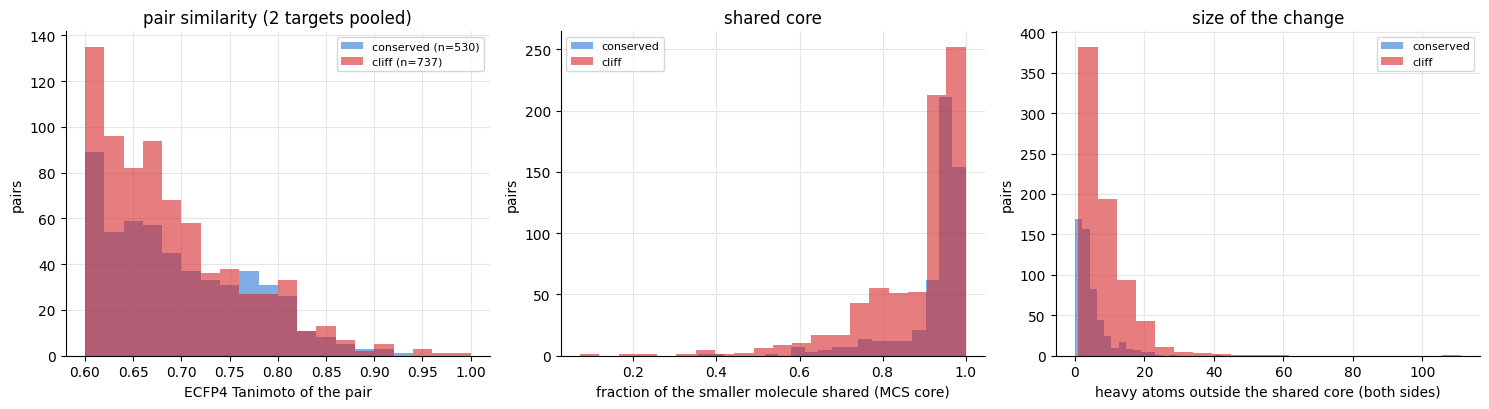

kind              cliff  conserved  share_of_neighbours_that_lose_binding
target simbin                                                            
504329 0.60-0.70    220        151                                   0.59
       0.70-0.80     87         84                                   0.51
       >=0.80        24         20                                   0.55
588689 0.60-0.70    255        153                                   0.62
       0.70-0.80     99         85                                   0.54
       >=0.80        52         37                                   0.58

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2)); bins = np.linspace(0.6, 1.0, 21)
axes[0].hist(CTRL.sim, bins=bins, color=CO, alpha=0.6, label=f"conserved (n={len(CTRL)})"); axes[0].hist(CLIFF.sim, bins=bins, color=CL, alpha=0.6, label=f"cliff (n={len(CLIFF)})")
axes[0].set_xlabel("ECFP4 Tanimoto of the pair"); axes[0].set_ylabel("pairs"); axes[0].set_title(f"pair similarity ({NT} targets pooled)"); axes[0].legend(fontsize=8)
for ax, (col, lab) in zip(axes[1:], [("frac_core", "fraction of the smaller molecule shared (MCS core)"), (None, "heavy atoms outside the shared core (both sides)")]):
    for d, c, l in [(CTRL, CO, "conserved"), (CLIFF, CL, "cliff")]:
        v = d[col].dropna() if col else (d.a_diff_n.fillna(0) + d.b_diff_n.fillna(0))[d.mcs_ok == 1]
        ax.hist(v, bins=20, color=c, alpha=0.6, label=l)
    ax.set_xlabel(lab); ax.set_ylabel("pairs"); ax.legend(fontsize=8)
axes[1].set_title("shared core"); axes[2].set_title("size of the change")
plt.tight_layout(); plt.show()
tab = P.groupby(["target", "simbin", "kind"], observed=True).size().unstack(fill_value=0)
for k in ("cliff", "conserved"):
    if k not in tab: tab[k] = 0
tab["share_of_neighbours_that_lose_binding"] = (tab.cliff / (tab.cliff + tab.conserved)).round(2); 
display(tab)

## 2. The most identical cliffs, drawn
For each ready target, pairs ranked by similarity: active on the left and inactive on the right, atoms outside the shared core highlighted. Legends give each member's percentile under the dataset Boltz-2 score and under head-FT, and **trainTc**: the member's highest ECFP4 Tanimoto (2048 bits, radius 2) to any active of the 300-compound training set (n/a when the training set is not available for the target).

target 588689: most identical cliff pairs (highlight = atoms outside the shared core)


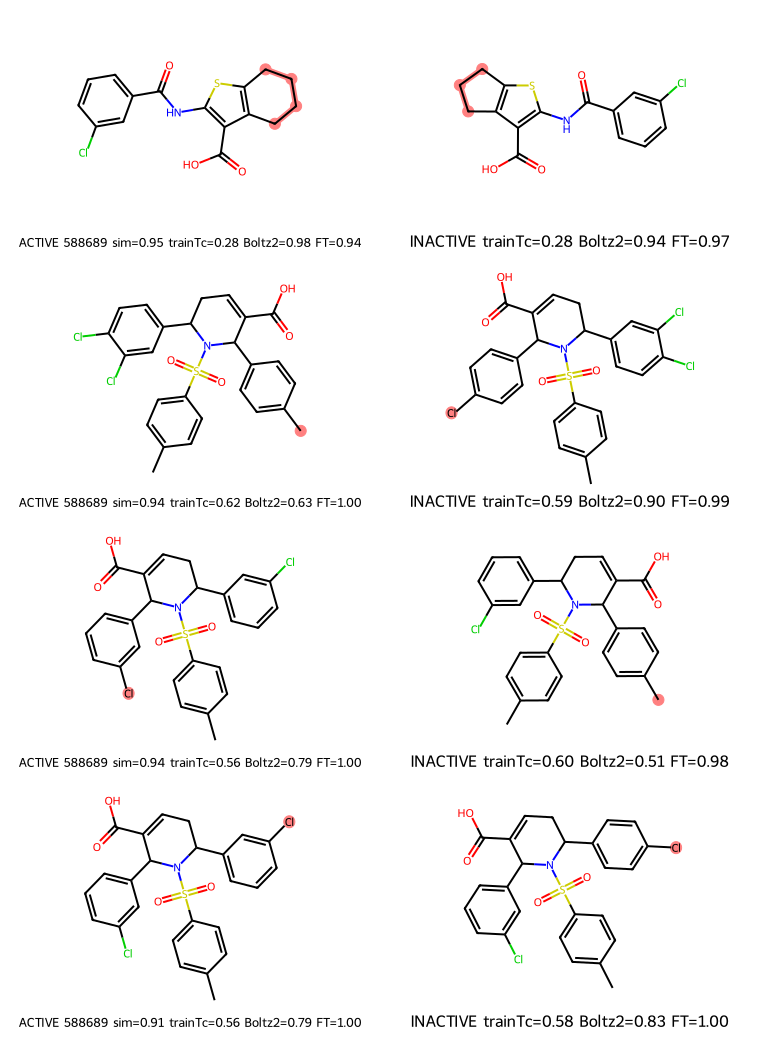

target 504329: most identical cliff pairs (highlight = atoms outside the shared core)


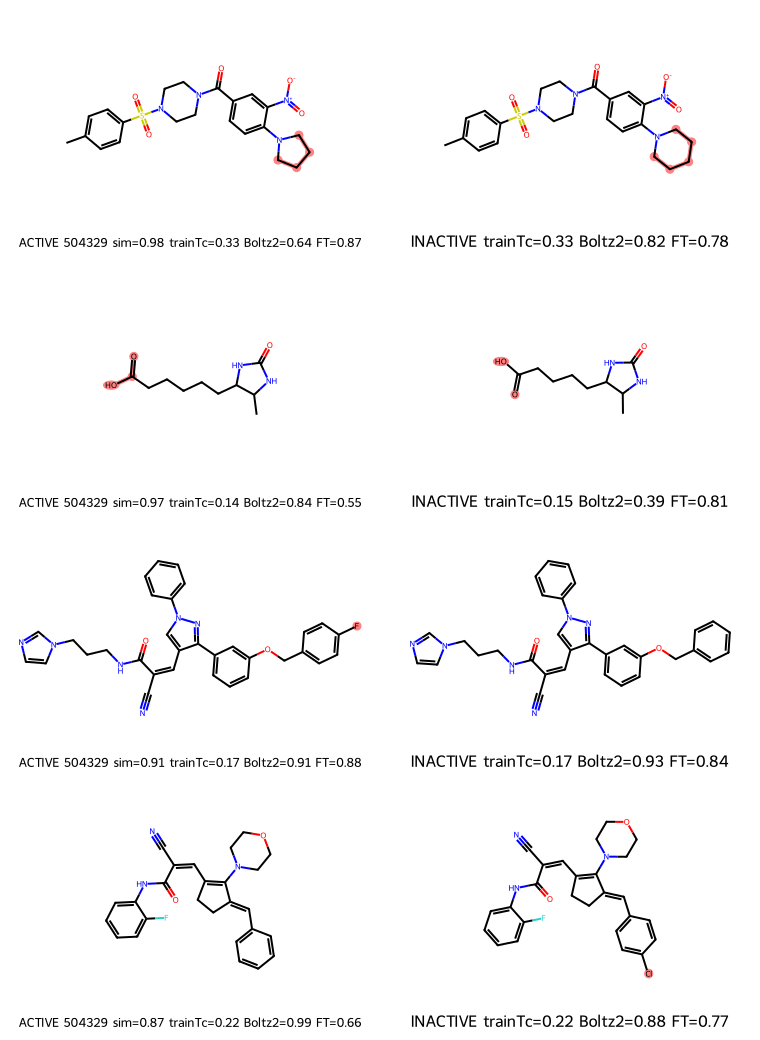

In [4]:
for t in TL:
    top = CLIFF[(CLIFF.target == t) & (CLIFF.mcs_ok == 1)].sort_values("sim", ascending=False)
    draw_pairs(top, 4, f"target {SH[t]}: most identical cliff pairs (highlight = atoms outside the shared core)")

## 3. Which signals can tell a near-identical active from its inactive partner?
For every cliff pair, does a signal rank the active above its inactive partner? 0.5 means blind. Three kinds of signal: **scoring modalities** (green), **Boltz-2 confidence** (grey) and **trivial baselines that use no protein** (orange: 'larger molecule', 'more lipophilic'). Numbers are **macro-averaged over targets**; intervals are 95% and resample independent *series* within each target. Ties count as half. Nine scoring modalities are compared against the 0.5 'blind' line, plus confidence and baseline rows, so this is a multiple-comparison setting: the table adds a **Bonferroni-adjusted interval** (alpha = 0.05 divided by the number of signals shown) and a signal is called distinguishable from blind only if that interval excludes 0.5. (The three Boltzina docking columns are byte-identical and ligand ipTM equals ipTM for a single-protein complex, so each is shown once.)

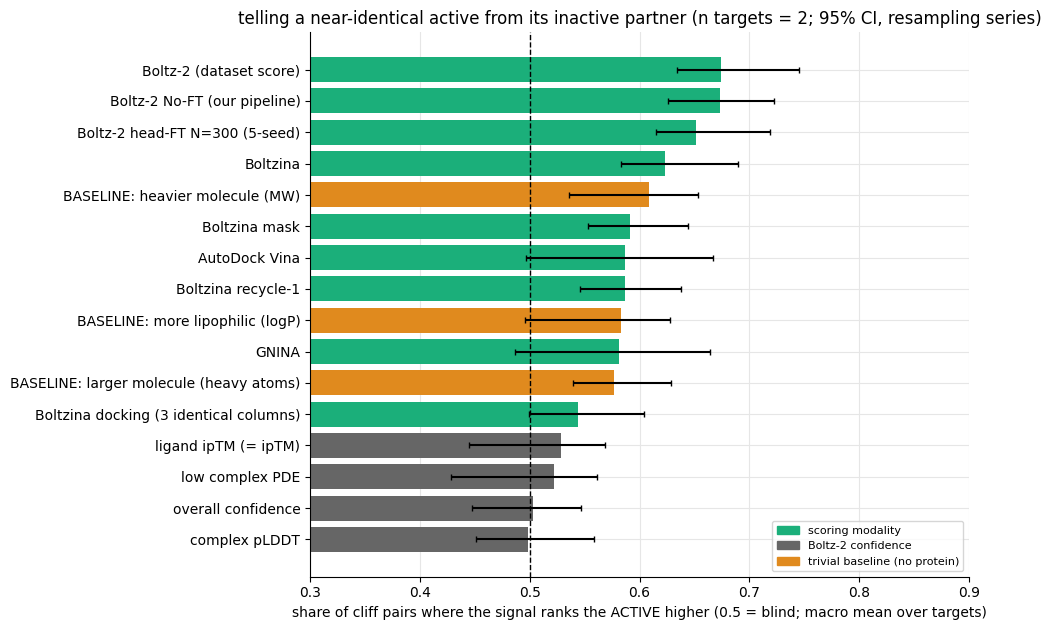

,kind,acc,lo,hi,lo_bonf,hi_bonf,n_pairs,n_series,n_targets,targets_above_half,distinguishable_from_blind_bonferroni
signal,,,,,,,,,,,
complex pLDDT,Boltz-2 confidence,0.499,0.451,0.558,0.424,0.598,737,193,2,1,False
overall confidence,Boltz-2 confidence,0.503,0.448,0.547,0.406,0.578,737,193,2,1,False
low complex PDE,Boltz-2 confidence,0.522,0.428,0.562,0.385,0.581,737,193,2,1,False
ligand ipTM (= ipTM),Boltz-2 confidence,0.528,0.445,0.569,0.404,0.591,737,193,2,1,False
Boltzina docking (3 identical columns),scoring modality,0.544,0.499,0.604,0.468,0.644,737,193,2,2,False
BASELINE: larger molecule (heavy atoms),trivial baseline,0.577,0.540,0.628,0.520,0.658,737,193,2,2,True
GNINA,scoring modality,0.581,0.486,0.664,0.433,0.707,202,56,2,2,False
BASELINE: more lipophilic (logP),trivial baseline,0.583,0.496,0.628,0.457,0.650,737,193,2,1,False
Boltzina recycle-1,scoring modality,0.587,0.545,0.638,0.515,0.670,737,193,2,2,True


In [5]:
specs = [(l, "scoring modality", "d_" + m, False) for m, l in MODS]
specs += [(l, "Boltz-2 confidence", "c_" + f, False) for f, l in [("ligand_iptm", "ligand ipTM (= ipTM)"), ("complex_plddt", "complex pLDDT"), ("confidence_score", "overall confidence")]]
specs += [("low complex PDE", "Boltz-2 confidence", "c_complex_pde", True), ("BASELINE: larger molecule (heavy atoms)", "trivial baseline", "dp_heavy", False),
          ("BASELINE: heavier molecule (MW)", "trivial baseline", "dp_MW", False), ("BASELINE: more lipophilic (logP)", "trivial baseline", "dp_logP", False)]
NSIG = len(specs); rows = []
for l, k, c, ng in specs:
    r = acc_ = bcl.acc_ci(CLIFF, c, neg=ng, B=2000); rb = bcl.acc_ci(CLIFF, c, neg=ng, B=4000, alpha=0.05 / NSIG)
    rows.append(dict(signal=l, kind=k, acc=r["acc"], lo=r["lo"], hi=r["hi"], lo_bonf=rb["lo"], hi_bonf=rb["hi"], n_pairs=r["n_pairs"], n_series=r["n_series"], n_targets=r["n_targets"],
                     targets_above_half=sum(v > 0.5 for v in r["per_target"].values())))
ACC = pd.DataFrame(rows).sort_values("acc"); colmap = {"scoring modality": GRN, "Boltz-2 confidence": NEU, "trivial baseline": ORG}
fig, ax = plt.subplots(figsize=(10, 6.4)); ax.barh(ACC.signal, ACC.acc, color=[colmap[k] for k in ACC.kind])
ax.errorbar(ACC.acc, range(len(ACC)), xerr=[ACC.acc - ACC.lo, ACC.hi - ACC.acc], fmt="none", ecolor=BLK, capsize=2)
ax.axvline(0.5, ls="--", color=BLK, lw=1); ax.set_xlim(0.3, 0.9)
ax.set_xlabel("share of cliff pairs where the signal ranks the ACTIVE higher (0.5 = blind; macro mean over targets)")
ax.set_title(f"telling a near-identical active from its inactive partner (n targets = {NT}; 95% CI, resampling series)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GRN, label="scoring modality"), Patch(color=NEU, label="Boltz-2 confidence"), Patch(color=ORG, label="trivial baseline (no protein)")], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()
ACC["distinguishable_from_blind_bonferroni"] = (ACC.lo_bonf > 0.5) | (ACC.hi_bonf < 0.5)
display(ACC.set_index("signal").round(3)); KEY["ACC"] = ACC.set_index("signal"); KEY["NSIG"] = NSIG

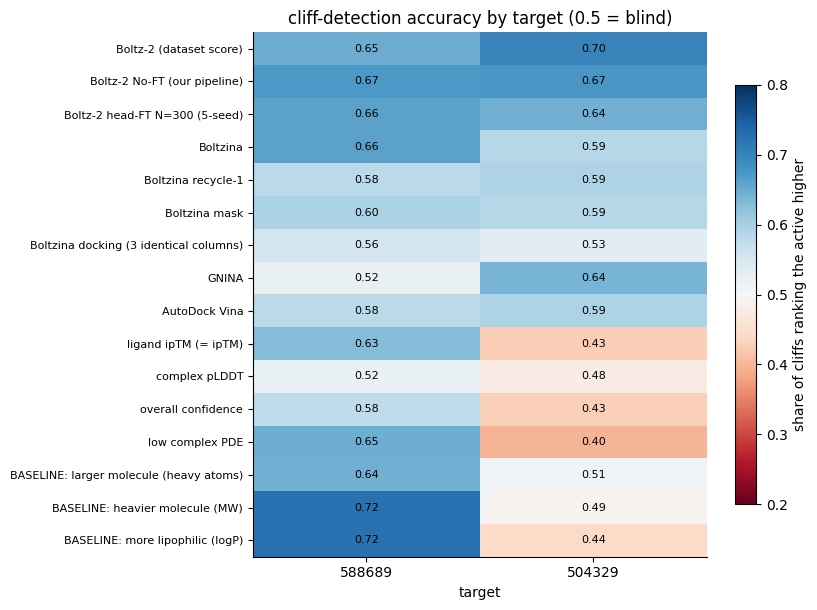

In [6]:
# the same accuracy per target (targets are the analysis unit; a pattern that holds in one target only is a statement about that target)
M_ = np.array([[bcl.acc_ci(CLIFF[CLIFF.target == t], c, neg=ng, B=200)["acc"] if (CLIFF.target == t).any() else np.nan for t in TL] for _, _, c, ng in specs], float)
fig, ax = plt.subplots(figsize=(1.2 * max(NT, 2) + 6, 6.2)); im = ax.imshow(M_, cmap="RdBu", vmin=0.2, vmax=0.8, aspect="auto"); ax.grid(False)
ax.set_xticks(range(NT)); ax.set_xticklabels([SH[t] for t in TL]); ax.set_yticks(range(len(specs))); ax.set_yticklabels([s[0] for s in specs], fontsize=8)
for i in range(M_.shape[0]):
    for j in range(M_.shape[1]): ax.text(j, i, f"{M_[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="share of cliffs ranking the active higher"); ax.set_xlabel("target"); ax.set_title("cliff-detection accuracy by target (0.5 = blind)")
plt.tight_layout(); plt.show()

**Is the baseline direction fair?** The orange baselines pick 'larger' or 'more lipophilic'. That direction is only legitimate if it is justified independently of these pairs, so it is checked on each target's whole eval set: AUROC of each property for the activity label (0.5 = no trend).

In [7]:
rows = []
for t in TL:
    try: rows.append(dict(target=SH[t], **bcl.prop_auroc(t, D[t])))
    except Exception as e: print(f"{SH[t]}: property AUROC failed: {e}")
PA = pd.DataFrame(rows).set_index("target"); display(PA.round(3)); KEY["PA"] = PA
print("(>0.5 means larger / greasier compounds are more often active across the whole target, independent of the pairs; <0.5 means the baseline direction would be wrong for that target)")

,molecular weight,heavy atoms,logP
target,,,
588689,0.593,0.586,0.655
504329,0.398,0.414,0.478


(>0.5 means larger / greasier compounds are more often active across the whole target, independent of the pairs; <0.5 means the baseline direction would be wrong for that target)


## 3b. How much of that is just size?
Accuracy split by whether the active is larger than, the same size as, or smaller than its inactive partner (heavy atoms). A signal that understands the change holds in every row; one that prefers bigger molecules falls to chance when the active is the smaller one.

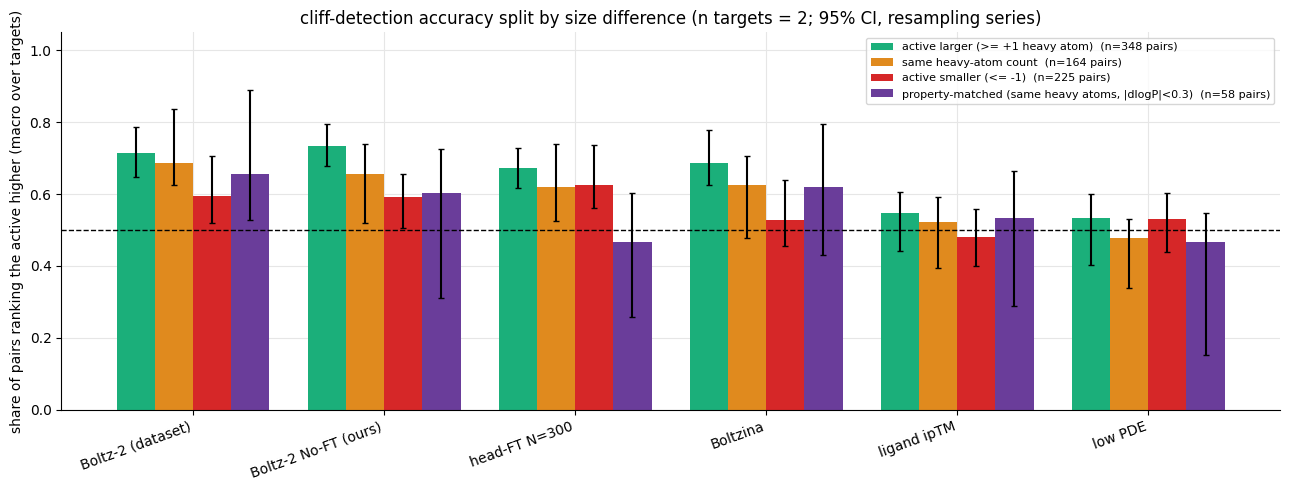

,pairs,Boltz-2 (dataset),Boltz-2 No-FT (ours),head-FT N=300,Boltzina,ligand ipTM,low PDE
stratum,,,,,,,
active larger (>= +1 heavy atom),348,0.71,0.73,0.67,0.69,0.55,0.53
same heavy-atom count,164,0.69,0.66,0.62,0.62,0.52,0.48
active smaller (<= -1),225,0.59,0.59,0.62,0.53,0.48,0.53
"property-matched (same heavy atoms, |dlogP|<0.3)",58,0.66,0.60,0.47,0.62,0.53,0.47


Spearman(ligand ipTM difference, heavy-atom difference) within cliffs, pooled pairs: rho=0.10 p=0.0062 (pairs treated as independent)


In [8]:
SIGS = [("Boltz-2 (dataset)", "d_score_boltz2", False), ("Boltz-2 No-FT (ours)", "d_base_noft", False), ("head-FT N=300", "d_ft300", False), ("Boltzina", "d_score_boltzina", False),
        ("ligand ipTM", "c_ligand_iptm", False), ("low PDE", "c_complex_pde", True)]
STR = [("active larger (>= +1 heavy atom)", CLIFF.dp_heavy >= 1), ("same heavy-atom count", CLIFF.dp_heavy == 0), ("active smaller (<= -1)", CLIFF.dp_heavy <= -1),
       ("property-matched (same heavy atoms, |dlogP|<0.3)", (CLIFF.dp_heavy == 0) & (CLIFF.dp_logP.abs() < 0.3))]
fig, ax = plt.subplots(figsize=(13, 5)); w = 0.2; x = np.arange(len(SIGS)); cs = [GRN, ORG, CL, "#6a3d9a"]; out = []
for k, (sn, mask) in enumerate(STR):
    sub = CLIFF[mask]; r = [bcl.acc_ci(sub, c, neg=ng, B=1000) for _, c, ng in SIGS]
    ax.bar(x + (k - 1.5) * w, [v["acc"] for v in r], w, color=cs[k], label=f"{sn}  (n={len(sub)} pairs)")
    ax.errorbar(x + (k - 1.5) * w, [v["acc"] for v in r], yerr=[[v["acc"] - v["lo"] for v in r], [v["hi"] - v["acc"] for v in r]], fmt="none", ecolor=BLK, capsize=2)
    out.append((sn, len(sub), *[round(v["acc"], 2) for v in r]))
ax.axhline(0.5, ls="--", color=BLK, lw=1); ax.set_xticks(x); ax.set_xticklabels([s for s, _, _ in SIGS], rotation=20, ha="right")
ax.set_ylabel("share of pairs ranking the active higher (macro over targets)"); ax.set_ylim(0.0, 1.05); ax.legend(fontsize=8)
ax.set_title(f"cliff-detection accuracy split by size difference (n targets = {NT}; 95% CI, resampling series)"); plt.tight_layout(); plt.show()
STRAT = pd.DataFrame(out, columns=["stratum", "pairs"] + [s for s, _, _ in SIGS]).set_index("stratum"); display(STRAT); KEY["STRAT"] = STRAT
rho, p = stats.spearmanr(CLIFF.c_ligand_iptm, CLIFF.dp_heavy, nan_policy="omit"); print(f"Spearman(ligand ipTM difference, heavy-atom difference) within cliffs, pooled pairs: rho={rho:.2f} p={p:.2g} (pairs treated as independent)")

## 3c. Are a few big series driving this?
Concentration of the cliffs per target, and the accuracies with each target's single largest series removed.

In [9]:
for t in TL:
    sz = CLIFF[CLIFF.target == t].groupby("series").size().sort_values(ascending=False)
    print(f"{SH[t]}: {len(sz)} series contain a cliff; pairs per series: largest {sz.iloc[0]}, top-3 {int(sz.iloc[:3].sum())} = {100*sz.iloc[:3].sum()/sz.sum():.0f}% of {int(sz.sum())} cliff pairs; median {int(sz.median())}")
rest = CLIFF[~CLIFF.big]; rows = []
for nm, c, ng in [("Boltz-2 (dataset)", "d_score_boltz2", False), ("Boltz-2 No-FT (ours)", "d_base_noft", False), ("head-FT N=300", "d_ft300", False), ("Boltzina", "d_score_boltzina", False),
                  ("ligand ipTM", "c_ligand_iptm", False), ("low PDE", "c_complex_pde", True), ("BASELINE larger molecule", "dp_heavy", False), ("BASELINE more lipophilic", "dp_logP", False), ("BASELINE heavier", "dp_MW", False)]:
    a = bcl.acc_ci(CLIFF, c, neg=ng, B=1000); b = bcl.acc_ci(rest, c, neg=ng, B=1000)
    rows.append((nm, a["acc"], b["acc"], f"[{b['lo']:.2f}, {b['hi']:.2f}]", b["n_pairs"], b["n_series"]))
WD = pd.DataFrame(rows, columns=["signal", "all cliff pairs", "without the dominant series", "95% CI without", "pairs left", "series left"]).set_index("signal"); display(WD.round(3)); KEY["WD"] = WD

588689: 73 series contain a cliff; pairs per series: largest 252, top-3 282 = 69% of 406 cliff pairs; median 1
504329: 120 series contain a cliff; pairs per series: largest 48, top-3 84 = 25% of 331 cliff pairs; median 1


,all cliff pairs,without the dominant series,95% CI without,pairs left,series left
signal,,,,,
Boltz-2 (dataset),0.674,0.685,"[0.62, 0.75]",437,191
Boltz-2 No-FT (ours),0.673,0.674,"[0.61, 0.74]",437,191
head-FT N=300,0.652,0.670,"[0.62, 0.73]",437,191
Boltzina,0.623,0.637,"[0.58, 0.70]",437,191
ligand ipTM,0.528,0.500,"[0.43, 0.56]",437,191
low PDE,0.522,0.467,"[0.41, 0.52]",437,191
BASELINE larger molecule,0.577,0.592,"[0.53, 0.64]",437,191
BASELINE more lipophilic,0.583,0.551,"[0.49, 0.61]",437,191
BASELINE heavier,0.608,0.579,"[0.51, 0.65]",437,191


## 4. Pair by pair (heat map of score deltas across the 9 dataset scores + pipeline score)
Rows are cliff pairs (most identical first, up to 70 per target), columns are modalities, colour is the percentile delta (active minus inactive). Blue = the modality ranks the active higher; red = it prefers the inactive partner. One panel per ready target.

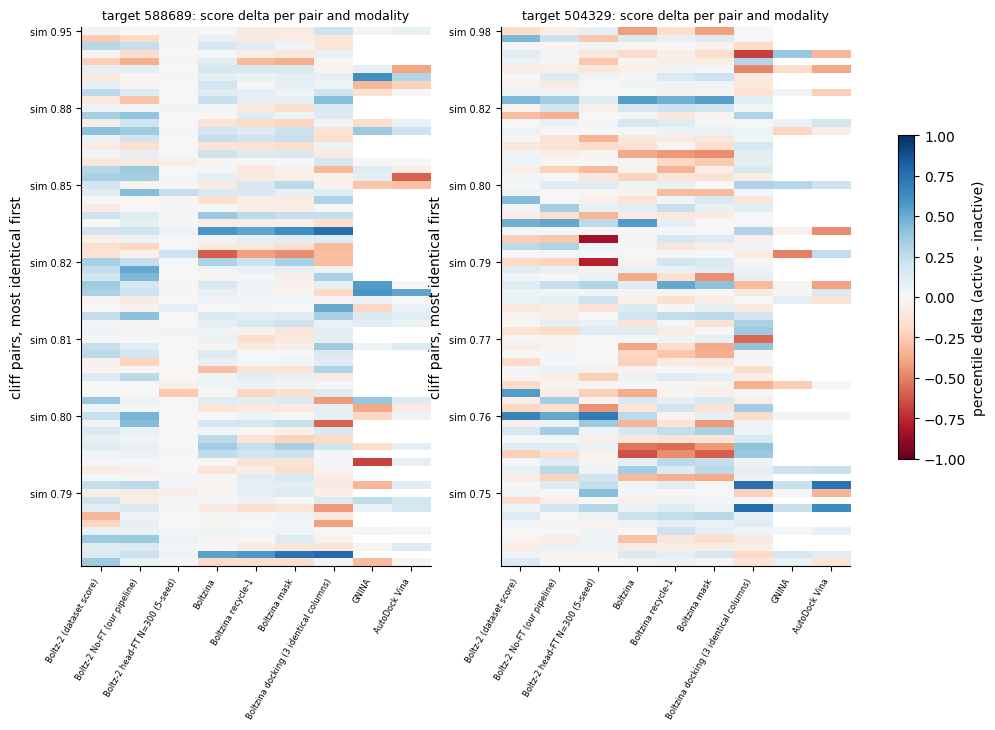

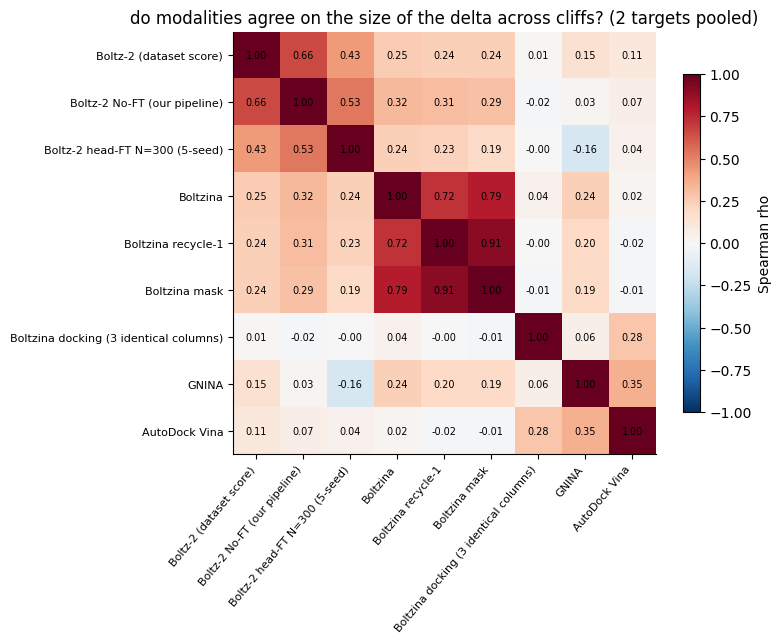

In [10]:
fig, axes = tgrid(NT, w=6.2, h=7, maxc=3)
for ax, t in zip(axes, TL):
    H = CLIFF[CLIFF.target == t].sort_values("sim", ascending=False).head(70); Dm = H[["d_" + m for m, _ in MODS]].values
    im = ax.imshow(Dm, aspect="auto", cmap="RdBu", vmin=-1, vmax=1, interpolation="nearest"); ax.grid(False)
    ax.set_xticks(range(len(MODS))); ax.set_xticklabels([l for _, l in MODS], rotation=60, ha="right", fontsize=6)
    ax.set_yticks(range(0, len(H), 10)); ax.set_yticklabels([f"sim {s:.2f}" for s in H.sim.values[::10]], fontsize=7); ax.set_ylabel("cliff pairs, most identical first"); ax.set_title(f"target {SH[t]}: score delta per pair and modality", fontsize=9)
fig.colorbar(im, ax=axes[:NT].tolist(), shrink=0.6, label="percentile delta (active - inactive)"); plt.show()
cm = CLIFF[["d_" + m for m, _ in MODS]].rename(columns={"d_" + m: l for m, l in MODS}).corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5)); im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=50, ha="right", fontsize=8); ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index, fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)): ax.text(j, i, f"{cm.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho"); ax.set_title(f"do modalities agree on the size of the delta across cliffs? ({NT} targets pooled)"); plt.tight_layout(); plt.show()

## 5. Where are the big deltas? Similarity vs score delta
Each point is a cliff pair, coloured by target. Above zero the modality ranks the active higher; below zero it prefers the inactive partner. The table counts near-identical pairs (Tanimoto >= 0.7) with |delta| > 0.3 of a percentile.

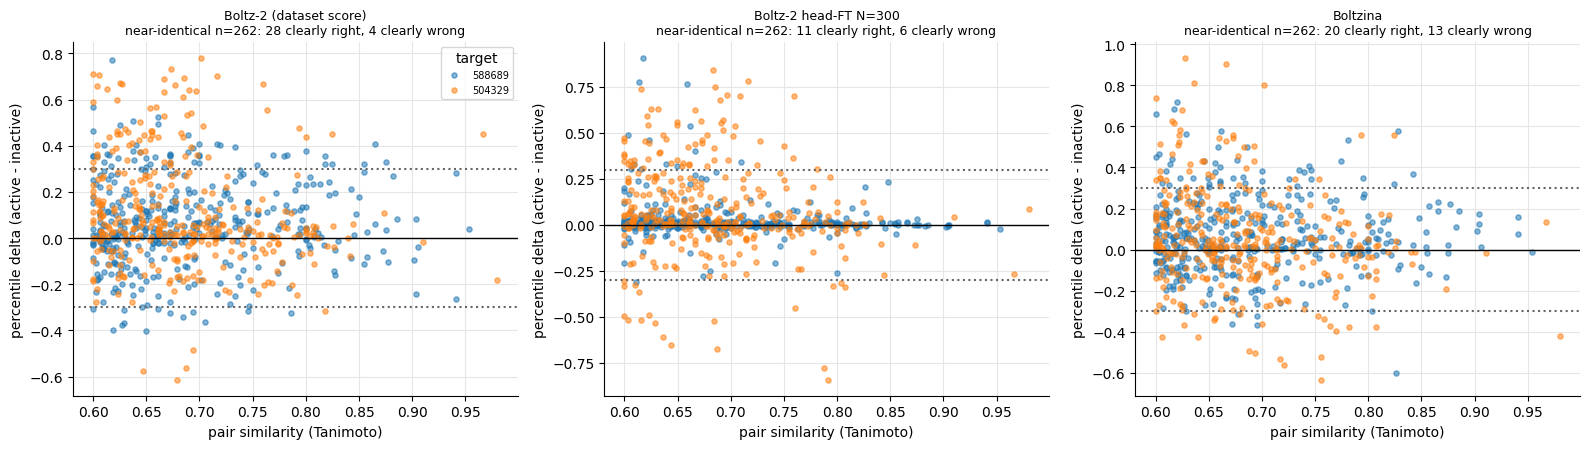

all cliff pairs


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),262,28,230,4
Boltz-2 No-FT (our pipeline),262,37,216,9
Boltz-2 head-FT N=300 (5-seed),262,11,245,6
Boltzina,262,20,229,13
Boltzina recycle-1,262,11,233,18
Boltzina mask,262,14,227,21
Boltzina docking (3 identical columns),262,40,199,23
GNINA,81,14,59,8
AutoDock Vina,81,9,64,8


without the dominant series


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),146,10,135,1
Boltz-2 No-FT (our pipeline),146,12,130,4
Boltz-2 head-FT N=300 (5-seed),146,9,131,6
Boltzina,146,11,125,10
Boltzina recycle-1,146,9,126,11
Boltzina mask,146,11,123,12
Boltzina docking (3 identical columns),146,22,115,9
GNINA,40,2,35,3
AutoDock Vina,40,4,31,5


dominant series only


,near-identical pairs,clearly right (>+0.3),near tie,clearly wrong (<-0.3)
modality,,,,
Boltz-2 (dataset score),116,18,95,3
Boltz-2 No-FT (our pipeline),116,25,86,5
Boltz-2 head-FT N=300 (5-seed),116,2,114,0
Boltzina,116,9,104,3
Boltzina recycle-1,116,2,107,7
Boltzina mask,116,3,104,9
Boltzina docking (3 identical columns),116,18,84,14
GNINA,41,12,24,5
AutoDock Vina,41,5,33,3


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (m, l) in zip(axes, [("score_boltz2", "Boltz-2 (dataset score)"), ("ft300", "Boltz-2 head-FT N=300"), ("score_boltzina", "Boltzina")]):
    d = CLIFF[["sim", "d_" + m, "target"]].dropna()
    for t in TL:
        s = d[d.target == t]; ax.scatter(s.sim, s["d_" + m], s=14, alpha=0.55, color=TCOL[t], label=SH[t])
    ax.axhline(0, color=BLK, lw=1); ax.axhline(0.3, ls=":", color=NEU); ax.axhline(-0.3, ls=":", color=NEU)
    near = d[d.sim >= 0.7]; bad = int((near["d_" + m] < -0.3).sum()); good = int((near["d_" + m] > 0.3).sum())
    ax.set_xlabel("pair similarity (Tanimoto)"); ax.set_ylabel("percentile delta (active - inactive)"); ax.set_title(f"{l}\nnear-identical n={len(near)}: {good} clearly right, {bad} clearly wrong", fontsize=9)
    if m == "score_boltz2": ax.legend(fontsize=7, title="target")
plt.tight_layout(); plt.show()
def near_tab(d):
    out = []
    for m, l in MODS:
        near = d[d.sim >= 0.7]["d_" + m].dropna()
        out.append((l, len(near), int((near > 0.3).sum()), int((near.abs() <= 0.3).sum()), int((near < -0.3).sum())))
    return pd.DataFrame(out, columns=["modality", "near-identical pairs", "clearly right (>+0.3)", "near tie", "clearly wrong (<-0.3)"]).set_index("modality")
NEAR = {}
for nm, d in [("all cliff pairs", CLIFF), ("without the dominant series", CLIFF[~CLIFF.big]), ("dominant series only", CLIFF[CLIFF.big])]:
    print(nm); NEAR[nm] = near_tab(d); display(NEAR[nm])
KEY["NEAR"] = NEAR

Near-identical cliffs where Boltz-2 (dataset score) most prefers the INACTIVE partner (largest wrong-way delta)


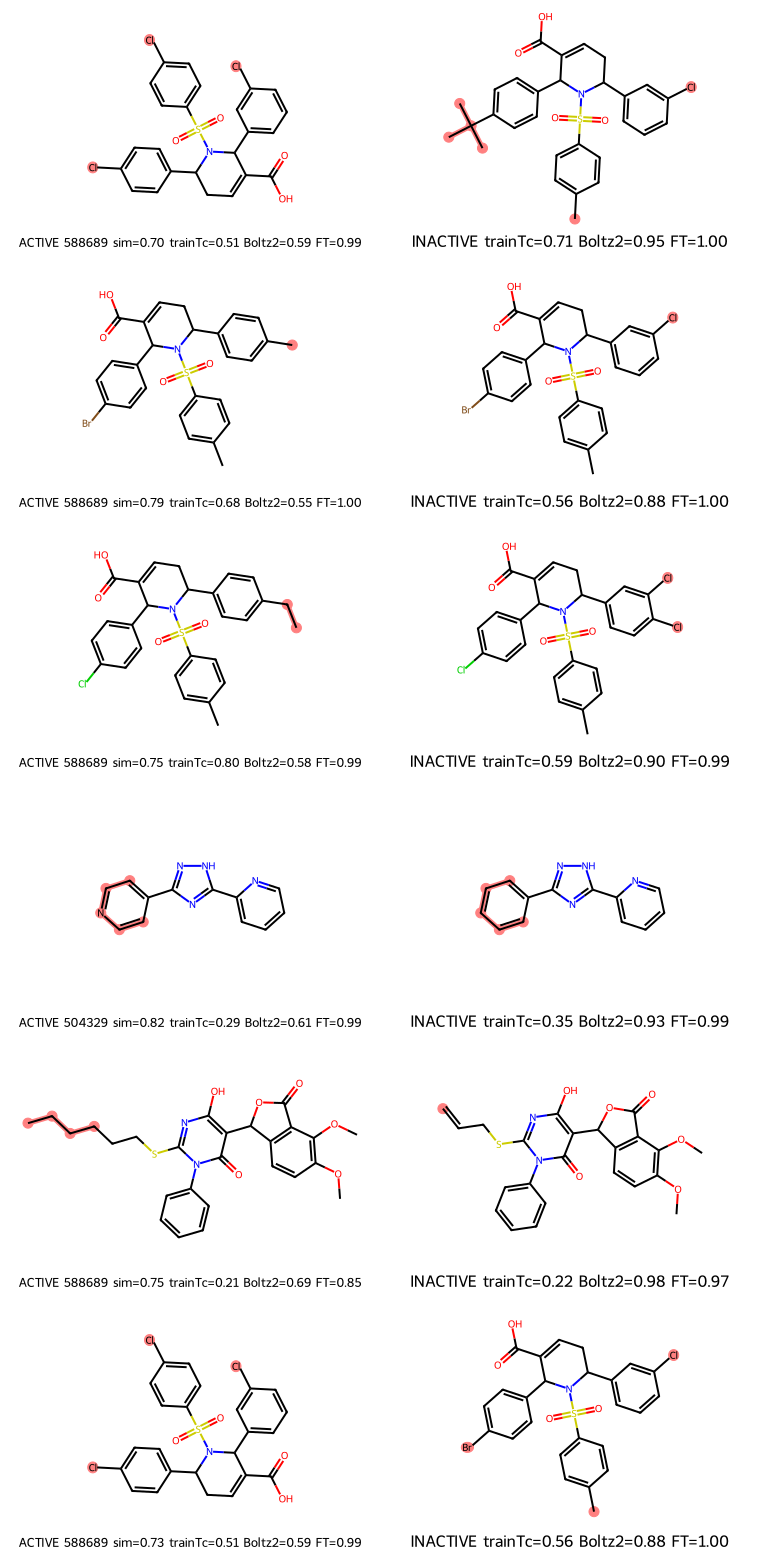

In [12]:
fooled = CLIFF[(CLIFF.sim >= 0.7) & (CLIFF.mcs_ok == 1)].sort_values("d_score_boltz2")
draw_pairs(fooled, 6, "Near-identical cliffs where Boltz-2 (dataset score) most prefers the INACTIVE partner (largest wrong-way delta)")

## 6. How complete is the loss of binding?
'Inactive' in a screen is a threshold on a noisy readout. The data include each compound's primary-screen Z-score, so we can ask whether the inactive partners are clean zeros or partly active. Each distinct inactive partner is counted once (many pairs share a partner). Z-scores are assay-specific, so they are compared within a target and pooled only as a within-target percentile.

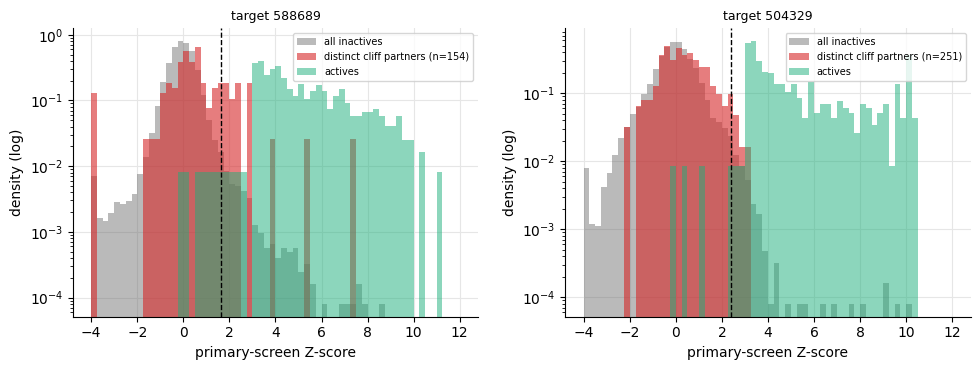

,partners,median_Z_actives,median_Z_inactives,median_Z_partners,pct_partners_above_99th_of_inactives,pct_partners_at_or_above_weakest_10pct_actives,rho_b2_all,rho_ft_all,rho_b2_no_dom,rho_ft_no_dom
target,,,,,,,,,,
588689,154,4.53,-0.05,0.45,19.48,1.95,0.04,0.18,0.17,0.05
504329,251,4.45,-0.02,0.25,3.59,0.00,0.16,0.12,0.15,0.09


expected share of ordinary inactives above their own 99th percentile: 1% by definition. rho columns: compound-level Spearman of the partner's Z against the model percentile (b2 = Boltz-2 dataset score, ft = head-FT).


In [13]:
rows = []; fig, axes = tgrid(NT, w=5, h=3.8, maxc=3); partpct = []
for ax, t in zip(axes, TL):
    z = D[t]["zinfo"]; C = CLIFF[CLIFF.target == t]; part = pd.unique(C.id_b); pz = D[t]["Mi"]["zscore"].reindex(part).dropna()
    bins = np.linspace(-4, 12, 65)
    ax.hist(np.clip(z["ina"], -4, 12), bins=bins, density=True, color=NEU, alpha=0.45, label="all inactives"); ax.hist(np.clip(pz, -4, 12), bins=bins, density=True, color=CL, alpha=0.6, label=f"distinct cliff partners (n={len(pz)})")
    ax.hist(np.clip(z["act"], -4, 12), bins=bins, density=True, color=GRN, alpha=0.5, label="actives"); ax.set_yscale("log"); ax.axvline(z["hi99"], ls="--", color=BLK, lw=1)
    ax.set_xlabel("primary-screen Z-score"); ax.set_ylabel("density (log)"); ax.set_title(f"target {SH[t]}", fontsize=9); ax.legend(fontsize=7)
    rk = pd.Series(pz.values).map(lambda v: (z["ina"] < v).mean()); partpct += list(rk)
    big = set(C[C.big].id_b); rr = {}
    for nm, ids in [("all", list(part)), ("no_dom", [i for i in part if i not in big])]:
        zz = D[t]["Mi"]["zscore"].reindex(ids); 
        for m, l in [("pct_score_boltz2", "b2"), ("pct_ft300", "ft")]:
            v = D[t]["Mi"][m].reindex(ids); ok = (zz.notna() & v.notna()).values; rr[f"rho_{l}_{nm}"] = stats.spearmanr(zz[ok], v[ok])[0] if ok.sum() > 5 else np.nan
    rows.append(dict(target=SH[t], partners=len(pz), median_Z_actives=z["act_med"], median_Z_inactives=z["ina_med"], median_Z_partners=pz.median(),
                     pct_partners_above_99th_of_inactives=100 * (pz > z["hi99"]).mean(), pct_partners_at_or_above_weakest_10pct_actives=100 * (pz >= z["act10"]).mean(), **rr))
plt.tight_layout(); plt.show()
ZT = pd.DataFrame(rows).set_index("target"); display(ZT.round(2)); KEY["ZT"] = ZT
print("expected share of ordinary inactives above their own 99th percentile: 1% by definition. rho columns: compound-level Spearman of the partner's Z against the model percentile (b2 = Boltz-2 dataset score, ft = head-FT).")

### 6b. Are the top-of-ranking false positives just siblings of true actives?
The ranking is judged on its top 1%. For each model and target, take the inactive compounds in its top 1% (false positives) and ask what share are near-identical to a true active (a cliff partner: Tanimoto >= 0.6 to an eval active), against how common cliff partners are among ordinary compounds.

top1pct  true_actives  false_positives  sibling_fp  \
target model                                                                 
588689 No-FT                497            67              430           8   
       head-FT N=300        497           125              372          29   
       Boltz-2 dataset      497            73              424          10   
504329 No-FT                497            43              454          13   
       head-FT N=300        497           138              359          21   
       Boltz-2 dataset      497            43              454           5   

                        sibling_fp_in_dominant  pct_fp_siblings  \
target model                                                      
588689 No-FT                                 0             1.86   
       head-FT N=300                        14             7.80   
       Boltz-2 dataset                       0             2.36   
504329 No-FT                                 0             2.86   
       head-FT N=300                         3             5.85   
       Boltz-2 dataset                       0             1.10   

                        enrichment_vs_ordinary  pct_without_dominant  \
target model                                                           
588689 No-FT                              6.00                  1.86   
       head-FT N=300                     25.15                  4.03   
       Boltz-2 dataset                    7.61                  2.36   
504329 No-FT                              5.67                  2.86   
       head-FT N=300                     11.58                  5.01   
       Boltz-2 dataset                    2.18                  1.10   

                        ordinary_pct  
target model                          
588689 No-FT                    0.31  
       head-FT N=300            0.31  
       Boltz-2 dataset          0.31  
504329 No-FT                    0.51  
       head-FT N=300            0.51  
       Boltz-2 dataset          0.51

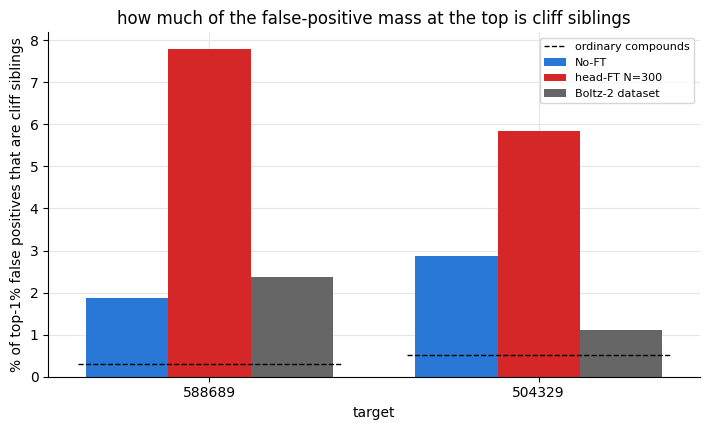

In [14]:
rows = []
for t in TL:
    ev = D[t]["ev"]; C = CLIFF[CLIFF.target == t]; partner_ids = set(C.id_b); big_ids = set(C[C.big].id_b); k = int(round(0.01 * len(ev))); base_rate = ev.id.isin(partner_ids).mean()
    for m, l in [("base_noft", "No-FT"), ("ft300", "head-FT N=300"), ("score_boltz2", "Boltz-2 dataset")]:
        top = ev.nlargest(k, m); fp = top[top.label == 0]; sib = fp.id.isin(partner_ids)
        rows.append(dict(target=SH[t], model=l, top1pct=k, true_actives=int((top.label == 1).sum()), false_positives=len(fp), sibling_fp=int(sib.sum()), sibling_fp_in_dominant=int(fp.id.isin(big_ids).sum()),
                         pct_fp_siblings=100 * sib.mean(), enrichment_vs_ordinary=sib.mean() / base_rate, pct_without_dominant=100 * (sib.sum() - fp.id.isin(big_ids).sum()) / max(1, len(fp)), ordinary_pct=100 * base_rate))
T6 = pd.DataFrame(rows); display(T6.round(2).set_index(["target", "model"])); KEY["T6"] = T6
fig, ax = plt.subplots(figsize=(1.6 * max(NT, 2) + 4, 4.4)); w = 0.25
for k_, (l, c) in enumerate([("No-FT", CO), ("head-FT N=300", CL), ("Boltz-2 dataset", NEU)]):
    s = T6[T6.model == l]; ax.bar(np.arange(len(s)) + (k_ - 1) * w, s.pct_fp_siblings, w, color=c, label=l)
o = T6[T6.model == "No-FT"]; ax.set_xticks(np.arange(len(o))); ax.set_xticklabels(o.target)
for i, v in enumerate(o.ordinary_pct): ax.plot([i - 0.4, i + 0.4], [v, v], color=BLK, ls="--", lw=1, label="ordinary compounds" if i == 0 else None)
ax.set_xlabel("target"); ax.set_ylabel("% of top-1% false positives that are cliff siblings"); ax.legend(fontsize=8); ax.set_title("how much of the false-positive mass at the top is cliff siblings"); plt.tight_layout(); plt.show()

## 7. Why: what chemically differs in the pairs that lose binding?
Property change (active minus inactive) for cliff pairs next to the control (both active, random orientation, so it centres on zero by construction). Only the cliff-versus-zero test is informative about direction; the |delta| test asks whether cliff pairs change more than control pairs. SMILES are neutralised, so net charge is omitted. Tests here treat pairs as independent (optimistic); the last column counts in how many targets the median has the same sign as the pooled median (targets are the unit for cross-target claims).

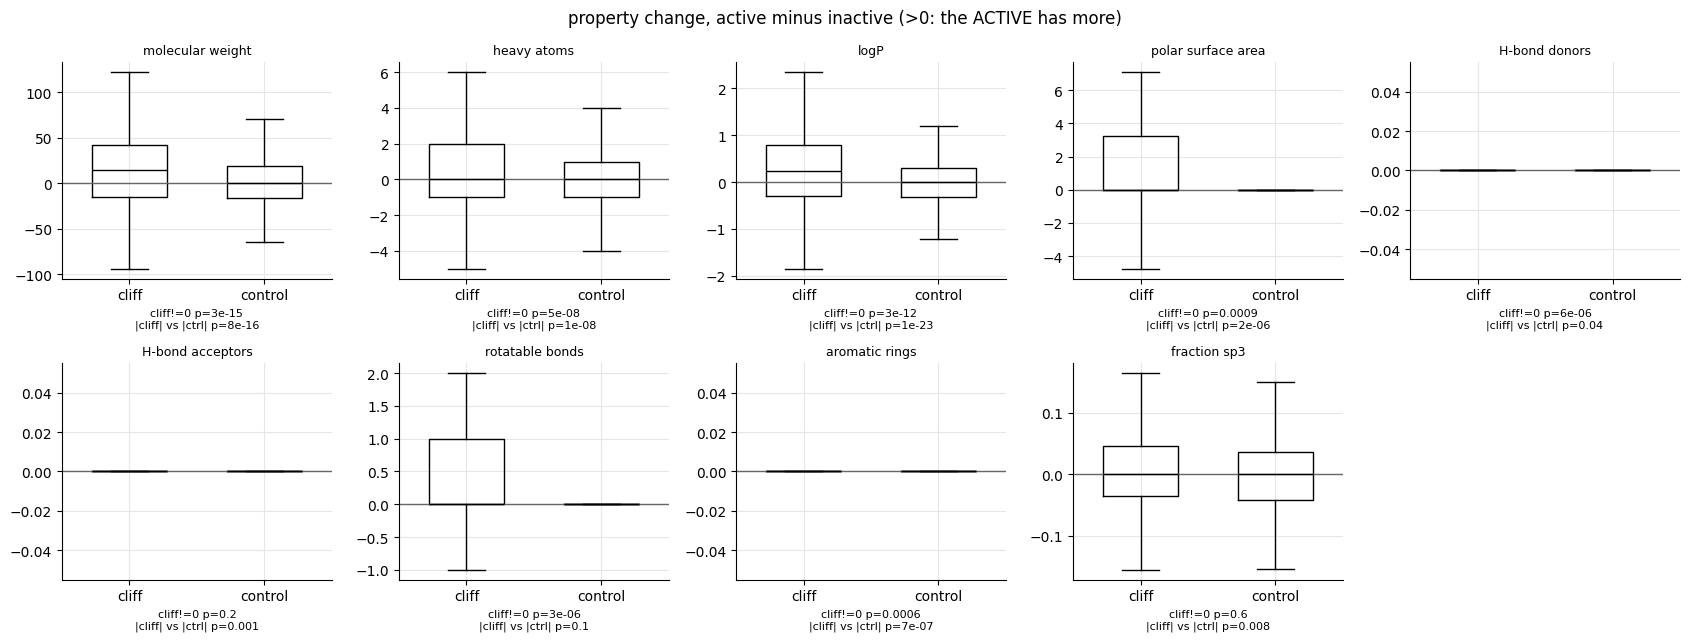

,"median delta (active-inactive), cliffs",share of cliffs where active has MORE,share where active has FEWER,p (delta != 0),p (|delta| cliff vs control),targets with same median sign
property,,,,,,
molecular weight,14.0270,0.6038,0.3636,0.0000,0.0000,1/2
heavy atoms,0.0000,0.4722,0.3053,0.0000,0.0000,1/2
logP,0.2348,0.5834,0.3881,0.0000,0.0000,1/2
polar surface area,0.0000,0.2754,0.2266,0.0009,0.0000,2/2
H-bond donors,0.0000,0.0909,0.0366,0.0000,0.0398,2/2
H-bond acceptors,0.0000,0.2198,0.1913,0.1591,0.0013,2/2
rotatable bonds,0.0000,0.2972,0.1886,0.0000,0.1154,2/2
aromatic rings,0.0000,0.0923,0.0434,0.0006,0.0000,2/2
fraction sp3,0.0000,0.3881,0.3935,0.6170,0.0083,2/2


In [15]:
fig, axes = plt.subplots(2, 5, figsize=(17, 6.5)); res = []
for ax, (p, l) in zip(axes.ravel(), PROPS):
    a = CLIFF["dp_" + p].dropna(); b = CTRL["dp_" + p].dropna()
    ax.boxplot([a, b], tick_labels=["cliff", "control"], showfliers=False, widths=0.55, medianprops=dict(color=BLK)); ax.axhline(0, color=NEU, lw=1); ax.set_title(l, fontsize=9)
    try: pz_ = stats.wilcoxon(a).pvalue
    except Exception: pz_ = np.nan
    pu = stats.mannwhitneyu(a.abs(), b.abs()).pvalue; ax.set_xlabel(f"cliff!=0 p={pz_:.1g}\n|cliff| vs |ctrl| p={pu:.1g}", fontsize=8)
    meds = [CLIFF[CLIFF.target == t]["dp_" + p].median() for t in TL]; same = sum(np.sign(m_) == np.sign(a.median()) for m_ in meds if np.isfinite(m_))
    res.append((l, a.median(), (a > 0).mean(), (a < 0).mean(), pz_, pu, f"{same}/{NT}"))
for ax in axes.ravel()[len(PROPS):]: ax.axis("off")
fig.suptitle("property change, active minus inactive (>0: the ACTIVE has more)", fontsize=12); plt.tight_layout(); plt.show()
PROP_T = pd.DataFrame(res, columns=["property", "median delta (active-inactive), cliffs", "share of cliffs where active has MORE", "share where active has FEWER", "p (delta != 0)", "p (|delta| cliff vs control)", "targets with same median sign"]).set_index("property")
display(PROP_T.round(4)); KEY["PROP_T"] = PROP_T

## 8. The changed fragment itself, and the loss rate by kind of change
Only the atoms outside the shared core. The right panel is the loss rate: of an active's near-identical neighbours, what fraction lose binding, split by kind of change.

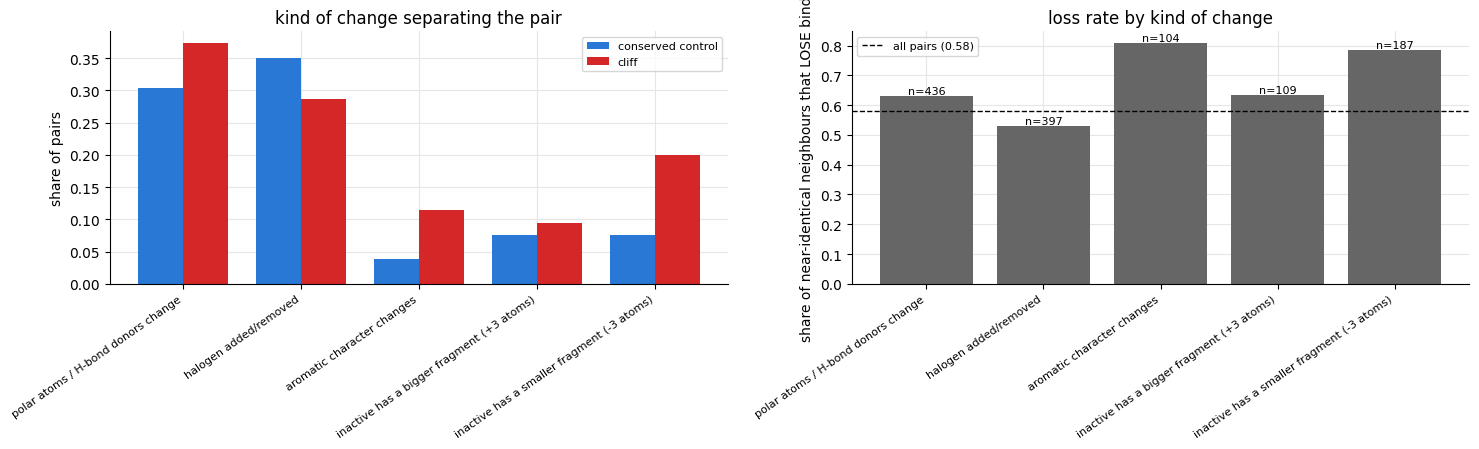

In [16]:
C2 = P[(P.mcs_ok == 1)].copy()
C2["polar_diff"] = (C2.a_diff_hbd != C2.b_diff_hbd) | ((C2.a_diff_has_N + C2.a_diff_has_O) != (C2.b_diff_has_N + C2.b_diff_has_O))
C2["hal_diff"] = (C2.a_diff_has_hal != C2.b_diff_has_hal); C2["arom_diff"] = (C2.a_diff_arom != C2.b_diff_arom)
C2["size_gain"] = (C2.b_diff_n - C2.a_diff_n); C2["bigger_inactive"] = C2.size_gain >= 3; C2["smaller_inactive"] = C2.size_gain <= -3
flags8 = [("polar_diff", "polar atoms / H-bond donors change"), ("hal_diff", "halogen added/removed"), ("arom_diff", "aromatic character changes"),
          ("bigger_inactive", "inactive has a bigger fragment (+3 atoms)"), ("smaller_inactive", "inactive has a smaller fragment (-3 atoms)")]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6)); x = np.arange(len(flags8)); w = 0.38
axes[0].bar(x - w / 2, [C2[C2.kind == "conserved"][f].mean() for f, _ in flags8], w, color=CO, label="conserved control"); axes[0].bar(x + w / 2, [C2[C2.kind == "cliff"][f].mean() for f, _ in flags8], w, color=CL, label="cliff")
axes[0].set_xticks(x); axes[0].set_xticklabels([l for _, l in flags8], rotation=35, ha="right", fontsize=8); axes[0].set_ylabel("share of pairs"); axes[0].legend(fontsize=8); axes[0].set_title("kind of change separating the pair")
lr = [(l, (C2[C2[f]].kind == "cliff").mean(), int(C2[f].sum())) for f, l in flags8]; base = (C2.kind == "cliff").mean()
axes[1].bar(range(len(lr)), [v for _, v, _ in lr], color=NEU); axes[1].axhline(base, ls="--", color=BLK, lw=1, label=f"all pairs ({base:.2f})")
for i, (_, v, n) in enumerate(lr): axes[1].text(i, v, f"n={n}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(range(len(lr))); axes[1].set_xticklabels([l for l, _, _ in lr], rotation=35, ha="right", fontsize=8); axes[1].set_ylabel("share of near-identical neighbours that LOSE binding"); axes[1].legend(fontsize=8); axes[1].set_title("loss rate by kind of change")
plt.tight_layout(); plt.show()

## 9. Can the change predict the loss? (grouped cross-validation)
A cross-validated classifier tells a cliff from a conserved pair from a structural description of the pair only. **Cross-validation is GroupKFold by series** (series ids are unique across targets), so pairs from one series never sit on both sides of a split; without that, a dominant series inflates the score. Pairs from all ready targets are pooled for training. The second feature set is restricted to size and lipophilicity, to show how much of the signal is just 'the inactive one is smaller / less greasy'.

,pairs used,model,features,AUROC (GroupKFold by series),pairs,cliffs,series
0,all pairs,logistic,all descriptors,0.668,1267,737,236
1,all pairs,logistic,size + lipophilicity only,0.670,1267,737,236
2,all pairs,boosting,all descriptors,0.659,1267,737,236
3,all pairs,boosting,size + lipophilicity only,0.664,1267,737,236
4,without each target's dominant series,logistic,all descriptors,0.711,822,437,234
5,without each target's dominant series,logistic,size + lipophilicity only,0.722,822,437,234
6,without each target's dominant series,boosting,all descriptors,0.704,822,437,234
7,without each target's dominant series,boosting,size + lipophilicity only,0.696,822,437,234


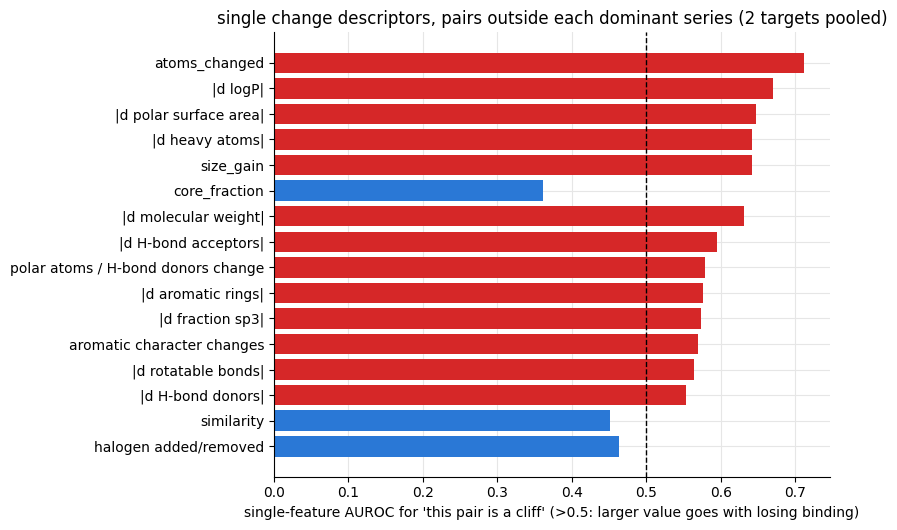

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
def feats(d):
    F = pd.DataFrame({"similarity": d.sim, "core_fraction": d.frac_core, "atoms_changed": d.a_diff_n + d.b_diff_n, "size_gain": (d.b_diff_n - d.a_diff_n).abs()})
    for p, l in PROPS: F["|d " + l + "|"] = d["dp_" + p].abs()
    for f, l in flags8[:3]: F[l] = d[f].astype(float)
    return F.fillna(F.median())
size_cols = ["size_gain", "atoms_changed", "|d heavy atoms|", "|d molecular weight|", "|d logP|"]
lgm = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=0.3))
gbm = lambda: GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=0)
rows = []
for part, dd in [("all pairs", C2), ("without each target's dominant series", C2[~C2.big])]:
    y = (dd.kind == "cliff").astype(int).values; g = dd.series.values; ng_ = len(np.unique(g))
    if y.sum() < 10 or (1 - y).sum() < 10 or ng_ < 5: print(f"{part}: too few pairs/series for grouped CV"); continue
    F = feats(dd)
    for mn, mk in [("logistic", lgm), ("boosting", gbm)]:
        for fs, cols in [("all descriptors", list(F.columns)), ("size + lipophilicity only", size_cols)]:
            pr = cross_val_predict(mk(), F[cols].values, y, cv=GroupKFold(5), groups=g, method="predict_proba")[:, 1]
            rows.append((part, mn, fs, roc_auc_score(y, pr), len(y), int(y.sum()), ng_))
CV = pd.DataFrame(rows, columns=["pairs used", "model", "features", "AUROC (GroupKFold by series)", "pairs", "cliffs", "series"]); display(CV.round(3)); KEY["CV"] = CV
dd = C2[~C2.big]; F = feats(dd); y = (dd.kind == "cliff").astype(int).values
sf = sorted([(c, roc_auc_score(y, F[c])) for c in F.columns], key=lambda t: abs(t[1] - 0.5))
fig, ax = plt.subplots(figsize=(8.5, 5.4)); ax.barh([c for c, _ in sf], [a for _, a in sf], color=[CL if a > 0.5 else CO for _, a in sf])
ax.axvline(0.5, color=BLK, ls="--", lw=1); ax.set_xlabel("single-feature AUROC for 'this pair is a cliff' (>0.5: larger value goes with losing binding)")
ax.set_title(f"single change descriptors, pairs outside each dominant series ({NT} targets pooled)"); plt.tight_layout(); plt.show()

## 10. Confidence in the cliff pairs
Boltz-2 confidence for the active versus its near-identical inactive, cliffs against the control's random-orientation spread. Median differences are small in absolute terms; read them with the size result in section 3b in mind.

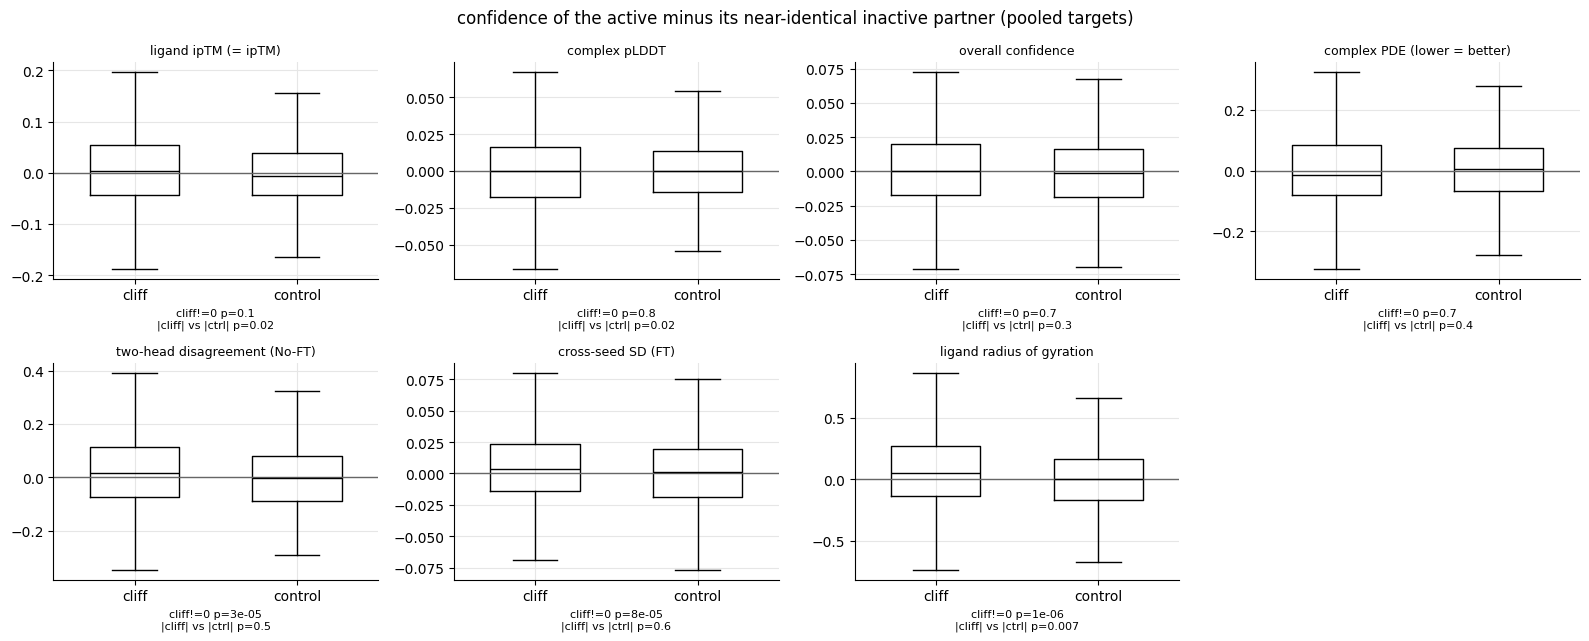

,median (active - inactive),p (delta != 0),p (|delta| cliff vs control)
signal,,,
ligand ipTM (= ipTM),0.0041,0.0982,0.0197
complex pLDDT,0.0000,0.8087,0.0185
overall confidence,0.0003,0.7412,0.3414
complex PDE (lower = better),-0.0126,0.7488,0.3662
two-head disagreement (No-FT),0.0178,0.0000,0.4951
cross-seed SD (FT),0.0038,0.0001,0.6030
ligand radius of gyration,0.0532,0.0000,0.0070


In [18]:
cf = [("ligand_iptm", "ligand ipTM (= ipTM)"), ("complex_plddt", "complex pLDDT"), ("confidence_score", "overall confidence"), ("complex_pde", "complex PDE (lower = better)"),
      ("disagree_noft", "two-head disagreement (No-FT)"), ("cross_seed_sd", "cross-seed SD (FT)"), ("lig_rg", "ligand radius of gyration")]
def lrg(d): return d.id_a.map(Mi.lig_rg) - d.id_b.map(Mi.lig_rg)
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5)); rc = []
for ax, (f, l) in zip(axes.ravel(), cf):
    a = (lrg(CLIFF) if f == "lig_rg" else CLIFF["c_" + f]).dropna(); b = (lrg(CTRL) if f == "lig_rg" else CTRL["c_" + f]).dropna()
    ax.boxplot([a, b], tick_labels=["cliff", "control"], showfliers=False, widths=0.55, medianprops=dict(color=BLK)); ax.axhline(0, color=NEU, lw=1); ax.set_title(l, fontsize=9)
    try: pz_ = stats.wilcoxon(a).pvalue
    except Exception: pz_ = np.nan
    pu = stats.mannwhitneyu(a.abs(), b.abs()).pvalue; ax.set_xlabel(f"cliff!=0 p={pz_:.1g}\n|cliff| vs |ctrl| p={pu:.1g}", fontsize=8); rc.append((l, a.median(), pz_, pu))
axes.ravel()[-1].axis("off"); fig.suptitle("confidence of the active minus its near-identical inactive partner (pooled targets)", fontsize=12); plt.tight_layout(); plt.show()
CONF_T = pd.DataFrame(rc, columns=["signal", "median (active - inactive)", "p (delta != 0)", "p (|delta| cliff vs control)"]).set_index("signal"); display(CONF_T.round(4)); KEY["CONF_T"] = CONF_T

## 11. Does the confidence gap track the score gap?
Across cliff pairs, is a bigger ligand-ipTM difference associated with a bigger score difference? And when a model strongly prefers the inactive partner, is that pose confident?

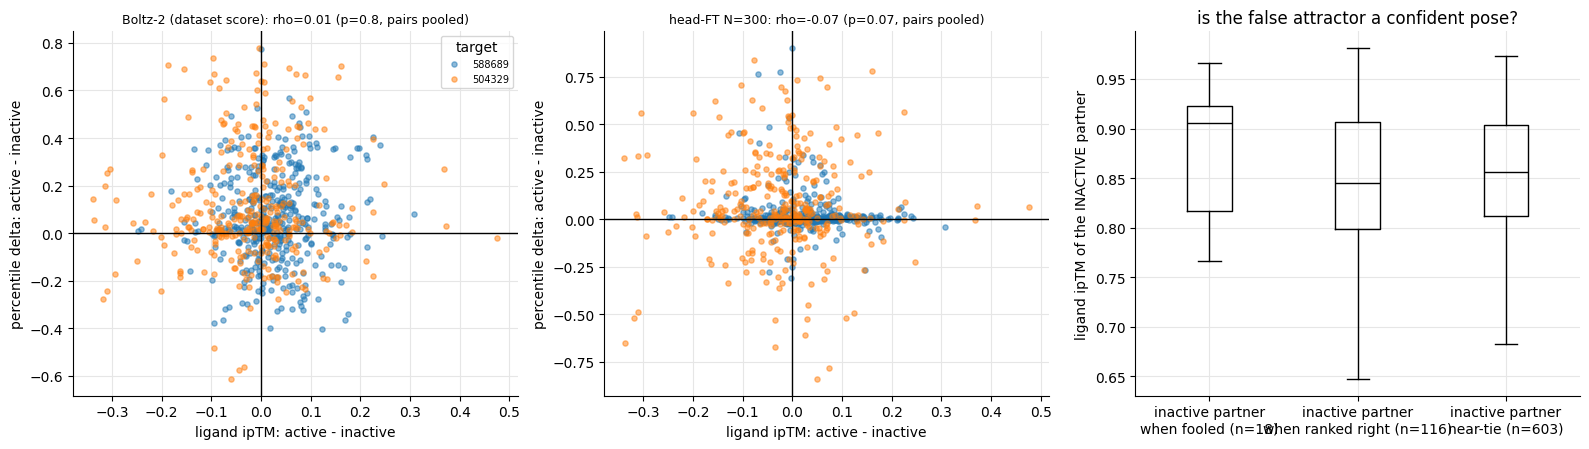

median ligand ipTM of the inactive partner: fooled 0.906 | ranked right 0.845 | near-tie 0.856


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6)); KEY["conf_rho"] = {}
for ax, (m, l) in zip(axes[:2], [("score_boltz2", "Boltz-2 (dataset score)"), ("ft300", "head-FT N=300")]):
    d = CLIFF[["c_ligand_iptm", "d_" + m, "target"]].dropna()
    for t in TL: s = d[d.target == t]; ax.scatter(s.c_ligand_iptm, s["d_" + m], s=14, alpha=0.5, color=TCOL[t], label=SH[t])
    ax.axhline(0, color=BLK, lw=1); ax.axvline(0, color=BLK, lw=1); r, p = stats.spearmanr(d.c_ligand_iptm, d["d_" + m]); KEY["conf_rho"][m] = r
    ax.set_title(f"{l}: rho={r:.2f} (p={p:.1g}, pairs pooled)", fontsize=9); ax.set_xlabel("ligand ipTM: active - inactive"); ax.set_ylabel("percentile delta: active - inactive")
axes[0].legend(fontsize=7, title="target")
fool = CLIFF[CLIFF.d_score_boltz2 < -0.3]; ok = CLIFF[CLIFF.d_score_boltz2 > 0.3]; mid = CLIFF[CLIFF.d_score_boltz2.abs() <= 0.3]
vals = [(f"inactive partner\nwhen fooled (n={len(fool)})", fool.id_b.map(Mi.ligand_iptm)), (f"inactive partner\nwhen ranked right (n={len(ok)})", ok.id_b.map(Mi.ligand_iptm)), (f"inactive partner\nnear-tie (n={len(mid)})", mid.id_b.map(Mi.ligand_iptm))]
axes[2].boxplot([v.dropna() for _, v in vals], tick_labels=[l for l, _ in vals], showfliers=False, medianprops=dict(color=BLK)); axes[2].set_ylabel("ligand ipTM of the INACTIVE partner"); axes[2].set_title("is the false attractor a confident pose?")
plt.tight_layout(); plt.show(); KEY["iptm_partner"] = [v.median() for _, v in vals]
print("median ligand ipTM of the inactive partner: fooled %.3f | ranked right %.3f | near-tie %.3f" % tuple(KEY["iptm_partner"]))

## 12. Did the pose change? Contact profiles of the pair
Each pose's per-residue minimum distance to the ligand gives a contact set (residues within 5 A). Dissimilarity = 1 - Jaccard overlap.

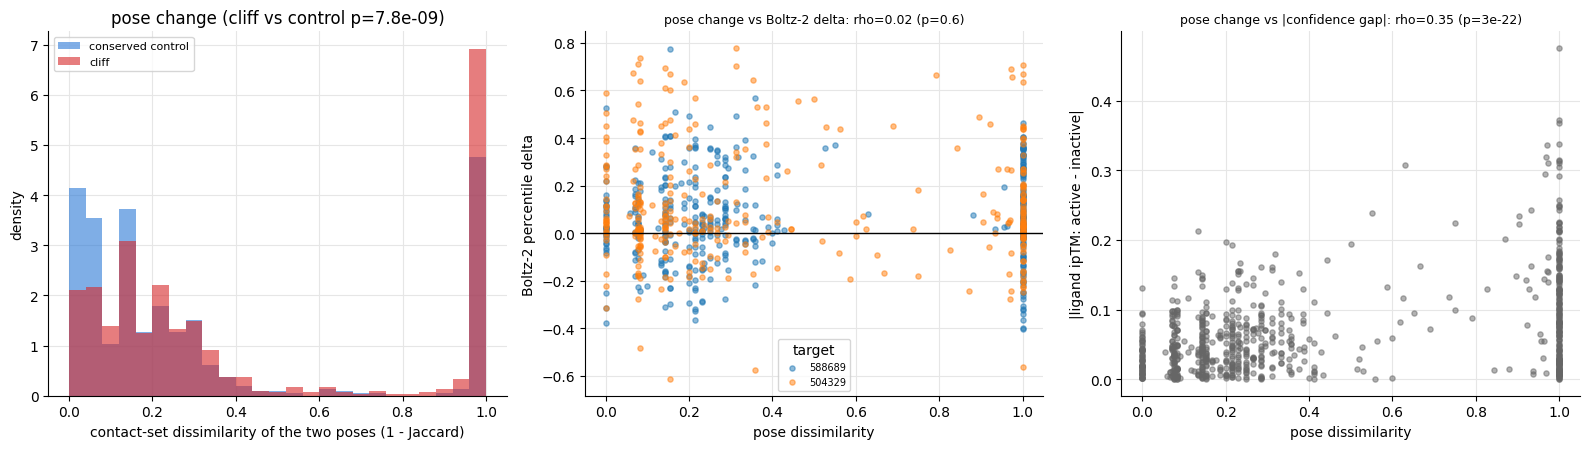

,cliffs,controls,pct_cliffs_no_shared_contact,pct_controls_no_shared_contact,fisher_p_pairs_as_independent
target,,,,,
588689,406,275,29.310,24.727,0.221
504329,331,255,22.054,11.765,0.001


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6)); b = np.linspace(0, 1, 26)
axes[0].hist(CTRL.pose_jdist.dropna(), bins=b, color=CO, alpha=0.6, density=True, label="conserved control"); axes[0].hist(CLIFF.pose_jdist.dropna(), bins=b, color=CL, alpha=0.6, density=True, label="cliff")
pu = stats.mannwhitneyu(CLIFF.pose_jdist.dropna(), CTRL.pose_jdist.dropna()).pvalue
axes[0].set_xlabel("contact-set dissimilarity of the two poses (1 - Jaccard)"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8); axes[0].set_title(f"pose change (cliff vs control p={pu:.2g})")
d = CLIFF[["pose_jdist", "d_score_boltz2", "target"]].dropna()
for t in TL: s = d[d.target == t]; axes[1].scatter(s.pose_jdist, s.d_score_boltz2, s=14, alpha=0.5, color=TCOL[t], label=SH[t])
axes[1].axhline(0, color=BLK, lw=1); r, p = stats.spearmanr(d.pose_jdist, d.d_score_boltz2); axes[1].set_title(f"pose change vs Boltz-2 delta: rho={r:.2f} (p={p:.1g})", fontsize=9); axes[1].set_xlabel("pose dissimilarity"); axes[1].set_ylabel("Boltz-2 percentile delta"); axes[1].legend(fontsize=7, title="target")
d2 = CLIFF[["pose_jdist", "c_ligand_iptm"]].dropna(); axes[2].scatter(d2.pose_jdist, d2.c_ligand_iptm.abs(), s=14, alpha=0.5, color=NEU)
r2, p2 = stats.spearmanr(d2.pose_jdist, d2.c_ligand_iptm.abs()); axes[2].set_title(f"pose change vs |confidence gap|: rho={r2:.2f} (p={p2:.1g})", fontsize=9); axes[2].set_xlabel("pose dissimilarity"); axes[2].set_ylabel("|ligand ipTM: active - inactive|")
plt.tight_layout(); plt.show()
rows = []
for t in TL:
    c_, k_ = CLIFF[CLIFF.target == t], CTRL[CTRL.target == t]; sc = int((c_.pose_jdist >= 0.99).sum()); so = int((k_.pose_jdist >= 0.99).sum())
    pf = stats.fisher_exact([[sc, len(c_) - sc], [so, len(k_) - so]])[1] if len(k_) and len(c_) else np.nan
    rows.append(dict(target=SH[t], cliffs=len(c_), controls=len(k_), pct_cliffs_no_shared_contact=100 * sc / max(1, len(c_)), pct_controls_no_shared_contact=100 * so / max(1, len(k_)), fisher_p_pairs_as_independent=pf))
POSE_T = pd.DataFrame(rows).set_index("target"); display(POSE_T.round(3)); KEY["POSE_T"] = POSE_T

## 13. Where along the protein do the two poses differ?
Mean absolute change in each residue's ligand distance between the two members, along the full sequence, for cliffs and controls, one panel per target (residue numbering is that target's own construct; tags at construct ends are flexible and often give the largest values there).

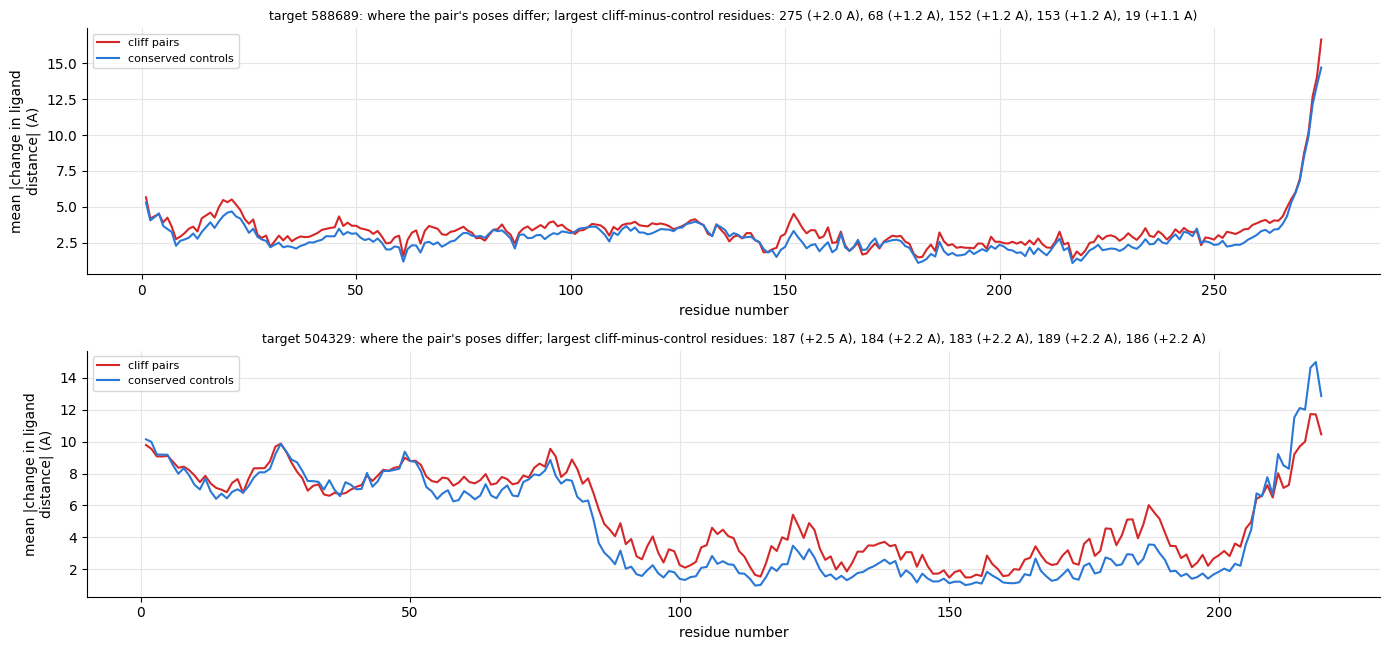

588689: mean over residues of |change in ligand distance|: cliff 3.34 A vs control 2.90 A
504329: mean over residues of |change in ligand distance|: cliff 5.33 A vs control 4.61 A


In [21]:
fig, axes = plt.subplots(NT, 1, figsize=(14, 3.3 * NT), squeeze=False, sharex=False); KEY["resdiff"] = {}
for ax, t in zip(axes.ravel(), TL):
    p = D[t]["P"]; ad = np.abs(D[t]["ma"] - D[t]["mb"]); dc = np.nanmean(ad[(p.kind == "cliff").values], axis=0); dn = np.nanmean(ad[(p.kind == "conserved").values], axis=0); rn = np.arange(1, len(dc) + 1)
    ax.plot(rn, dc, color=CL, label="cliff pairs"); ax.plot(rn, dn, color=CO, label="conserved controls"); ax.set_ylabel("mean |change in ligand\ndistance| (A)"); ax.legend(fontsize=8); ax.set_xlabel("residue number")
    top = np.argsort(-(dc - dn))[:5]; ax.set_title(f"target {SH[t]}: where the pair's poses differ; largest cliff-minus-control residues: " + ", ".join(f"{i+1} ({dc[i]-dn[i]:+.1f} A)" for i in top), fontsize=9)
    KEY["resdiff"][t] = (float(np.nanmean(dc)), float(np.nanmean(dn)))
plt.tight_layout(); plt.show()
for t in TL: print(f"{SH[t]}: mean over residues of |change in ligand distance|: cliff {KEY['resdiff'][t][0]:.2f} A vs control {KEY['resdiff'][t][1]:.2f} A")

## 14. Pose site: do cliff pairs switch binding sites?
Clustering each member's contact profile into two sites (k-means, per target) asks whether the two molecules of a pair sit in the same site, and whether a site switch goes with a large score delta.

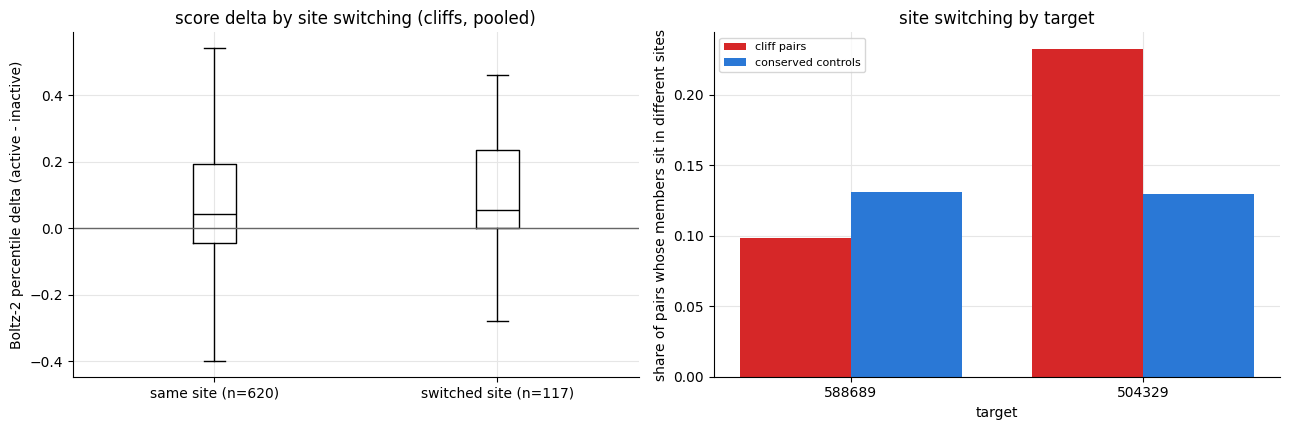

Boltz-2 delta, same site vs switched: median 0.04 vs 0.06 (MWU p=0.18, pairs pooled)


In [22]:
rows = []; fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sw_c = CLIFF[CLIFF.site_a >= 0]; g = [sw_c[~sw_c.switch].d_score_boltz2.dropna(), sw_c[sw_c.switch].d_score_boltz2.dropna()]
axes[0].boxplot(g, tick_labels=[f"same site (n={len(g[0])})", f"switched site (n={len(g[1])})"], showfliers=False, medianprops=dict(color=BLK)); axes[0].axhline(0, color=NEU, lw=1)
axes[0].set_ylabel("Boltz-2 percentile delta (active - inactive)"); axes[0].set_title("score delta by site switching (cliffs, pooled)")
x = np.arange(len(TL)); axes[1].bar(x - 0.19, [CLIFF[CLIFF.target == t].switch.mean() for t in TL], 0.38, color=CL, label="cliff pairs"); axes[1].bar(x + 0.19, [CTRL[CTRL.target == t].switch.mean() for t in TL], 0.38, color=CO, label="conserved controls")
axes[1].set_xticks(x); axes[1].set_xticklabels([SH[t] for t in TL]); axes[1].set_xlabel("target"); axes[1].set_ylabel("share of pairs whose members sit in different sites"); axes[1].legend(fontsize=8); axes[1].set_title("site switching by target")
plt.tight_layout(); plt.show()
sw_p = stats.mannwhitneyu(g[0], g[1]).pvalue if min(len(g[0]), len(g[1])) > 2 else np.nan
print("Boltz-2 delta, same site vs switched: median %.2f vs %.2f (MWU p=%.2g, pairs pooled)" % (g[0].median(), g[1].median(), sw_p))
KEY["switch"] = {t: (CLIFF[CLIFF.target == t].switch.mean(), CTRL[CTRL.target == t].switch.mean()) for t in TL}

## 15. Candidate explanations, compared with the controls
Each observable difference is applied identically to cliffs and to controls. What matters is whether it is *more common among cliffs than among near-identical pairs that both bind*. Odds ratios and Fisher exact tests give that (pairs treated as independent, so p-values are optimistic; the 'targets with OR > 1' column is the cross-target check). Flags overlap, and these are associations: none is proven to cause the loss. Twelve flags are tested, so a Bonferroni threshold would be p < 0.05/12 = 0.004.

,share of cliffs,share of controls,odds ratio,Fisher p,targets with OR > 1
observable difference,,,,,
pose shares no contact residue,0.261,0.185,1.553,0.002,2/2
large ligand-ipTM gap (control 90th pct),0.157,0.102,1.647,0.004,2/2
polar atoms / H-bond donors change,0.373,0.304,1.364,0.012,2/2
fragment size differs by 3+ atoms,0.293,0.151,2.332,0.000,2/2
inactive is smaller (>= 1 heavy atom),0.472,0.347,1.682,0.000,2/2
inactive is less lipophilic (>= 0.5 logP),0.383,0.177,2.875,0.000,2/2
inactive is lighter (>= 20 Da),0.434,0.247,2.337,0.000,2/2
same molecular formula (regioisomer),0.043,0.092,0.446,0.001,0/2
single-atom swap (<=1 atom differs on each side),0.121,0.279,0.355,0.000,0/2


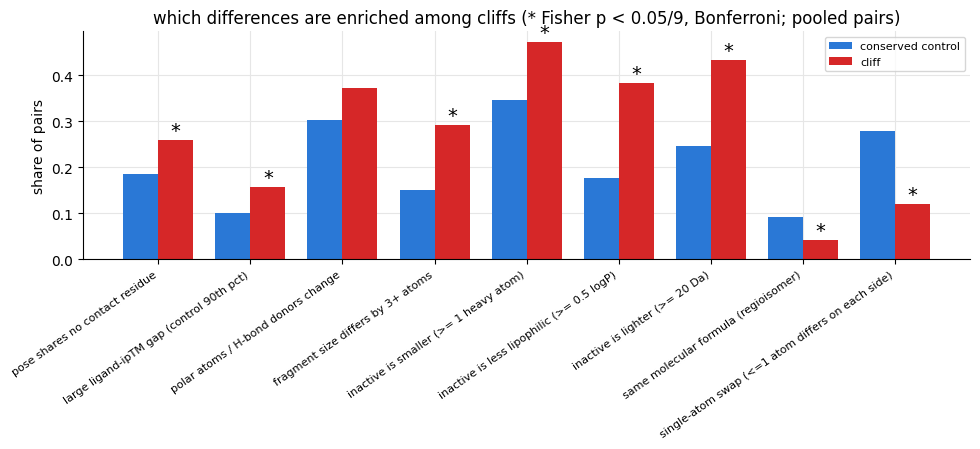

In [23]:
q_conf = {t: CTRL[CTRL.target == t].c_ligand_iptm.abs().quantile(0.9) for t in TL}
def flag_table(df):
    f = pd.DataFrame(index=df.index)
    f["pose shares no contact residue"] = df.pose_jdist >= 0.99
    f["large ligand-ipTM gap (control 90th pct)"] = df.c_ligand_iptm.abs() >= df.target.map(q_conf)
    f["polar atoms / H-bond donors change"] = (df.a_diff_hbd != df.b_diff_hbd) | ((df.a_diff_has_N + df.a_diff_has_O) != (df.b_diff_has_N + df.b_diff_has_O))
    f["fragment size differs by 3+ atoms"] = (df.b_diff_n - df.a_diff_n).abs() >= 3
    f["inactive is smaller (>= 1 heavy atom)"] = df.dp_heavy >= 1
    f["inactive is less lipophilic (>= 0.5 logP)"] = df.dp_logP >= 0.5
    f["inactive is lighter (>= 20 Da)"] = df.dp_MW >= 20
    f["same molecular formula (regioisomer)"] = df.dp_MW.abs() < 0.01
    f["single-atom swap (<=1 atom differs on each side)"] = (df.a_diff_n <= 1) & (df.b_diff_n <= 1)
    return f
XC = P[(P.kind == "cliff") & (P.mcs_ok == 1)].copy(); XK = P[(P.kind == "conserved") & (P.mcs_ok == 1)].copy(); FC = flag_table(XC); FK = flag_table(XK); rows = []
NFLAG = len(FC.columns)
for c in FC.columns:
    a, b = int(FC[c].sum()), int(FK[c].sum()); odds, pf = stats.fisher_exact([[a, len(FC) - a], [b, len(FK) - b]]); n_or = 0; n_ok = 0
    for t in TL:
        ca, cb = FC[c][XC.target == t], FK[c][XK.target == t]
        if len(ca) and len(cb):
            n_ok += 1; o_t = ((ca.sum() + 0.5) / (len(ca) - ca.sum() + 0.5)) / ((cb.sum() + 0.5) / (len(cb) - cb.sum() + 0.5)); n_or += int(o_t > 1)
    rows.append((c, a / len(FC), b / len(FK), odds, pf, f"{n_or}/{n_ok}"))
FT_ = pd.DataFrame(rows, columns=["observable difference", "share of cliffs", "share of controls", "odds ratio", "Fisher p", "targets with OR > 1"]).set_index("observable difference")
display(FT_.round(3)); KEY["FT_"] = FT_; KEY["NFLAG"] = NFLAG
fig, ax = plt.subplots(figsize=(10, 4.6)); x = np.arange(len(FT_)); w = 0.38
ax.bar(x - w / 2, FT_["share of controls"], w, color=CO, label="conserved control"); ax.bar(x + w / 2, FT_["share of cliffs"], w, color=CL, label="cliff")
ax.set_xticks(x); ax.set_xticklabels(FT_.index, rotation=35, ha="right", fontsize=8); ax.set_ylabel("share of pairs"); ax.legend(fontsize=8)
for i, (_, r) in enumerate(FT_.iterrows()):
    if r["Fisher p"] < 0.05 / NFLAG: ax.text(i + w / 2, r["share of cliffs"], "*", ha="center", va="bottom", fontsize=14)
ax.set_title(f"which differences are enriched among cliffs (* Fisher p < 0.05/{NFLAG}, Bonferroni; pooled pairs)"); plt.tight_layout(); plt.show()

**Robustness across partitions.** The same comparison for all pairs, without each target's dominant series, and inside them. Each cell: share of cliffs vs share of controls, odds ratio and Fisher p (optimistic).

In [24]:
parts = [("all pairs", XC, XK), ("without the dominant series", XC[~XC.big], XK[~XK.big]), ("dominant series only", XC[XC.big], XK[XK.big])]; rows = []
for c in FC.columns:
    r = {"observable difference": c}
    for nm, dc, dk in parts:
        fc = flag_table(dc)[c]; fk = flag_table(dk)[c]; a, b = int(fc.sum()), int(fk.sum())
        if len(fc) and len(fk):
            o, p = stats.fisher_exact([[a, len(fc) - a], [b, len(fk) - b]]); r[f"{nm} (n={len(dc)} vs {len(dk)})"] = f"{fc.mean():.2f} vs {fk.mean():.2f}, OR {o:.1f}, p={p:.1g}"
        else: r[f"{nm} (n={len(dc)} vs {len(dk)})"] = "n/a"
    rows.append(r)
ROB = pd.DataFrame(rows).set_index("observable difference"); display(ROB)
KEY["rob_nodom"] = {c: stats.fisher_exact([[int(flag_table(parts[1][1])[c].sum()), len(parts[1][1]) - int(flag_table(parts[1][1])[c].sum())], [int(flag_table(parts[1][2])[c].sum()), len(parts[1][2]) - int(flag_table(parts[1][2])[c].sum())]])[0] for c in FC.columns if len(parts[1][1]) and len(parts[1][2])}

,all pairs (n=737 vs 530),without the dominant series (n=437 vs 385),dominant series only (n=300 vs 145)
observable difference,,,
pose shares no contact residue,"0.26 vs 0.18, OR 1.6, p=0.002","0.22 vs 0.13, OR 1.9, p=0.001","0.32 vs 0.33, OR 1.0, p=0.8"
large ligand-ipTM gap (control 90th pct),"0.16 vs 0.10, OR 1.6, p=0.004","0.16 vs 0.09, OR 1.9, p=0.003","0.15 vs 0.12, OR 1.2, p=0.6"
polar atoms / H-bond donors change,"0.37 vs 0.30, OR 1.4, p=0.01","0.49 vs 0.34, OR 1.9, p=6e-06","0.20 vs 0.22, OR 0.9, p=0.6"
fragment size differs by 3+ atoms,"0.29 vs 0.15, OR 2.3, p=3e-09","0.36 vs 0.17, OR 2.8, p=4e-10","0.19 vs 0.10, OR 2.1, p=0.02"
inactive is smaller (>= 1 heavy atom),"0.47 vs 0.35, OR 1.7, p=9e-06","0.48 vs 0.34, OR 1.8, p=4e-05","0.46 vs 0.37, OR 1.5, p=0.08"
inactive is less lipophilic (>= 0.5 logP),"0.38 vs 0.18, OR 2.9, p=1e-15","0.32 vs 0.18, OR 2.1, p=5e-06","0.47 vs 0.17, OR 4.5, p=2e-10"
inactive is lighter (>= 20 Da),"0.43 vs 0.25, OR 2.3, p=5e-12","0.35 vs 0.21, OR 2.1, p=5e-06","0.55 vs 0.35, OR 2.3, p=8e-05"
same molecular formula (regioisomer),"0.04 vs 0.09, OR 0.4, p=0.0007","0.05 vs 0.11, OR 0.4, p=0.0005","0.04 vs 0.04, OR 1.0, p=1"
single-atom swap (<=1 atom differs on each side),"0.12 vs 0.28, OR 0.4, p=1e-12","0.12 vs 0.31, OR 0.3, p=2e-11","0.12 vs 0.19, OR 0.6, p=0.04"


## 16. Who detects which kind of cliff?
For cliff pairs carrying each observable difference, the share where each signal ranks the active higher (pooled pairs; macro over targets would leave many cells empty). The right-most column is the 'larger molecule' baseline; it is 1.00 in the row defined by the inactive being smaller, by construction. GNINA and Vina exist for only part of the pairs. Several rows are small.

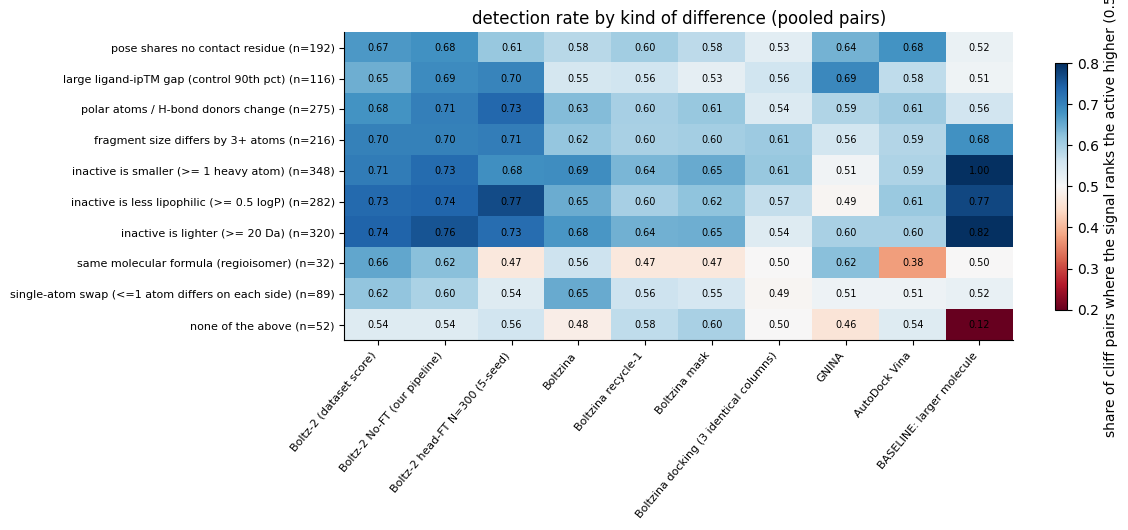

,Boltz-2 (dataset score),Boltz-2 No-FT (our pipeline),Boltz-2 head-FT N=300 (5-seed),Boltzina,Boltzina recycle-1,Boltzina mask,Boltzina docking (3 identical columns),GNINA,AutoDock Vina,BASELINE: larger molecule
pose shares no contact residue (n=192),0.67,0.68,0.61,0.58,0.60,0.58,0.53,0.64,0.68,0.52
large ligand-ipTM gap (control 90th pct) (n=116),0.65,0.69,0.70,0.55,0.56,0.53,0.56,0.69,0.58,0.51
polar atoms / H-bond donors change (n=275),0.68,0.71,0.73,0.63,0.60,0.61,0.54,0.59,0.61,0.56
fragment size differs by 3+ atoms (n=216),0.70,0.70,0.71,0.62,0.60,0.60,0.61,0.56,0.59,0.68
inactive is smaller (>= 1 heavy atom) (n=348),0.71,0.73,0.68,0.69,0.64,0.65,0.61,0.51,0.59,1.00
inactive is less lipophilic (>= 0.5 logP) (n=282),0.73,0.74,0.77,0.65,0.60,0.62,0.57,0.49,0.61,0.77
inactive is lighter (>= 20 Da) (n=320),0.74,0.76,0.73,0.68,0.64,0.65,0.54,0.60,0.60,0.82
same molecular formula (regioisomer) (n=32),0.66,0.62,0.47,0.56,0.47,0.47,0.50,0.62,0.38,0.50
single-atom swap (<=1 atom differs on each side) (n=89),0.62,0.60,0.54,0.65,0.56,0.55,0.49,0.51,0.51,0.52
none of the above (n=52),0.54,0.54,0.56,0.48,0.58,0.60,0.50,0.46,0.54,0.12


In [25]:
cols = [(m, l) for m, l in MODS]; rowsH = []; lab_rows = []
for c in list(FC.columns) + ["none of the above"]:
    mask = (~FC.any(axis=1)) if c == "none of the above" else FC[c]; s = XC[mask.values]
    rowsH.append([rate_ for rate_ in [bcl.rate(s["d_" + m]) for m, _ in cols]] + [bcl.rate(s.dp_heavy)]); lab_rows.append(f"{c} (n={len(s)})")
mat = np.array(rowsH, float); names = [l for _, l in cols] + ["BASELINE: larger molecule"]
fig, ax = plt.subplots(figsize=(12, 5.4)); im = ax.imshow(mat, cmap="RdBu", vmin=0.2, vmax=0.8, aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=50, ha="right", fontsize=8); ax.set_yticks(range(len(lab_rows))); ax.set_yticklabels(lab_rows, fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if np.isfinite(mat[i, j]): ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="share of cliff pairs where the signal ranks the active higher (0.5 = blind)"); ax.set_title("detection rate by kind of difference (pooled pairs)"); plt.tight_layout(); plt.show()
display(pd.DataFrame(mat, index=lab_rows, columns=names).round(2))

## 17. One example per enriched difference
The most similar cliff for each of the three differences most enriched among cliffs, drawn with the changed atoms highlighted.

difference: inactive is less lipophilic (>= 0.5 logP)


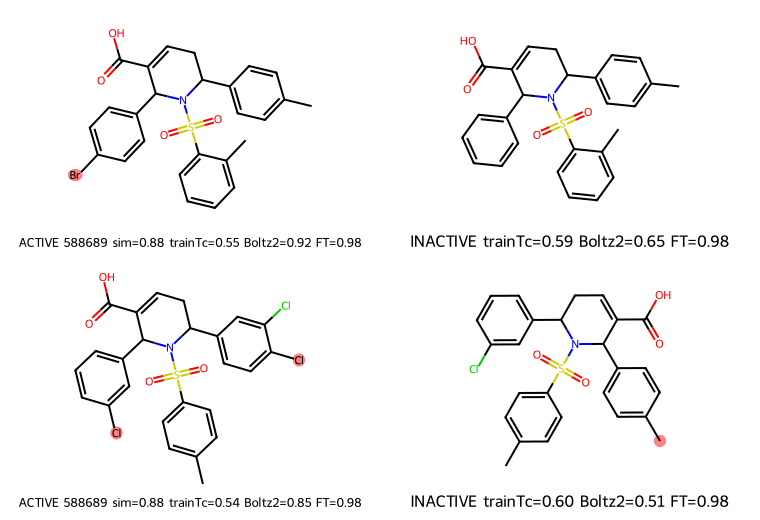

difference: inactive is lighter (>= 20 Da)


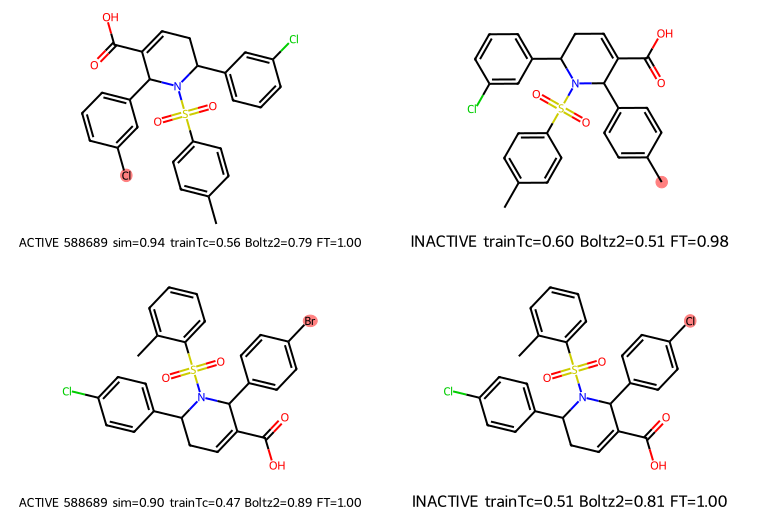

difference: fragment size differs by 3+ atoms


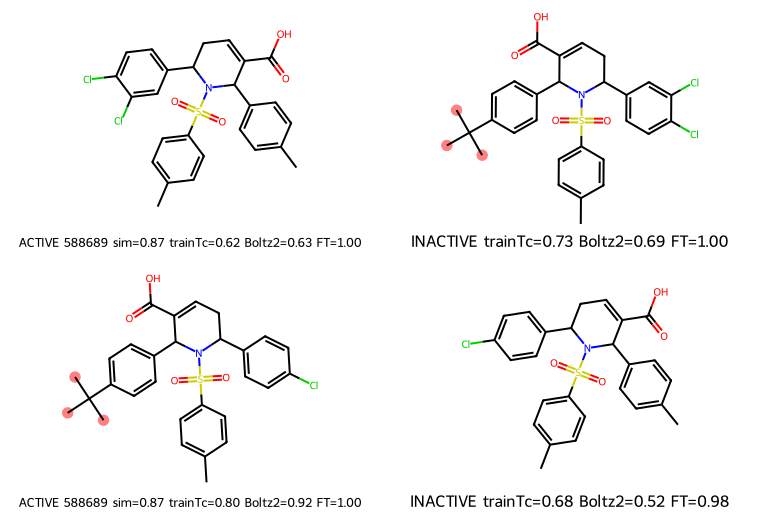

In [26]:
top3 = FT_[FT_["Fisher p"] < 0.1].sort_values("odds ratio", ascending=False).head(3).index.tolist() or list(FT_.sort_values("odds ratio", ascending=False).head(3).index)
for c in top3:
    s = XC[FC[c].values].sort_values("sim", ascending=False)
    if len(s): draw_pairs(s, 2, f"difference: {c}")

# Part B · Where the large deltas are correct

Part A showed that, for near-identical pairs, the models mostly score both members alike. Part B studies the opposite cases: pairs where a model *does* separate the two members by a large margin and gets it **right**.

**Definition.** For a modality, the delta is the active's percentile rank minus the inactive's over the target's eval set. A call is **right** if the delta is above +0.3, **wrong** if below -0.3, and a **tie** otherwise. Note that 'right' and 'wrong' are anchored on the binary label (the active should be ranked above its inactive partner), but the +/-0.3 *size* threshold is defined from the models' own score scale; Part C calibrates the threshold on both-active pairs instead. The primary subject is the Boltz-2 affinity head, taken as right when either the dataset score or our No-FT score clears +0.3 with neither below -0.3. Boltzina, Boltzina docking and head-FT are examined alongside. Every section keeps size and lipophilicity in view and reports how many *independent* actives, partners and series support each claim.

In [27]:
TH = 0.3
def outcome(d): return pd.Series(np.where(d > TH, "right", np.where(d < -TH, "wrong", "tie")), index=d.index).where(d.notna())
refresh()
for m, _ in MODS: CLIFF["o_" + m] = outcome(CLIFF["d_" + m])
mx = CLIFF[["d_score_boltz2", "d_base_noft"]].max(axis=1); mn = CLIFF[["d_score_boltz2", "d_base_noft"]].min(axis=1)
CLIFF["o_b2"] = np.select([(mx > TH) & (mn > -TH), (mn < -TH) & (mx < TH), (mx > TH) & (mn < -TH)], ["right", "wrong", "mixed"], "tie")
OC = {"right": GRN, "tie": NEU, "wrong": CL, "mixed": ORG}; grp = ["right", "tie", "wrong"]
print("outcome of the Boltz-2 affinity head (dataset score or our No-FT, no contradiction), by target:")
display(pd.crosstab(CLIFF.target.map(SH), CLIFF.o_b2).reindex(columns=["right", "tie", "wrong", "mixed"], fill_value=0))
def draw_pairs2(df, n=8, title="", cols=("score_boltz2", "base_noft", "score_boltzina", "docking_score_boltzina")): draw_pairs(df, n, title, cols)

outcome of the Boltz-2 affinity head (dataset score or our No-FT, no contradiction), by target:


o_b2,right,tie,wrong,mixed
target,,,,
504329,77,246,8,0
588689,91,291,24,0


## B1. How many correct large calls are there, and how independent are they?
Right, tie and wrong calls per modality (pooled over targets), for all cliff pairs and without each target's dominant series, then the number of distinct actives and series behind the right calls. A claim resting on two actives is not a pattern.

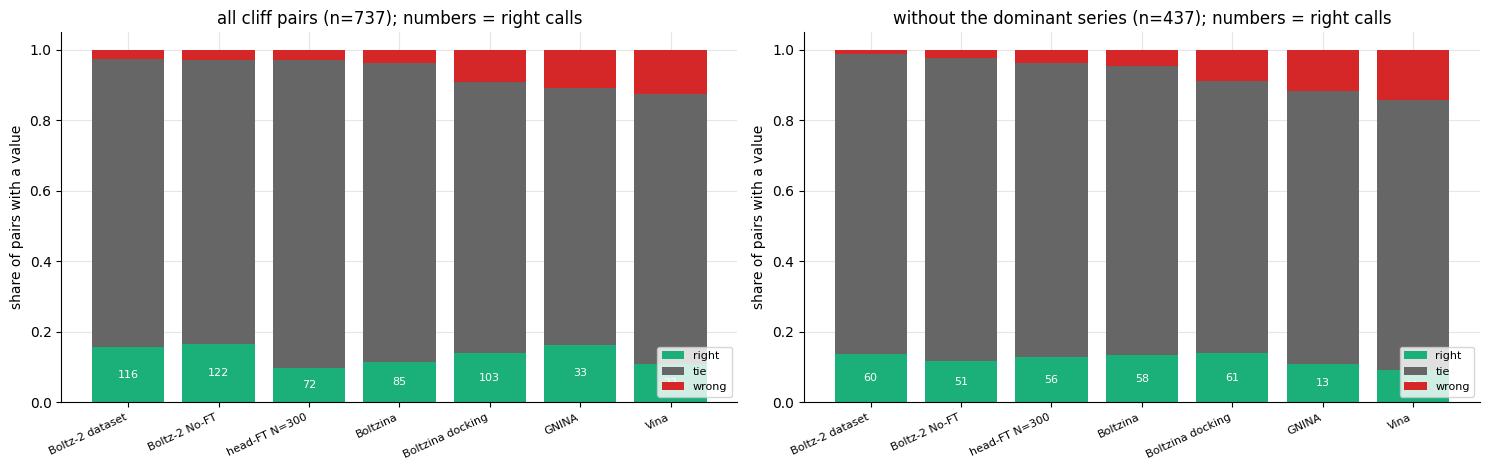

,right calls,wrong calls,distinct actives (right),distinct inactive partners (right),distinct series (right),right in dominant series,right outside it
modality,,,,,,,
Boltz-2 dataset,116,18,68,79,43,56,60
Boltz-2 No-FT,122,20,61,77,41,71,51
head-FT N=300,72,20,53,68,37,16,56
Boltzina,85,27,63,65,46,27,58
Boltzina docking,103,67,56,68,39,42,61
GNINA,33,22,18,23,13,20,13
Vina,22,25,18,14,10,11,11


In [28]:
MM = [("score_boltz2", "Boltz-2 dataset"), ("base_noft", "Boltz-2 No-FT"), ("ft300", "head-FT N=300"), ("score_boltzina", "Boltzina"), ("docking_score_boltzina", "Boltzina docking"), ("score_gnina", "GNINA"), ("score_vina", "Vina")]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (nm, d) in zip(axes, [("all cliff pairs", CLIFF), ("without the dominant series", CLIFF[~CLIFF.big])]):
    cnt = pd.DataFrame({l: d["o_" + m].value_counts() for m, l in MM}).reindex(["right", "tie", "wrong"]).fillna(0); frac = cnt / cnt.sum(); bottom = np.zeros(len(MM))
    for o in ["right", "tie", "wrong"]: ax.bar(range(len(MM)), frac.loc[o], bottom=bottom, color=OC[o], label=o); bottom += frac.loc[o].values
    for i, (m, l) in enumerate(MM): ax.text(i, frac.loc["right"].iloc[i] / 2, int(cnt.loc["right"].iloc[i]), ha="center", va="center", fontsize=8, color="white")
    ax.set_xticks(range(len(MM))); ax.set_xticklabels([l for _, l in MM], rotation=25, ha="right", fontsize=8); ax.set_ylabel("share of pairs with a value"); ax.set_title(f"{nm} (n={len(d)}); numbers = right calls"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()
rows = []
for m, l in MM:
    R = CLIFF[CLIFF["o_" + m] == "right"]; W = CLIFF[CLIFF["o_" + m] == "wrong"]
    rows.append((l, len(R), len(W), R.id_a.nunique(), R.id_b.nunique(), R.series.nunique(), int(R.big.sum()), int((~R.big).sum())))
B1 = pd.DataFrame(rows, columns=["modality", "right calls", "wrong calls", "distinct actives (right)", "distinct inactive partners (right)", "distinct series (right)", "right in dominant series", "right outside it"]).set_index("modality"); display(B1); KEY["B1"] = B1

**Sensitivity to the threshold.** The 0.3 cut-off is arbitrary. The same census at other cut-offs, for the Boltz-2 affinity head, to see whether the picture (few calls, few actives and partners, concentrated in dominant series) depends on it.

In [29]:
mx_ = CLIFF[["d_score_boltz2", "d_base_noft"]].max(axis=1); mn_ = CLIFF[["d_score_boltz2", "d_base_noft"]].min(axis=1); rows = []
for th in (0.2, 0.3, 0.4, 0.5):
    right = (mx_ > th) & (mn_ > -th); wrong = (mn_ < -th) & (mx_ < th); R_ = CLIFF[right]
    rows.append((th, int(right.sum()), int(wrong.sum()), R_.id_a.nunique(), R_.id_b.nunique(), R_.series.nunique(), round(100 * R_.big.mean(), 0) if len(R_) else np.nan, int((~R_.big).sum())))
B1S = pd.DataFrame(rows, columns=["delta threshold", "right calls", "wrong calls", "distinct actives (right)", "distinct inactive partners (right)", "distinct series (right)", "% of right calls in the dominant series", "right calls outside it"]).set_index("delta threshold"); display(B1S); KEY["B1S"] = B1S

,right calls,wrong calls,distinct actives (right),distinct inactive partners (right),distinct series (right),% of right calls in the dominant series,right calls outside it
delta threshold,,,,,,,
0.2,247,80,118,150,77,53.0,117
0.3,168,32,85,101,55,55.0,75
0.4,97,9,60,69,34,47.0,51
0.5,55,5,38,44,21,47.0,29


## B2. Do the modalities get the same pairs right?
Overlap of the right-call sets. If different methods were reading the same real signal they would agree on which pairs are separable.

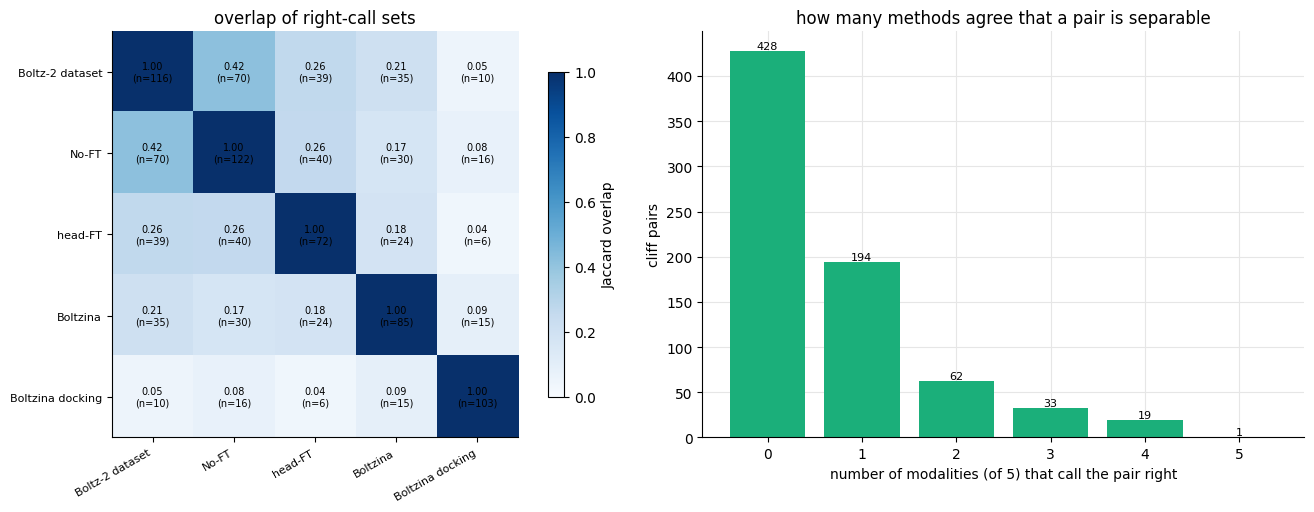

pairs called right by at least 3 of 5 modalities: 53 | by all 5: 1
observed overlap of right-call sets against chance (10 comparisons; Bonferroni threshold p < 0.0050; pooled pairs, optimistic):


,right (A),right (B),observed overlap,expected by chance,p (more overlap than chance),Bonferroni p<0.0050
pair of modalities,,,,,,
Boltz-2 dataset & No-FT,116,122,70,19.2,0.0000,True
Boltz-2 dataset & head-FT,116,72,39,11.3,0.0000,True
Boltz-2 dataset & Boltzina,116,85,35,13.4,0.0000,True
Boltz-2 dataset & Boltzina docking,116,103,10,16.2,0.9796,False
No-FT & head-FT,122,72,40,11.9,0.0000,True
No-FT & Boltzina,122,85,30,14.1,0.0000,True
No-FT & Boltzina docking,122,103,16,17.1,0.6642,False
head-FT & Boltzina,72,85,24,8.3,0.0000,True
head-FT & Boltzina docking,72,103,6,10.1,0.9563,False


In [30]:
keys = [("score_boltz2", "Boltz-2 dataset"), ("base_noft", "No-FT"), ("ft300", "head-FT"), ("score_boltzina", "Boltzina"), ("docking_score_boltzina", "Boltzina docking")]
sets = {l: set(CLIFF.index[CLIFF["o_" + m] == "right"]) for m, l in keys}
J = np.array([[len(sets[a] & sets[b]) / max(1, len(sets[a] | sets[b])) for _, b in keys] for _, a in keys]); Nn = np.array([[len(sets[a] & sets[b]) for _, b in keys] for _, a in keys])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2)); im = axes[0].imshow(J, cmap="Blues", vmin=0, vmax=1); axes[0].grid(False)
axes[0].set_xticks(range(len(keys))); axes[0].set_xticklabels([l for _, l in keys], rotation=30, ha="right", fontsize=8); axes[0].set_yticks(range(len(keys))); axes[0].set_yticklabels([l for _, l in keys], fontsize=8)
for i in range(len(keys)):
    for j in range(len(keys)): axes[0].text(j, i, f"{J[i, j]:.2f}\n(n={Nn[i, j]})", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[0], shrink=0.8, label="Jaccard overlap"); axes[0].set_title("overlap of right-call sets")
nright = sum((CLIFF["o_" + m] == "right").astype(int) for m, _ in keys); vc = nright.value_counts().sort_index(); axes[1].bar(vc.index, vc.values, color=GRN)
for x_, y_ in zip(vc.index, vc.values): axes[1].text(x_, y_, int(y_), ha="center", va="bottom", fontsize=8)
axes[1].set_xlabel("number of modalities (of 5) that call the pair right"); axes[1].set_ylabel("cliff pairs"); axes[1].set_title("how many methods agree that a pair is separable"); plt.tight_layout(); plt.show()
print("pairs called right by at least 3 of 5 modalities:", int((nright >= 3).sum()), "| by all 5:", int((nright == 5).sum()))
from scipy.stats import hypergeom
rows = []; n_ = len(CLIFF)
for i, (_, a) in enumerate(keys):
    for j, (_, b) in enumerate(keys):
        if i < j:
            A_, B_ = sets[a], sets[b]; obs = len(A_ & B_); exp = len(A_) * len(B_) / n_; rows.append((f"{a} & {b}", len(A_), len(B_), obs, round(exp, 1), hypergeom.sf(obs - 1, n_, len(A_), len(B_))))
B2 = pd.DataFrame(rows, columns=["pair of modalities", "right (A)", "right (B)", "observed overlap", "expected by chance", "p (more overlap than chance)"]).set_index("pair of modalities")
B2["Bonferroni p<%.4f" % (0.05 / len(B2))] = B2["p (more overlap than chance)"] < 0.05 / len(B2)
print(f"observed overlap of right-call sets against chance ({len(B2)} comparisons; Bonferroni threshold p < {0.05/len(B2):.4f}; pooled pairs, optimistic):"); display(B2.round(4)); KEY["B2"] = B2; KEY["n_ge3"] = int((nright >= 3).sum()); KEY["n_all5"] = int((nright == 5).sum())

## B3. The strongest correct calls, drawn
Pairs where the Boltz-2 affinity head is right, ranked by delta size (ties broken by similarity); differing atoms highlighted; legend gives percentiles for Boltz-2 dataset, No-FT, Boltzina and docking (active first, inactive second).

similarity range of these pairs: 0.60 to 0.72
Strongest correct calls by the Boltz-2 affinity head (largest positive delta), one row per inactive partner


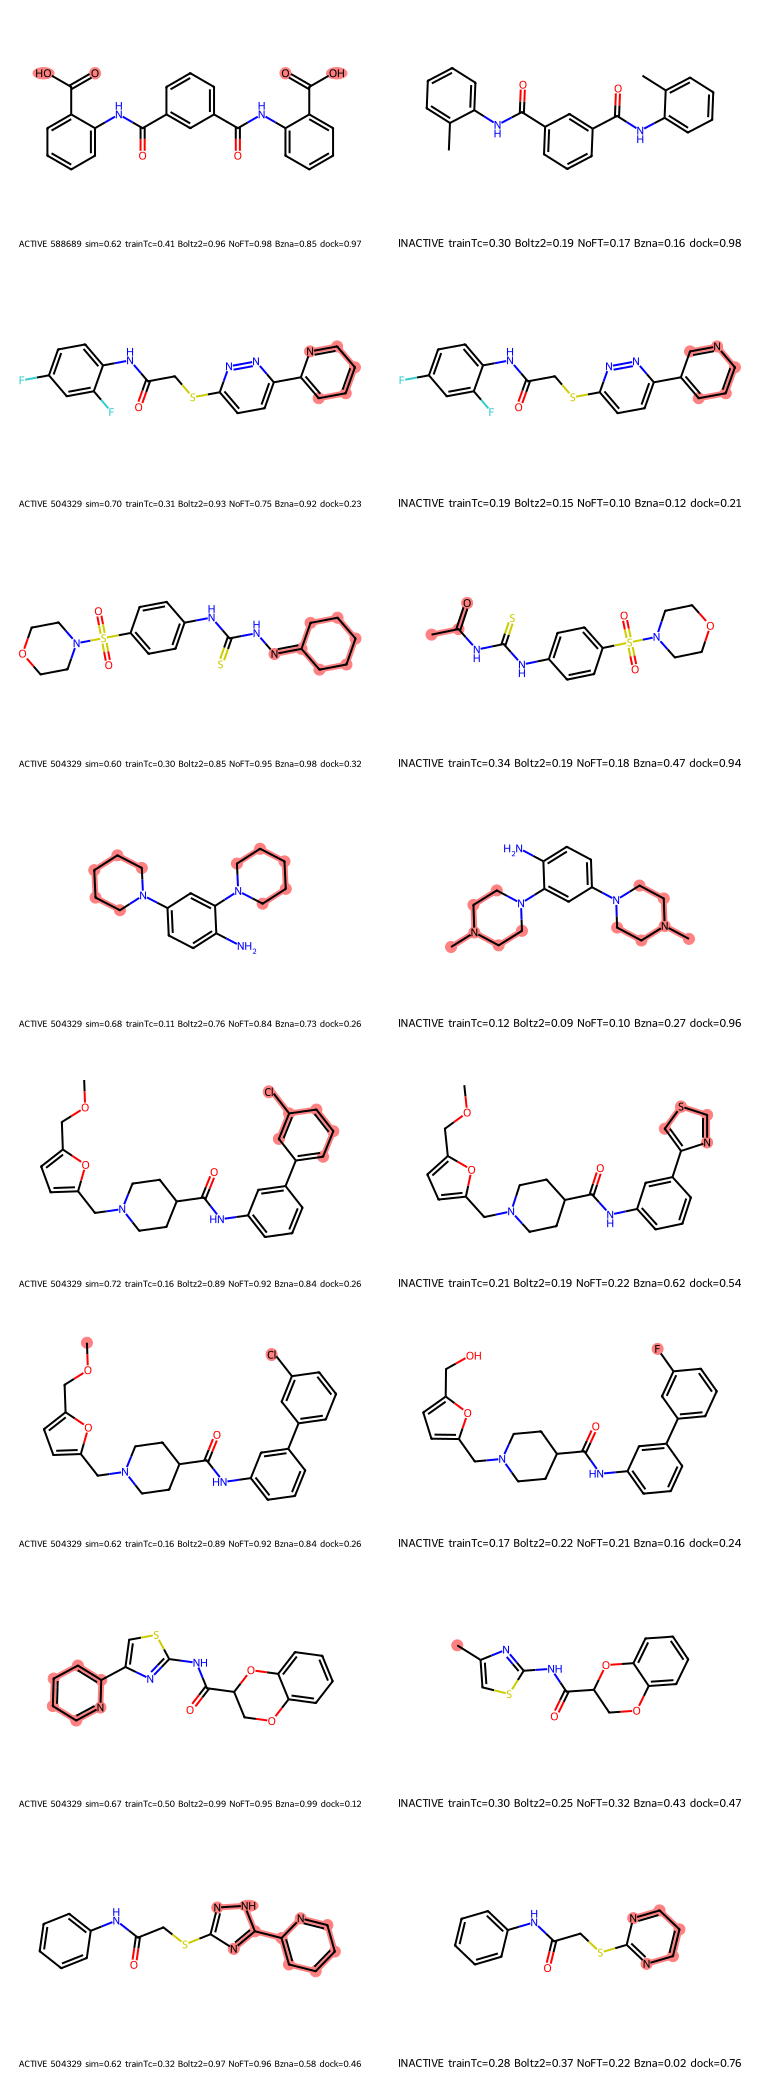

In [31]:
CLIFF["b2_delta"] = CLIFF[["d_score_boltz2", "d_base_noft"]].mean(axis=1)
top = CLIFF[(CLIFF.o_b2 == "right") & (CLIFF.mcs_ok == 1)].sort_values(["b2_delta", "sim"], ascending=False).drop_duplicates("id_b")
if len(top): print("similarity range of these pairs: %.2f to %.2f" % (top.head(8).sim.min(), top.head(8).sim.max()))
draw_pairs2(top, 8, "Strongest correct calls by the Boltz-2 affinity head (largest positive delta), one row per inactive partner")

### B3c. Are the correct calls the actives that resemble the training actives?
For every cliff pair the active member's highest ECFP4 Tanimoto to a training active (**trainTc**) is compared between pairs the Boltz-2 affinity head gets right and pairs it gets wrong. Pairs are not independent (they share actives and series), so the Mann-Whitney p-values are descriptive only; the series-level bootstrap in Part C is the inference that matters.

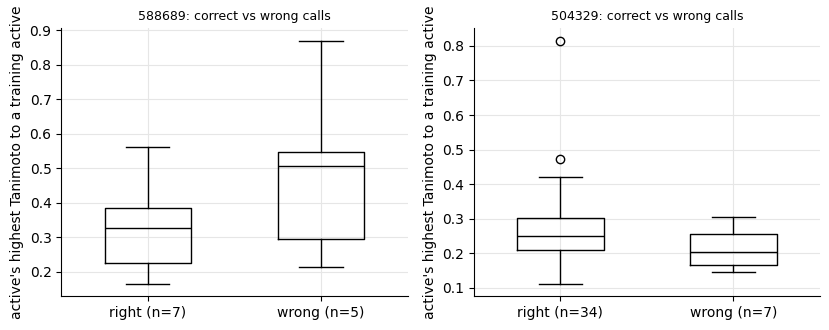

,n_right,n_wrong,median_right,median_wrong,MW_p
target,,,,,
588689,7,5,0.327,0.507,0.343
504329,34,7,0.252,0.203,0.206


distinct actives per pair set; pairs sharing an active are counted once. Descriptive only (series are not independent).


In [32]:
from scipy.stats import mannwhitneyu
rows = []; fig, AX = tgrid(max(NT, 1), w=4.2, h=3.4)
for ax, t in zip(AX, TL):
    d = CLIFF[CLIFF.target == t].drop_duplicates("id_a").copy(); d["trainTc"] = train_tc(t, d.smiles_a.values)
    if d.trainTc.isna().all(): ax.axis("off"); print(f"{SH[t]}: pending: no training-set actives available"); continue
    g = {k: d[d.o_b2 == k].trainTc.dropna().values for k in ("right", "wrong")}
    ax.boxplot([g["right"], g["wrong"]], tick_labels=[f"right (n={len(g['right'])})", f"wrong (n={len(g['wrong'])})"], showfliers=True, widths=0.5, medianprops=dict(color=BLK))
    ax.set_ylabel("active's highest Tanimoto to a training active"); ax.set_title(f"{SH[t]}: correct vs wrong calls", fontsize=9)
    rows.append(dict(target=SH[t], n_right=len(g["right"]), n_wrong=len(g["wrong"]), median_right=np.median(g["right"]) if len(g["right"]) else np.nan, median_wrong=np.median(g["wrong"]) if len(g["wrong"]) else np.nan,
                     MW_p=mannwhitneyu(g["right"], g["wrong"]).pvalue if len(g["right"]) > 2 and len(g["wrong"]) > 2 else np.nan))
plt.tight_layout(); plt.show()
if rows: display(pd.DataFrame(rows).set_index("target").round(3)); print("distinct actives per pair set; pairs sharing an active are counted once. Descriptive only (series are not independent).")

### B3b. How similar are the correct calls, and how independent?
Outcome by similarity bin, reuse of inactive partners (one inactive paired with several actives is one observation), and a gallery of the most similar pairs.

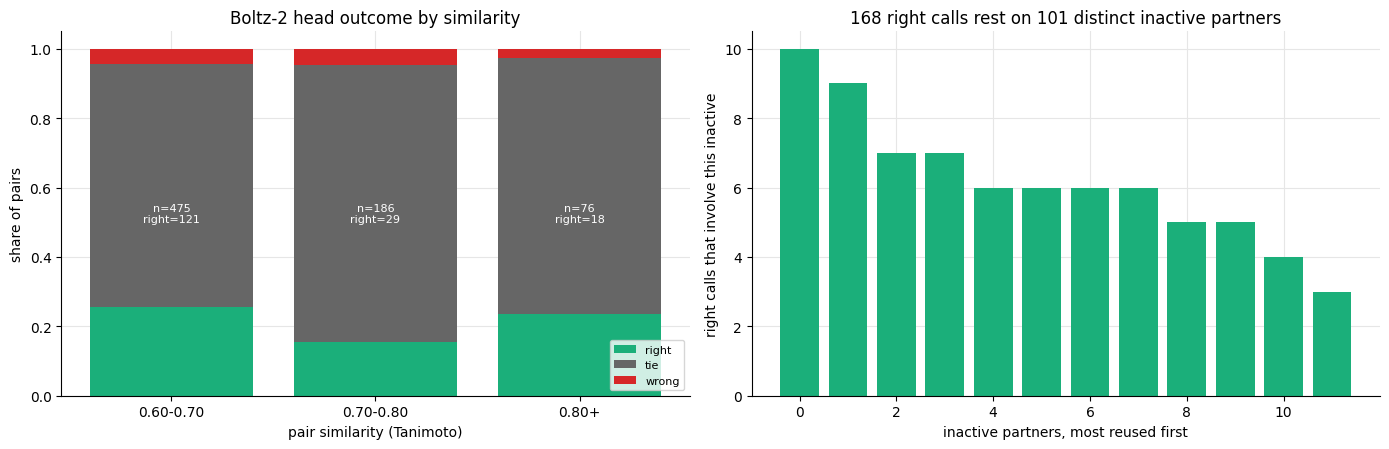

right calls 168; distinct inactive partners 101; distinct actives 85; the 3 most reused partners account for 26 calls
right calls at similarity >= 0.8: 18 | wrong calls at >= 0.8: 2


In [33]:
CLIFF["sb"] = pd.cut(CLIFF.sim, [0.6, 0.7, 0.8, 1.01], right=False, labels=["0.60-0.70", "0.70-0.80", "0.80+"])
ct = pd.crosstab(CLIFF.sb, CLIFF.o_b2).reindex(columns=["right", "tie", "wrong"], fill_value=0); fr = ct.div(ct.sum(1), axis=0).fillna(0); R = CLIFF[CLIFF.o_b2 == "right"]; pc_ = R.id_b.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6)); bottom = np.zeros(len(fr))
for o in ["right", "tie", "wrong"]: axes[0].bar(range(len(fr)), fr[o], bottom=bottom, color=OC[o], label=o); bottom += fr[o].values
for i, (b_, r_) in enumerate(ct.iterrows()): axes[0].text(i, 0.5, f"n={int(r_.sum())}\nright={int(r_['right'])}", ha="center", fontsize=8, color="white")
axes[0].set_xticks(range(len(fr))); axes[0].set_xticklabels(fr.index); axes[0].set_xlabel("pair similarity (Tanimoto)"); axes[0].set_ylabel("share of pairs"); axes[0].legend(fontsize=8, loc="lower right"); axes[0].set_title("Boltz-2 head outcome by similarity")
axes[1].bar(range(min(12, len(pc_))), pc_.values[:12], color=GRN); axes[1].set_xlabel("inactive partners, most reused first"); axes[1].set_ylabel("right calls that involve this inactive"); axes[1].set_title(f"{len(R)} right calls rest on {R.id_b.nunique()} distinct inactive partners")
plt.tight_layout(); plt.show()
KEY["B3"] = dict(right=len(R), n_act=R.id_a.nunique(), n_part=R.id_b.nunique(), n_series=R.series.nunique(), dom_share=R.big.mean() if len(R) else np.nan, top3=int(pc_.head(3).sum()),
                 right_hi=int((R.sim >= 0.8).sum()), wrong_hi=int(((CLIFF.o_b2 == "wrong") & (CLIFF.sim >= 0.8)).sum()), right_rate_bins=(ct["right"] / ct.sum(1)).round(2).to_dict())
print(f"right calls {len(R)}; distinct inactive partners {R.id_b.nunique()}; distinct actives {R.id_a.nunique()}; the 3 most reused partners account for {KEY['B3']['top3']} calls")
print("right calls at similarity >= 0.8:", KEY["B3"]["right_hi"], "| wrong calls at >= 0.8:", KEY["B3"]["wrong_hi"])

Correct calls among the most identical pairs (Tanimoto >= 0.8), one per active and per inactive partner


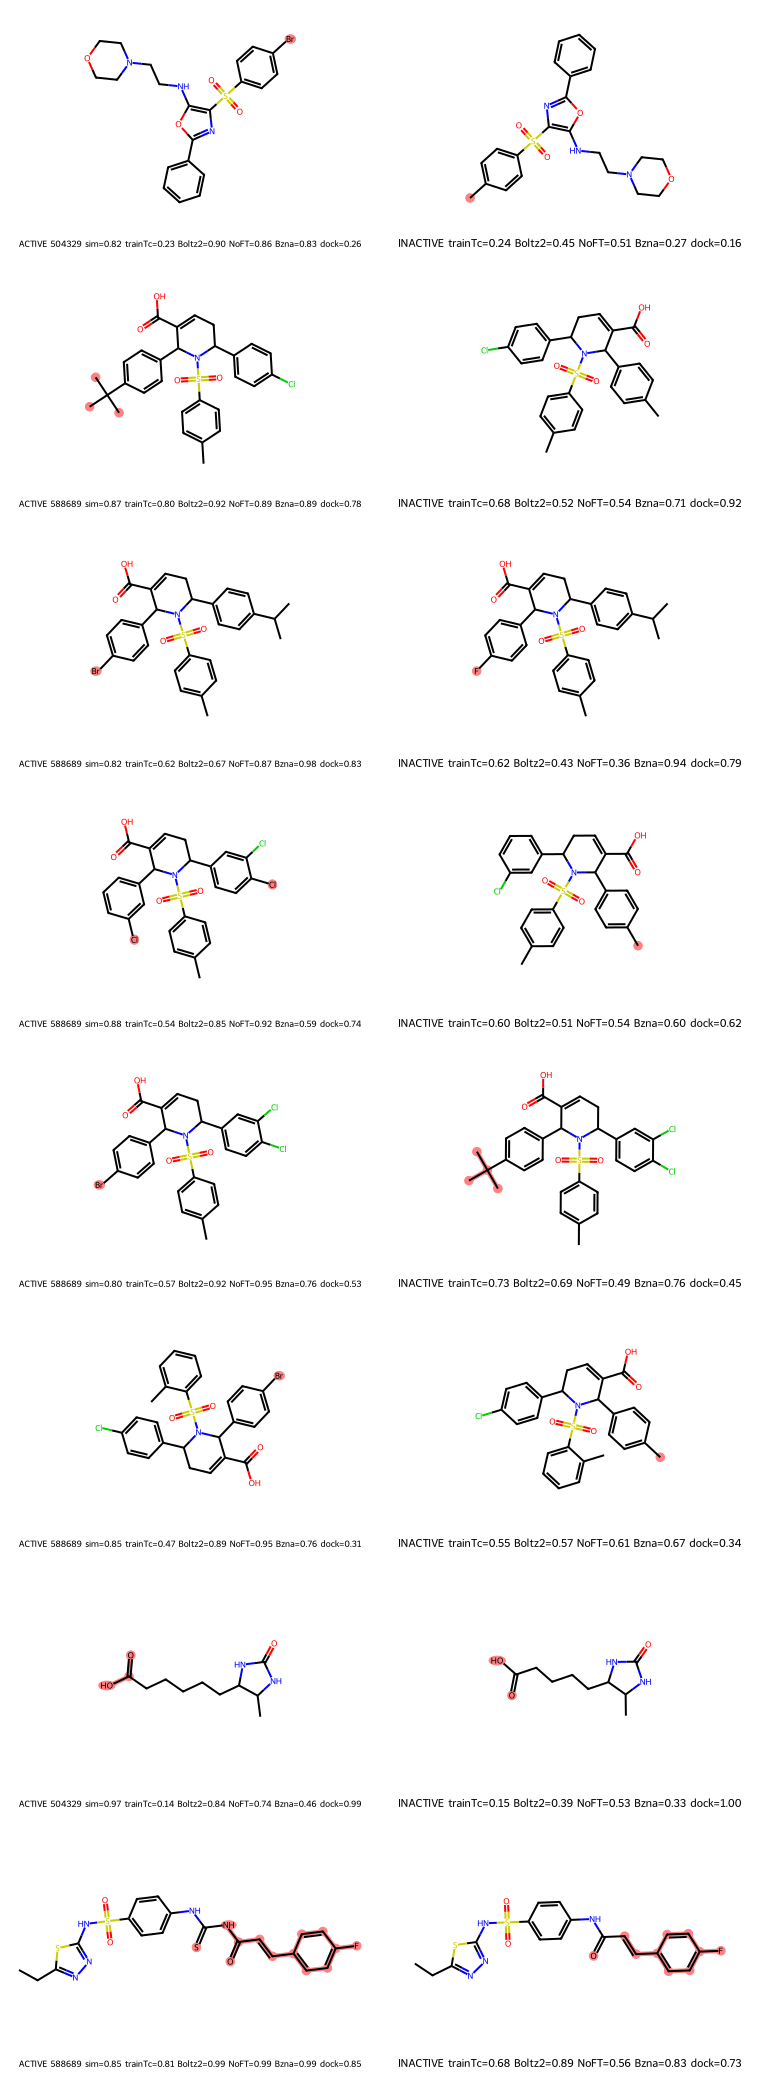

In [34]:
hi = CLIFF[(CLIFF.o_b2 == "right") & (CLIFF.sim >= 0.8) & (CLIFF.mcs_ok == 1)].sort_values("b2_delta", ascending=False).drop_duplicates("id_a").drop_duplicates("id_b")
draw_pairs2(hi, 8, "Correct calls among the most identical pairs (Tanimoto >= 0.8), one per active and per inactive partner")

## B4. Is it just size and lipophilicity?
Size and lipophilicity difference between active and inactive for pairs the Boltz-2 head gets right, ties on, or gets wrong. If correct calls are simply pairs where the active is larger or greasier, the right box sits clearly above zero and the wrong box below.

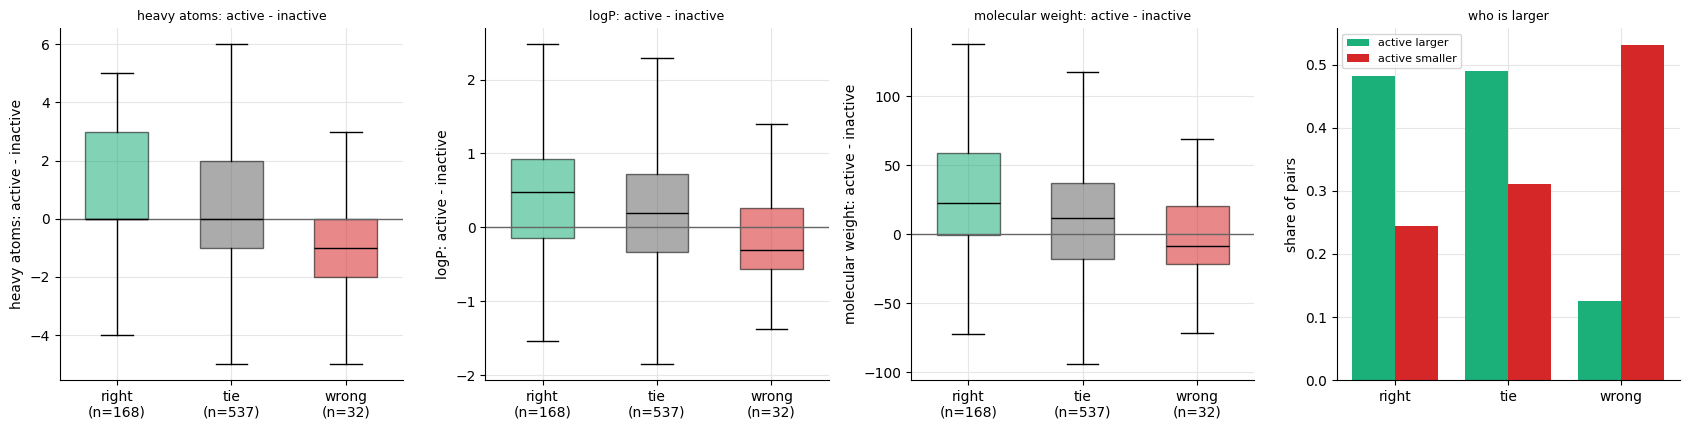

heavy atoms  median (active-inactive): right +0.00 | tie +0.00 | right vs tie Mann-Whitney p=0.29 (pairs pooled)
logP         median (active-inactive): right +0.47 | tie +0.19 | right vs tie Mann-Whitney p=0.011 (pairs pooled)
MW           median (active-inactive): right +22.82 | tie +12.05 | right vs tie Mann-Whitney p=1.2e-05 (pairs pooled)


In [35]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
for ax, (c, l) in zip(axes[:3], [("dp_heavy", "heavy atoms: active - inactive"), ("dp_logP", "logP: active - inactive"), ("dp_MW", "molecular weight: active - inactive")]):
    boxes(ax, [CLIFF[CLIFF.o_b2 == g][c].dropna() for g in grp], [f"{g}\n(n={int((CLIFF.o_b2 == g).sum())})" for g in grp], [OC[g] for g in grp], l, l)
share = [(CLIFF[CLIFF.o_b2 == g].dp_heavy > 0).mean() for g in grp]; sm_ = [(CLIFF[CLIFF.o_b2 == g].dp_heavy < 0).mean() for g in grp]; x = np.arange(3)
axes[3].bar(x - 0.19, share, 0.38, color=GRN, label="active larger"); axes[3].bar(x + 0.19, sm_, 0.38, color=CL, label="active smaller"); axes[3].set_xticks(x); axes[3].set_xticklabels(grp); axes[3].set_ylabel("share of pairs"); axes[3].legend(fontsize=8); axes[3].set_title("who is larger", fontsize=9)
plt.tight_layout(); plt.show(); KEY["B4"] = {}
for c, l in [("dp_heavy", "heavy atoms"), ("dp_logP", "logP"), ("dp_MW", "MW")]:
    a = CLIFF[CLIFF.o_b2 == "right"][c].dropna(); b = CLIFF[CLIFF.o_b2 == "tie"][c].dropna(); pv = stats.mannwhitneyu(a, b).pvalue if len(a) > 2 else np.nan
    KEY["B4"][l] = (a.median(), b.median(), pv); print(f"{l:<12} median (active-inactive): right {a.median():+.2f} | tie {b.median():+.2f} | right vs tie Mann-Whitney p={pv:.2g} (pairs pooled)")

## B5. Does the size of the delta scale with the size of the property difference?
If the head were reading lipophilicity or mass, a bigger property difference should give a bigger score delta across all cliff pairs.

Boltz-2 dataset vs logP difference: Spearman all pairs rho=0.16 (p=1.9e-05); non-dominant series only rho=0.11 (p=0.028, n=437); colours = targets
No-FT vs logP difference: Spearman all pairs rho=0.13 (p=0.00047); non-dominant series only rho=0.07 (p=0.12, n=437); colours = targets
Boltz-2 dataset vs MW difference: Spearman all pairs rho=0.21 (p=7.6e-09); non-dominant series only rho=0.14 (p=0.0035, n=437); colours = targets


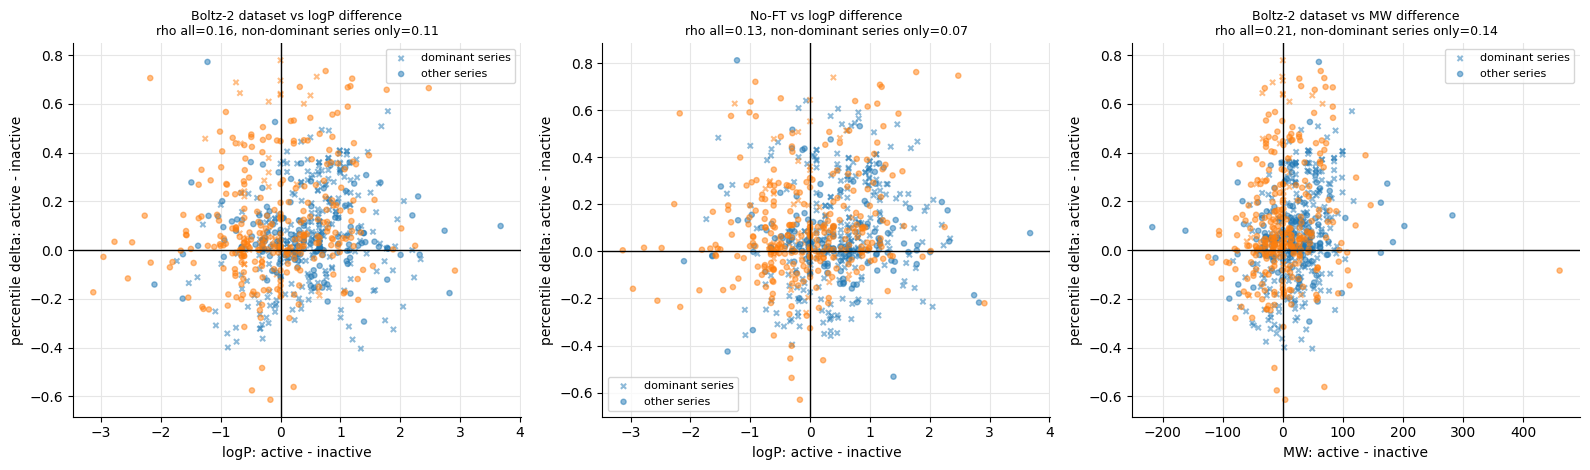

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8)); KEY["B5"] = {}
for ax, (dcol, pcol, l) in zip(axes, [("d_score_boltz2", "dp_logP", "Boltz-2 dataset vs logP difference"), ("d_base_noft", "dp_logP", "No-FT vs logP difference"), ("d_score_boltz2", "dp_MW", "Boltz-2 dataset vs MW difference")]):
    d = CLIFF[[dcol, pcol, "big", "target"]].dropna()
    for b_, mk in [(True, "x"), (False, "o")]:
        s = d[d.big == b_]; ax.scatter(s[pcol], s[dcol], s=14, alpha=0.5, marker=mk, color=[TCOL[t] for t in s.target], label="dominant series" if b_ else "other series")
    r, p = stats.spearmanr(d[pcol], d[dcol]); r2, p2 = stats.spearmanr(d[~d.big][pcol], d[~d.big][dcol]); KEY["B5"][l] = (r, r2)
    ax.axhline(0, color=BLK, lw=1); ax.axvline(0, color=BLK, lw=1); ax.set_xlabel(pcol.replace("dp_", "") + ": active - inactive"); ax.set_ylabel("percentile delta: active - inactive")
    ax.set_title(f"{l}\nrho all={r:.2f}, non-dominant series only={r2:.2f}", fontsize=9); ax.legend(fontsize=8); print(f"{l}: Spearman all pairs rho={r:.2f} (p={p:.2g}); non-dominant series only rho={r2:.2f} (p={p2:.2g}, n={len(d[~d.big])}); colours = targets")
plt.tight_layout(); plt.show()

## B6. The non-trivial correct calls
Restrict to pairs where the trivial explanation is unavailable: the active is **not larger** and **not more lipophilic** than the inactive (heavy-atom difference <= 0 and logP difference <= 0.1). Here a right call cannot be a size or greasiness effect.

,right,wrong,pairs with a value,distinct actives (right),distinct series (right)
modality,,,,,
Boltz-2 dataset,19,13,229,16,10
Boltz-2 No-FT,28,11,229,22,11
head-FT N=300,27,8,229,21,12
Boltzina,19,12,229,19,14
Boltzina docking,34,20,229,29,19
GNINA,11,6,62,10,8
Vina,5,8,62,5,4


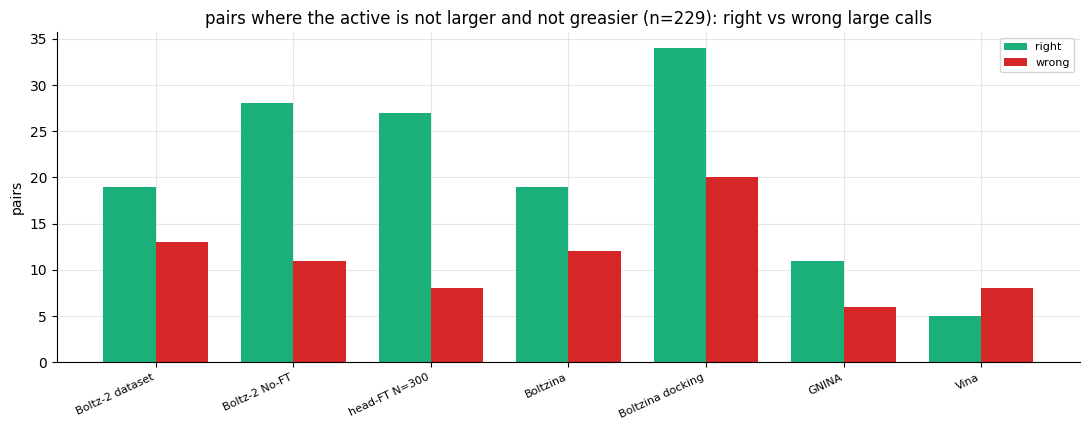

Non-trivial correct calls (No-FT or Boltzina), one per active


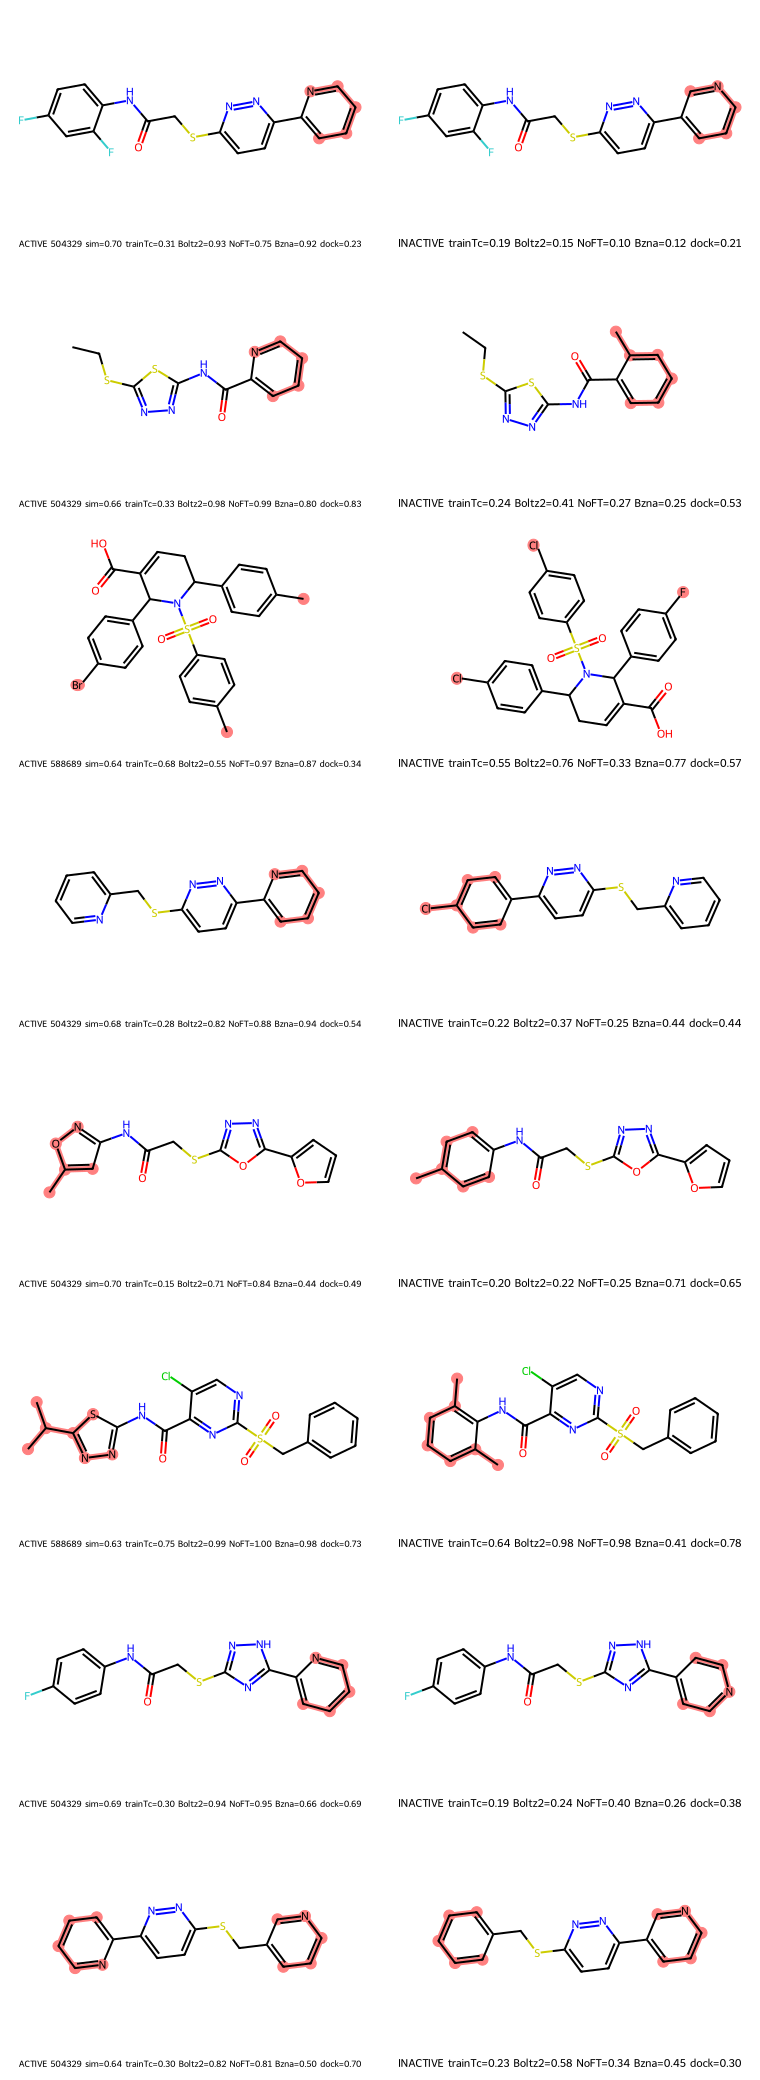

In [37]:
NT_ = CLIFF[(CLIFF.dp_heavy <= 0) & (CLIFF.dp_logP <= 0.1)].copy(); rows = []
for m, l in MM:
    d = NT_["o_" + m].dropna(); R = NT_[NT_["o_" + m] == "right"]; rows.append((l, int((d == "right").sum()), int((d == "wrong").sum()), len(d), R.id_a.nunique(), R.series.nunique()))
T6b = pd.DataFrame(rows, columns=["modality", "right", "wrong", "pairs with a value", "distinct actives (right)", "distinct series (right)"]).set_index("modality"); display(T6b); KEY["T6b"] = T6b
fig, ax = plt.subplots(figsize=(11, 4.4)); x = np.arange(len(T6b)); ax.bar(x - 0.19, T6b.right, 0.38, color=GRN, label="right"); ax.bar(x + 0.19, T6b.wrong, 0.38, color=CL, label="wrong")
ax.set_xticks(x); ax.set_xticklabels(T6b.index, rotation=25, ha="right", fontsize=8); ax.set_ylabel("pairs"); ax.legend(fontsize=8); ax.set_title(f"pairs where the active is not larger and not greasier (n={len(NT_)}): right vs wrong large calls"); plt.tight_layout(); plt.show()
NT_["nt_delta"] = NT_[["d_base_noft", "d_score_boltzina"]].max(axis=1)
draw_pairs2(NT_[(NT_.mcs_ok == 1) & ((NT_.o_base_noft == "right") | (NT_.o_score_boltzina == "right"))].sort_values("nt_delta", ascending=False).drop_duplicates("id_a").drop_duplicates("id_b"), 8, "Non-trivial correct calls (No-FT or Boltzina), one per active")

## B7. Which edits are separated correctly?
The recurring transformations (active fragment -> inactive fragment) with the share of pairs the Boltz-2 head calls right, ties, or gets wrong. Only transformations seen at least 4 times.

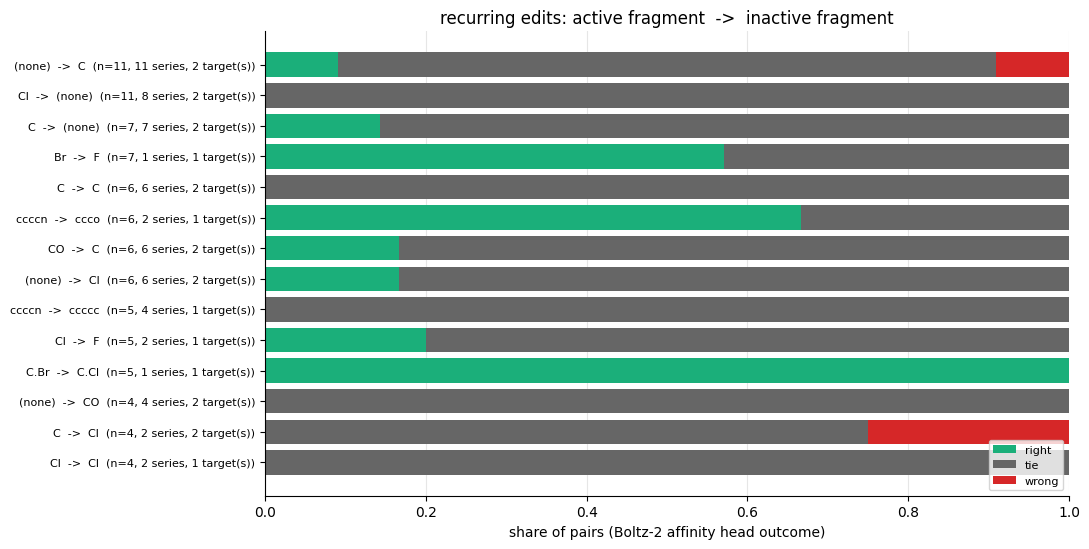

,n,right,wrong,tie,series,targets,dominant_share
edit,,,,,,,
(none) -> C,11,0.09,0.09,0.82,11,2,0.18
Cl -> (none),11,0.00,0.00,1.00,8,2,0.36
C -> (none),7,0.14,0.00,0.86,7,2,0.00
Br -> F,7,0.57,0.00,0.43,1,1,1.00
C -> C,6,0.00,0.00,1.00,6,2,0.17
ccccn -> ccco,6,0.67,0.00,0.33,2,1,0.83
CO -> C,6,0.17,0.00,0.83,6,2,0.17
(none) -> Cl,6,0.17,0.00,0.83,6,2,0.17
ccccn -> ccccc,5,0.00,0.00,1.00,4,1,0.40


In [38]:
Cx = CLIFF[CLIFF.mcs_ok == 1].copy(); Cx["edit"] = Cx.a_diff_smi.fillna("").replace("", "(none)") + "  ->  " + Cx.b_diff_smi.fillna("").replace("", "(none)")
g = Cx.groupby("edit"); tab = pd.DataFrame({"n": g.size(), "right": g.apply(lambda d: (d.o_b2 == "right").mean()), "wrong": g.apply(lambda d: (d.o_b2 == "wrong").mean()), "tie": g.apply(lambda d: (d.o_b2 == "tie").mean()),
                                            "series": g.series.nunique(), "targets": g.target.nunique(), "dominant_share": g.apply(lambda d: d.big.mean())})
tab = tab[tab.n >= 4].sort_values("n", ascending=False).head(14)
if len(tab):
    fig, ax = plt.subplots(figsize=(11, 5.6)); y = np.arange(len(tab))[::-1]; left = np.zeros(len(tab))
    for o in ["right", "tie", "wrong"]: ax.barh(y, tab[o], left=left, color=OC[o], label=o); left += tab[o].values
    ax.set_yticks(y); ax.set_yticklabels([f"{e}  (n={int(n)}, {int(s)} series, {int(tg)} target(s))" for e, n, s, tg in zip(tab.index, tab.n, tab.series, tab.targets)], fontsize=8)
    ax.set_xlabel("share of pairs (Boltz-2 affinity head outcome)"); ax.legend(fontsize=8, loc="lower right"); ax.set_title("recurring edits: active fragment  ->  inactive fragment"); plt.tight_layout(); plt.show(); display(tab.round(2))
else: print("no edit recurs at least 4 times")
KEY["edits"] = tab

share of right calls  \
subset                                              all cliffs   
edit property                                                    
fragment size differs by 3+ atoms                        0.315   
inactive is less lipophilic (>= 0.5 logP)                0.476   
inactive is lighter (>= 20 Da)                           0.554   
inactive is smaller (>= 1 heavy atom)                    0.482   
polar atoms / H-bond donors change                       0.304   
same molecular formula (regioisomer)                     0.042   
single-atom swap                                         0.077   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               0.413   
inactive is less lipophilic (>= 0.5 logP)                       0.413   
inactive is lighter (>= 20 Da)                                  0.427   
inactive is smaller (>= 1 heavy atom)                           0.533   
polar atoms / H-bond donors change                              0.520   
same molecular formula (regioisomer)                            0.027   
single-atom swap                                                0.067   

                                          share of tie calls  \
subset                                            all cliffs   
edit property                                                  
fragment size differs by 3+ atoms                      0.292   
inactive is less lipophilic (>= 0.5 logP)              0.367   
inactive is lighter (>= 20 Da)                         0.406   
inactive is smaller (>= 1 heavy atom)                  0.490   
polar atoms / H-bond donors change                     0.402   
same molecular formula (regioisomer)                   0.045   
single-atom swap                                       0.134   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               0.350   
inactive is less lipophilic (>= 0.5 logP)                       0.311   
inactive is lighter (>= 20 Da)                                  0.342   
inactive is smaller (>= 1 heavy atom)                           0.481   
polar atoms / H-bond donors change                              0.490   
same molecular formula (regioisomer)                            0.048   
single-atom swap                                                0.131   

                                          odds ratio  \
subset                                    all cliffs   
edit property                                          
fragment size differs by 3+ atoms              1.115   
inactive is less lipophilic (>= 0.5 logP)      1.569   
inactive is lighter (>= 20 Da)                 1.814   
inactive is smaller (>= 1 heavy atom)          0.970   
polar atoms / H-bond donors change             0.648   
same molecular formula (regioisomer)           0.929   
single-atom swap                               0.542   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               1.306   
inactive is less lipophilic (>= 0.5 logP)                       1.564   
inactive is lighter (>= 20 Da)                                  1.433   
inactive is smaller (>= 1 heavy atom)                           1.231   
polar atoms / H-bond donors change                              1.127   
same molecular formula (regioisomer)                            0.538   
single-atom swap                                            

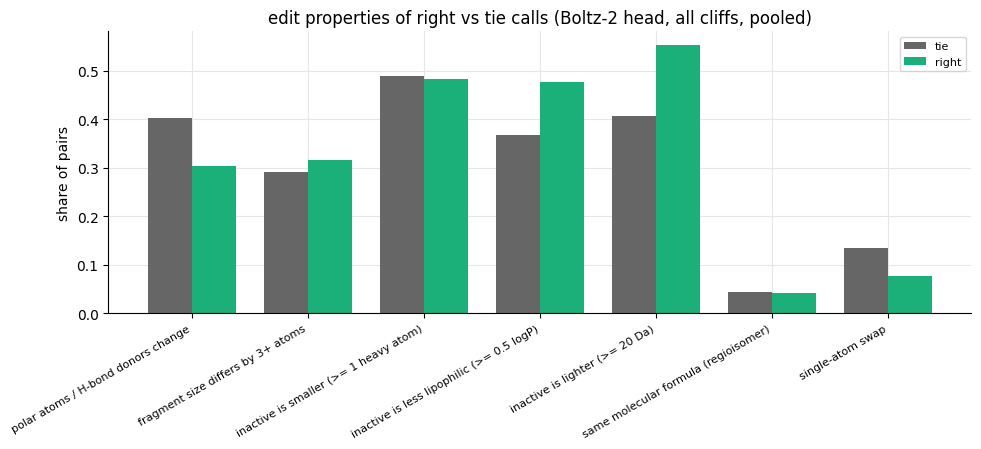

In [39]:
def flag_table2(df):
    f = pd.DataFrame(index=df.index)
    f["polar atoms / H-bond donors change"] = (df.a_diff_hbd != df.b_diff_hbd) | ((df.a_diff_has_N + df.a_diff_has_O) != (df.b_diff_has_N + df.b_diff_has_O))
    f["fragment size differs by 3+ atoms"] = (df.b_diff_n - df.a_diff_n).abs() >= 3; f["inactive is smaller (>= 1 heavy atom)"] = df.dp_heavy >= 1
    f["inactive is less lipophilic (>= 0.5 logP)"] = df.dp_logP >= 0.5; f["inactive is lighter (>= 20 Da)"] = df.dp_MW >= 20
    f["same molecular formula (regioisomer)"] = df.dp_MW.abs() < 0.01; f["single-atom swap"] = (df.a_diff_n <= 1) & (df.b_diff_n <= 1)
    return f
rows = []
for nm, d in [("all cliffs", Cx), ("without the dominant series", Cx[~Cx.big])]:
    F = flag_table2(d); r_ = d.o_b2 == "right"; t_ = d.o_b2 == "tie"
    for c in F.columns:
        a = int((F[c] & r_).sum()); b = int((~F[c] & r_).sum()); e = int((F[c] & t_).sum()); f_ = int((~F[c] & t_).sum())
        o, p = stats.fisher_exact([[a, b], [e, f_]]); rows.append((nm, c, F[c][r_].mean(), F[c][t_].mean(), o, p))
T7 = pd.DataFrame(rows, columns=["subset", "edit property", "share of right calls", "share of tie calls", "odds ratio", "Fisher p"])
display(T7.pivot(index="edit property", columns="subset", values=["share of right calls", "share of tie calls", "odds ratio", "Fisher p"]).round(3)); KEY["T7"] = T7
fig, ax = plt.subplots(figsize=(10, 4.6)); s7 = T7[T7.subset == "all cliffs"].set_index("edit property"); x = np.arange(len(s7))
ax.bar(x - 0.19, s7["share of tie calls"], 0.38, color=NEU, label="tie"); ax.bar(x + 0.19, s7["share of right calls"], 0.38, color=GRN, label="right")
ax.set_xticks(x); ax.set_xticklabels(s7.index, rotation=30, ha="right", fontsize=8); ax.set_ylabel("share of pairs"); ax.legend(fontsize=8); ax.set_title("edit properties of right vs tie calls (Boltz-2 head, all cliffs, pooled)"); plt.tight_layout(); plt.show()

## B8. Did the two poses differ in the correct calls?
Contact-set dissimilarity between the active's and the inactive's poses, by outcome.

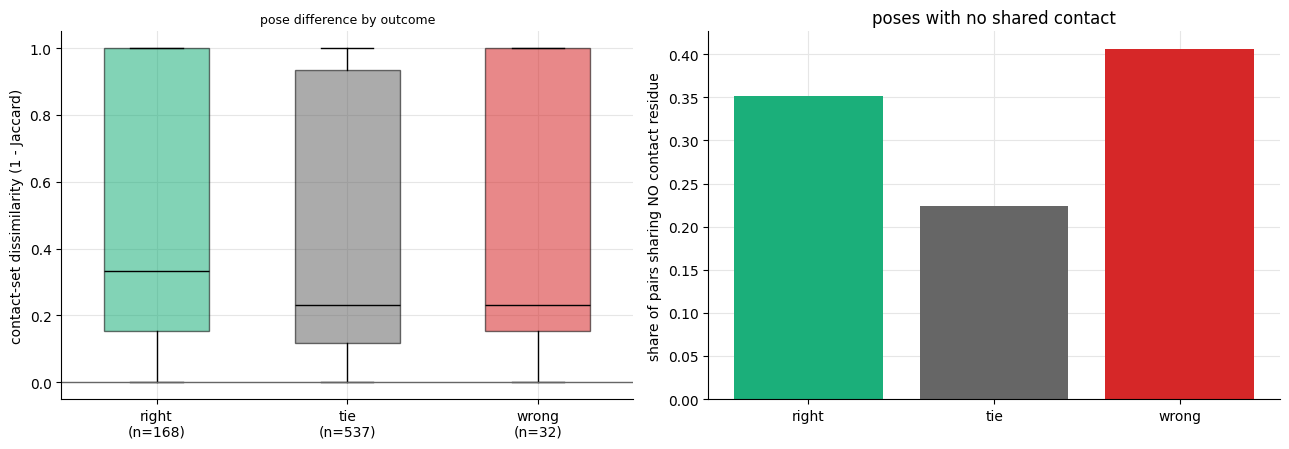

median contact dissimilarity by outcome: {'right': np.float64(0.33), 'tie': np.float64(0.23), 'wrong': np.float64(0.23)}
right vs tie Mann-Whitney p=0.00046 (pairs pooled)
without the dominant series: right n=75 median 0.33 | tie n=351 median 0.23 | p=0.13


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
boxes(axes[0], [CLIFF[CLIFF.o_b2 == g].pose_jdist.dropna() for g in grp], [f"{g}\n(n={int((CLIFF.o_b2 == g).sum())})" for g in grp], [OC[g] for g in grp], "contact-set dissimilarity (1 - Jaccard)", "pose difference by outcome")
sh = [(CLIFF[CLIFF.o_b2 == g].pose_jdist >= 0.99).mean() for g in grp]; axes[1].bar(range(3), sh, color=[OC[g] for g in grp]); axes[1].set_xticks(range(3)); axes[1].set_xticklabels(grp); axes[1].set_ylabel("share of pairs sharing NO contact residue"); axes[1].set_title("poses with no shared contact")
plt.tight_layout(); plt.show()
a = CLIFF[CLIFF.o_b2 == "right"].pose_jdist.dropna(); b = CLIFF[CLIFF.o_b2 == "tie"].pose_jdist.dropna(); KEY["B8"] = dict(med={g: CLIFF[CLIFF.o_b2 == g].pose_jdist.median() for g in grp})
KEY["B8"]["p"] = stats.mannwhitneyu(a, b).pvalue if len(a) > 2 else np.nan
print("median contact dissimilarity by outcome:", {g: round(v, 2) for g, v in KEY["B8"]["med"].items()}); print(f"right vs tie Mann-Whitney p={KEY['B8']['p']:.2g} (pairs pooled)")
d = CLIFF[~CLIFF.big]; a = d[d.o_b2 == "right"].pose_jdist.dropna(); b = d[d.o_b2 == "tie"].pose_jdist.dropna()
print(f"without the dominant series: right n={len(a)} median {a.median():.2f} | tie n={len(b)} median {b.median():.2f} | p={stats.mannwhitneyu(a, b).pvalue:.2g}" if len(a) > 3 else f"without the dominant series: only {len(a)} right calls")

### B8b. Are the correct calls recognising reactive or interference chemotypes?
If the head were picking up reactive or assay-interfering groups, right calls would be enriched in structural alerts (RDKit Brenk + PAINS catalogs).

,pairs,active has an alert,inactive partner has an alert
outcome,,,
right,168,0.21,0.17
tie,537,0.39,0.36
wrong,32,0.22,0.22


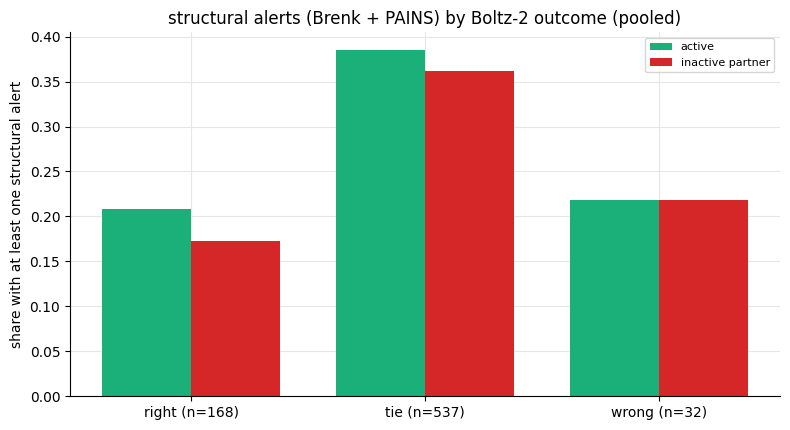

alerts carried by the actives of right calls: [('Oxygen-nitrogen_single_bond', 19), ('imine_1', 11), ('nitro_group', 10), ('Thiocarbonyl_group', 5), ('Aliphatic_long_chain', 5), ('Michael_acceptor_1', 2)]


In [41]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from collections import Counter
pr_ = FilterCatalogParams(); pr_.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK); pr_.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS); fcat = FilterCatalog(pr_)
def alerts(smi):
    m = Chem.MolFromSmiles(smi); return [e.GetDescription() for e in fcat.GetMatches(m)] if m else []
mem = pd.unique(np.concatenate([CLIFF.id_a, CLIFF.id_b])); AL = {i: alerts(Mi.smiles[i]) for i in mem}
CLIFF["alert_a"] = [len(AL[i]) > 0 for i in CLIFF.id_a]; CLIFF["alert_b"] = [len(AL[i]) > 0 for i in CLIFF.id_b]
rows = [(g, int((CLIFF.o_b2 == g).sum()), CLIFF[CLIFF.o_b2 == g].alert_a.mean(), CLIFF[CLIFF.o_b2 == g].alert_b.mean()) for g in grp]
T8 = pd.DataFrame(rows, columns=["outcome", "pairs", "active has an alert", "inactive partner has an alert"]).set_index("outcome"); display(T8.round(2)); KEY["T8"] = T8
fig, ax = plt.subplots(figsize=(8, 4.4)); x = np.arange(3); ax.bar(x - 0.19, T8["active has an alert"], 0.38, color=GRN, label="active"); ax.bar(x + 0.19, T8["inactive partner has an alert"], 0.38, color=CL, label="inactive partner")
ax.set_xticks(x); ax.set_xticklabels([f"{g} (n={int(T8.loc[g, 'pairs'])})" for g in grp]); ax.set_ylabel("share with at least one structural alert"); ax.legend(fontsize=8); ax.set_title("structural alerts (Brenk + PAINS) by Boltz-2 outcome (pooled)"); plt.tight_layout(); plt.show()
print("alerts carried by the actives of right calls:", Counter(a for i in CLIFF[CLIFF.o_b2 == "right"].id_a.unique() for a in AL[i]).most_common(6))

## B9. Where along the protein is the active closer than the inactive?
For every residue, the mean of (inactive's distance to the ligand minus active's distance), so a positive value means the active sits closer to that residue than its inactive partner. Shown per target for right calls and ties (targets with fewer than 3 right calls are marked).

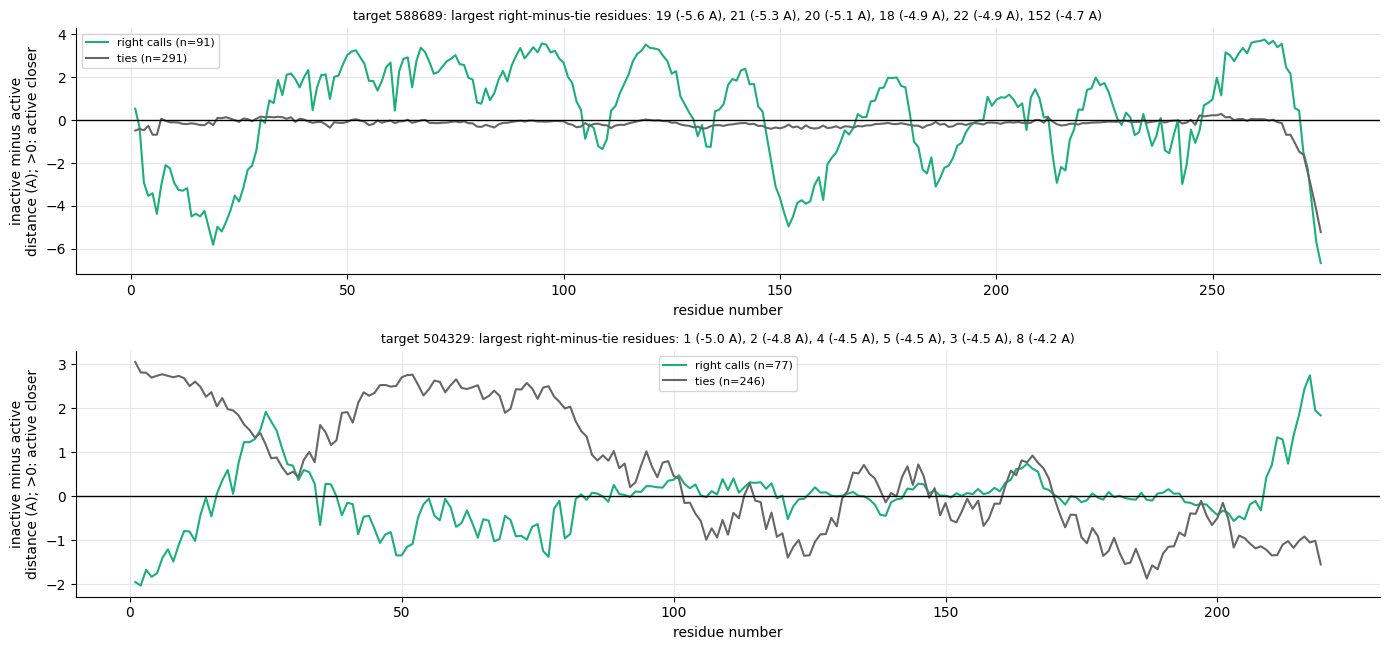

In [42]:
KEY["B9"] = {}; fig, axes = plt.subplots(NT, 1, figsize=(14, 3.3 * NT), squeeze=False)
for ax, t in zip(axes.ravel(), TL):
    C_ = CLIFF[CLIFF.target == t]; DEL = D[t]["mb"][C_.loc_i.values] - D[t]["ma"][C_.loc_i.values]; mr = (C_.o_b2 == "right").values; mt = (C_.o_b2 == "tie").values; rn = np.arange(1, DEL.shape[1] + 1)
    if mr.sum() < 3: ax.set_title(f"target {SH[t]}: only {int(mr.sum())} right calls, profile not drawn"); ax.axis("off"); continue
    pr = np.nanmean(DEL[mr], axis=0); pt = np.nanmean(DEL[mt], axis=0); ax.plot(rn, pr, color=GRN, label=f"right calls (n={int(mr.sum())})"); ax.plot(rn, pt, color=NEU, label=f"ties (n={int(mt.sum())})"); ax.axhline(0, color=BLK, lw=1)
    dd = pr - pt; top = np.argsort(-np.abs(dd))[:6]; ax.set_ylabel("inactive minus active\ndistance (A); >0: active closer"); ax.set_xlabel("residue number"); ax.legend(fontsize=8)
    ax.set_title(f"target {SH[t]}: largest right-minus-tie residues: " + ", ".join(f"{i+1} ({dd[i]:+.1f} A)" for i in top), fontsize=9); KEY["B9"][t] = (pr, pt)
plt.tight_layout(); plt.show()

### B9b. Are correct calls a change of binding site?
Each member's contact profile was clustered into two sites (k-means per target); site 0 is the majority site of that target. For each outcome, how often do the active and the inactive sit in different sites?

combo,both majority site,both second site,"active majority, inactive second","active second, inactive majority"
o_b2,,,,
right,125,18,11,14
tie,421,31,36,49
wrong,25,0,2,5


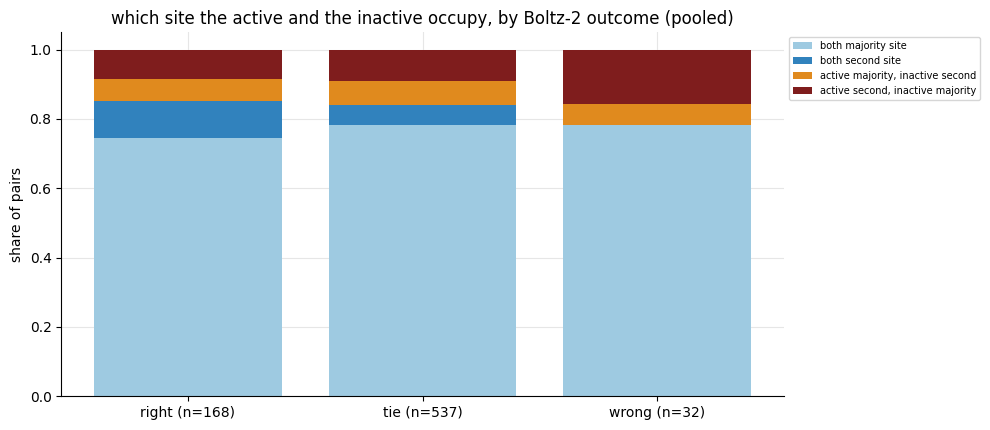

share of pairs whose two members sit in different sites: {'right': np.float64(0.15), 'tie': np.float64(0.16), 'wrong': np.float64(0.22)}
right vs tie, site switch: odds ratio 0.93, Fisher p=0.81 (pairs pooled)


In [43]:
CLIFF["combo"] = CLIFF.site_a.astype(str) + "->" + CLIFF.site_b.astype(str); names = {"0->0": "both majority site", "1->1": "both second site", "0->1": "active majority, inactive second", "1->0": "active second, inactive majority"}
ct = pd.crosstab(CLIFF.o_b2, CLIFF.combo).reindex(index=grp).reindex(columns=list(names), fill_value=0); display(ct.rename(columns=names))
fr = ct.div(ct.sum(1), axis=0).fillna(0); fig, ax = plt.subplots(figsize=(10, 4.4)); bottom = np.zeros(3)
for c, col in zip(names, ["#9ecae1", "#3182bd", ORG, "#7f1d1d"]): ax.bar(range(3), fr[c], bottom=bottom, color=col, label=names[c]); bottom += fr[c].values
ax.set_xticks(range(3)); ax.set_xticklabels([f"{g} (n={int(ct.loc[g].sum())})" for g in grp]); ax.set_ylabel("share of pairs"); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0)); ax.set_title("which site the active and the inactive occupy, by Boltz-2 outcome (pooled)")
plt.tight_layout(); plt.show()
swf = lambda g: CLIFF[CLIFF.o_b2 == g].combo.isin(["0->1", "1->0"]).mean(); KEY["B9b"] = {g: swf(g) for g in grp}; print("share of pairs whose two members sit in different sites:", {g: round(v, 2) for g, v in KEY["B9b"].items()})
r_ = CLIFF[CLIFF.o_b2 == "right"]; t_ = CLIFF[CLIFF.o_b2 == "tie"]; a = int(r_.combo.isin(["0->1", "1->0"]).sum()); b = len(r_) - a; c_ = int(t_.combo.isin(["0->1", "1->0"]).sum()); d_ = len(t_) - c_
KEY["B9b_p"] = stats.fisher_exact([[a, b], [c_, d_]])[1]; print("right vs tie, site switch: odds ratio %.2f, Fisher p=%.2g (pairs pooled)" % (stats.fisher_exact([[a, b], [c_, d_]])[0], KEY["B9b_p"]))

## B10. The same profile on the protein itself
For each target that has a folded-pose CA trace (results/runs/<t>/pose_density/ca_colored.npz of matching length), the backbone drawn as a tube and coloured by the per-residue closeness of B9: warm where the active sits closer than its inactive partner, cool where farther. Left: right calls, right: ties, one shared scale. Means are heavy-tailed, so B9 is the quantitative view.

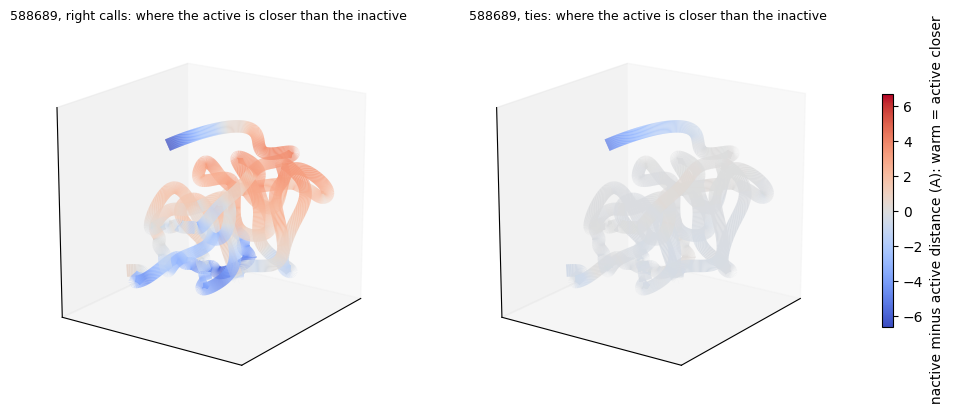

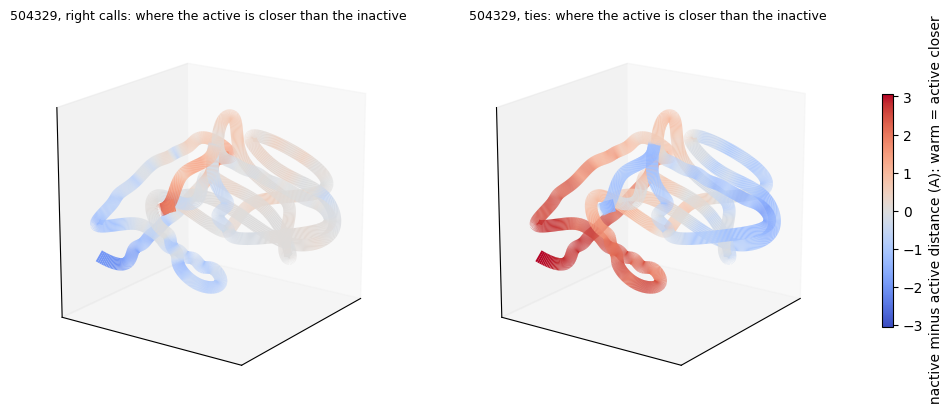

In [44]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.interpolate import splprep, splev
def ribbon(ax, ca, val, vmin, vmax):
    n = len(ca); tck, u = splprep([ca[:, 0], ca[:, 1], ca[:, 2]], s=n * 3.0, k=3); uu = np.linspace(0, 1, n * 14); pts = np.array(splev(uu, tck)).T; di = np.interp(uu, np.linspace(0, 1, n), val)
    lc = Line3DCollection(np.stack([pts[:-1], pts[1:]], axis=1), cmap="coolwarm", linewidths=9, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)); lc.set_array(di[:-1]); ax.add_collection3d(lc)
    mn_, mx_ = pts.min(0), pts.max(0); c = (mn_ + mx_) / 2; rad = (mx_ - mn_).max() / 2 * 1.05
    ax.set_xlim(c[0] - rad, c[0] + rad); ax.set_ylim(c[1] - rad, c[1] + rad); ax.set_zlim(c[2] - rad, c[2] + rad); ax.set_box_aspect((1, 1, 1)); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([]); ax.grid(False); ax.view_init(elev=18, azim=35)
    return lc
for t in TL:
    f = bc.RUNS / t / "pose_density/ca_colored.npz"
    if t not in KEY["B9"]: print(f"pending: {SH[t]}: no B9 profile (too few right calls)"); continue
    if not f.exists(): print(f"pending: {SH[t]}: {f} missing"); continue
    try:
        ca = np.load(f, allow_pickle=True)["ca"]; pr, pt = KEY["B9"][t]
        if len(ca) != len(pr): print(f"pending: {SH[t]}: CA trace has {len(ca)} residues, pose profile {len(pr)}"); continue
        lim = float(np.nanmax(np.abs(np.concatenate([pr, pt])))); fig = plt.figure(figsize=(13, 5.5))
        for k, (val, tt) in enumerate([(pr, "right calls"), (pt, "ties")]):
            ax = fig.add_subplot(1, 2, k + 1, projection="3d"); lc = ribbon(ax, ca, val, -lim, lim); ax.set_title(f"{SH[t]}, {tt}: where the active is closer than the inactive", fontsize=9)
        fig.colorbar(lc, ax=fig.axes, shrink=0.55, label="inactive minus active distance (A): warm = active closer"); plt.show()
    except Exception as e: print(f"{SH[t]}: ribbon failed: {type(e).__name__}: {e}")

## B11. Confidence in the correct calls
Boltz-2 confidence differences between the active and its inactive partner, split by outcome (pooled).

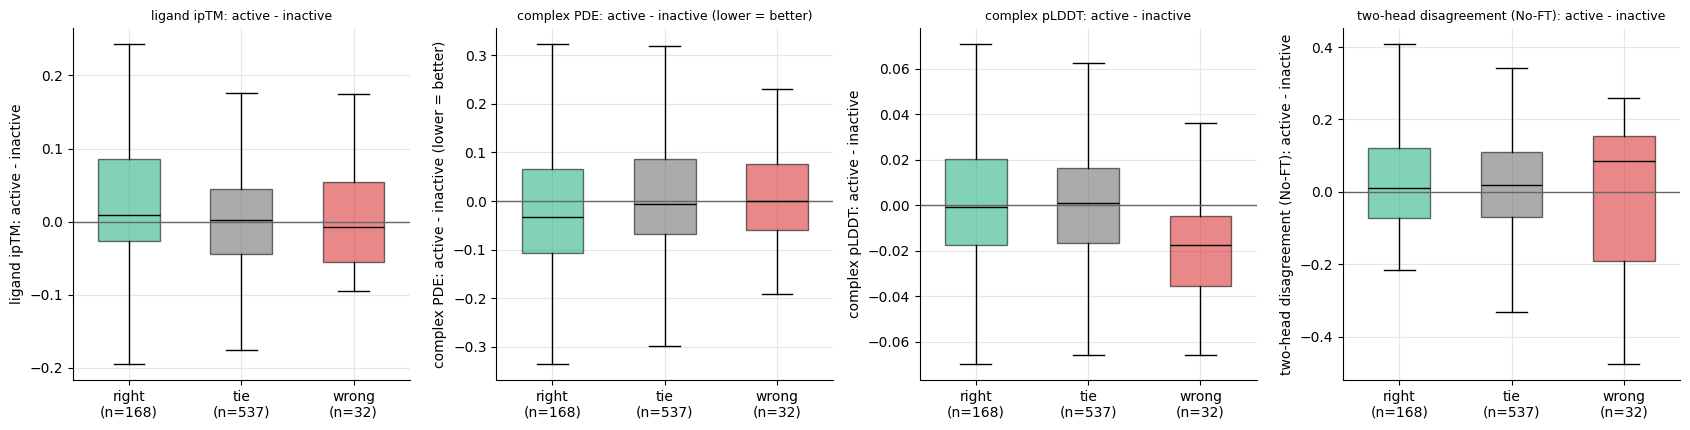

,median (right),median (tie),median (wrong),right vs tie p (all),right calls outside dominant series,right vs tie p (outside)
signal,,,,,,
ligand ipTM: active - inactive,0.0088,0.0030,-0.0079,0.0019,75,0.4384
complex PDE: active - inactive (lower = better),-0.0330,-0.0061,0.0002,0.0123,75,0.6893
complex pLDDT: active - inactive,-0.0007,0.0010,-0.0175,0.9021,75,0.3900
two-head disagreement (No-FT): active - inactive,0.0109,0.0183,0.0843,0.7532,75,0.0012


In [45]:
cf = [("c_ligand_iptm", "ligand ipTM: active - inactive"), ("c_complex_pde", "complex PDE: active - inactive (lower = better)"), ("c_complex_plddt", "complex pLDDT: active - inactive"), ("c_disagree_noft", "two-head disagreement (No-FT): active - inactive")]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4)); rows = []
for ax, (c, l) in zip(axes, cf):
    boxes(ax, [CLIFF[CLIFF.o_b2 == g][c].dropna() for g in grp], [f"{g}\n(n={int((CLIFF.o_b2 == g).sum())})" for g in grp], [OC[g] for g in grp], l, l)
    a = CLIFF[CLIFF.o_b2 == "right"][c].dropna(); b = CLIFF[CLIFF.o_b2 == "tie"][c].dropna(); a2 = CLIFF[(CLIFF.o_b2 == "right") & (~CLIFF.big)][c].dropna(); b2 = CLIFF[(CLIFF.o_b2 == "tie") & (~CLIFF.big)][c].dropna()
    rows.append((l, a.median(), b.median(), CLIFF[CLIFF.o_b2 == "wrong"][c].median(), stats.mannwhitneyu(a, b).pvalue if len(a) > 2 else np.nan, len(a2), stats.mannwhitneyu(a2, b2).pvalue if len(a2) > 3 else np.nan))
plt.tight_layout(); plt.show()
B11 = pd.DataFrame(rows, columns=["signal", "median (right)", "median (tie)", "median (wrong)", "right vs tie p (all)", "right calls outside dominant series", "right vs tie p (outside)"]).set_index("signal"); display(B11.round(4)); KEY["B11"] = B11

## B12. When a model makes a big call, how much should you trust it?
Selective accuracy. Rank pairs by the *size* of each signal's difference, keep the top fraction, and measure how often the sign is right. The size and lipophilicity baselines are ranked the same way. The far left of each curve rests on few pairs.

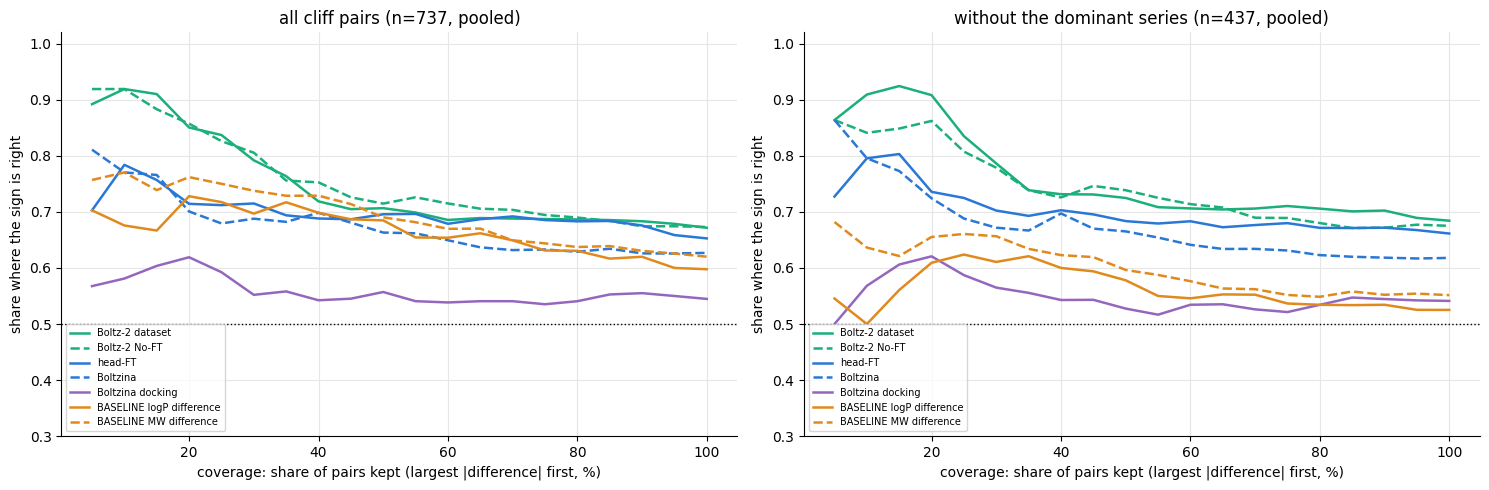

In [46]:
def sel_curve(d, col, fr=np.linspace(0.05, 1.0, 20)):
    x = d[col].dropna().values; s = np.sign(x)[np.argsort(-np.abs(x))]; out = []
    for f in fr:
        k = max(1, int(round(f * len(s)))); t = s[:k]; out.append(((t > 0).sum() + 0.5 * (t == 0).sum()) / k)
    return fr, np.array(out)
SIG = [("d_score_boltz2", "Boltz-2 dataset", GRN, "-"), ("d_base_noft", "Boltz-2 No-FT", GRN, "--"), ("d_ft300", "head-FT", CO, "-"), ("d_score_boltzina", "Boltzina", CO, "--"), ("d_docking_score_boltzina", "Boltzina docking", "#9467bd", "-"),
       ("dp_logP", "BASELINE logP difference", ORG, "-"), ("dp_MW", "BASELINE MW difference", ORG, "--")]
fig, axes = plt.subplots(1, 2, figsize=(15, 5)); KEY["B12"] = {}
for ax, (nm, d) in zip(axes, [("all cliff pairs", CLIFF), ("without the dominant series", CLIFF[~CLIFF.big])]):
    for col, l, c, ls in SIG:
        fr, a = sel_curve(d, col); ax.plot(100 * fr, a, color=c, ls=ls, label=l, lw=1.8); KEY["B12"][(nm, col)] = (a[0], a[1], a[-1])
    ax.axhline(0.5, color=BLK, lw=1, ls=":"); ax.set_xlabel("coverage: share of pairs kept (largest |difference| first, %)"); ax.set_ylabel("share where the sign is right"); ax.set_ylim(0.3, 1.02); ax.set_title(f"{nm} (n={len(d)}, pooled)"); ax.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

## B13. Are the correct calls the cleaner cliffs?
The inactive partner's primary-screen Z-score percentile among that target's inactives, by outcome (within-target percentile so assays are comparable). Per pair, so partners can repeat.

all cliffs: median partner Z percentile right 0.89 (n=168) | tie 0.84 | wrong 0.95 (n=32) | right vs wrong p=0.33
without the dominant series: median partner Z percentile right 0.63 (n=75) | tie 0.80 | wrong 0.93 (n=11) | right vs wrong p=0.061


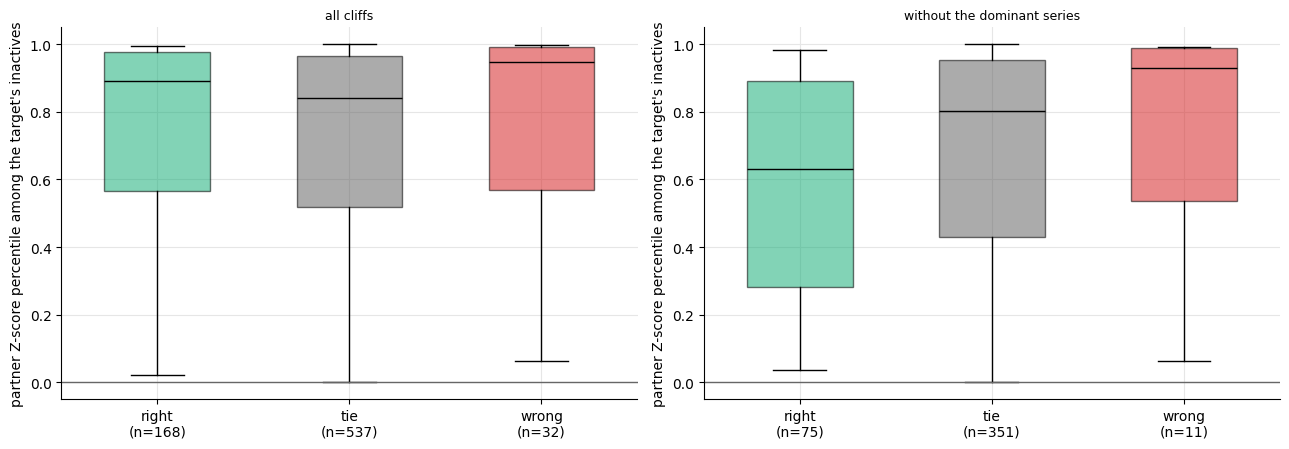

In [47]:
CLIFF["partner_zpct"] = [ (D[t]["zinfo"]["ina"] < z).mean() if np.isfinite(z) else np.nan for t, z in zip(CLIFF.target, CLIFF.partner_z)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6)); KEY["B13"] = {}
for ax, (nm, d) in zip(axes, [("all cliffs", CLIFF), ("without the dominant series", CLIFF[~CLIFF.big])]):
    gs = [d[d.o_b2 == g].partner_zpct.dropna() for g in grp]; boxes(ax, gs, [f"{g}\n(n={len(x)})" for g, x in zip(grp, gs)], [OC[g] for g in grp], "partner Z-score percentile among the target's inactives", nm)
    a = gs[0]; b = gs[2]; KEY["B13"][nm] = (a.median(), gs[1].median(), b.median(), stats.mannwhitneyu(a, b).pvalue if len(a) > 3 and len(b) > 3 else np.nan)
    print(f"{nm}: median partner Z percentile right {a.median():.2f} (n={len(a)}) | tie {gs[1].median():.2f} | wrong {b.median():.2f} (n={len(b)})" + (f" | right vs wrong p={KEY['B13'][nm][3]:.2g}" if len(a) > 3 and len(b) > 3 else ""))
plt.tight_layout(); plt.show()

## B14. If the Boltz-2 head is right, are the other methods?
Conditional detection: for pairs the head calls right, ties on, or gets wrong, the share where each other signal ranks the active higher.

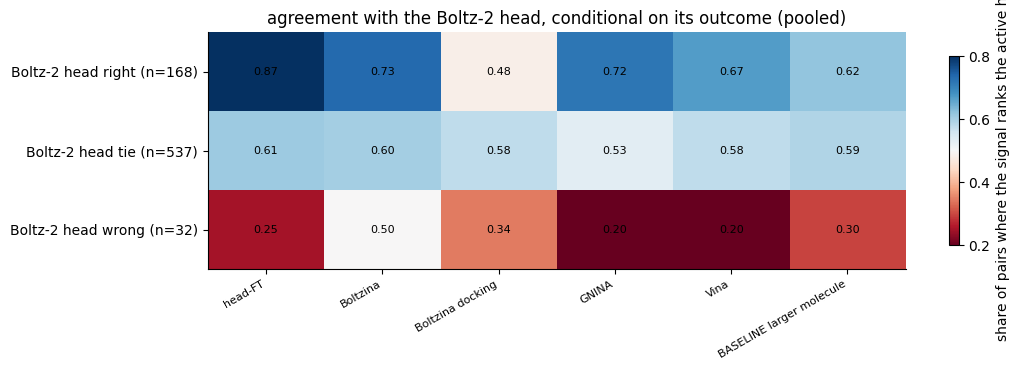

In [48]:
cols = [("ft300", "head-FT"), ("score_boltzina", "Boltzina"), ("docking_score_boltzina", "Boltzina docking"), ("score_gnina", "GNINA"), ("score_vina", "Vina")]
mat = np.array([[bcl.rate(CLIFF[CLIFF.o_b2 == g]["d_" + m]) for m, _ in cols] + [bcl.rate(CLIFF[CLIFF.o_b2 == g].dp_heavy)] for g in grp], float); names = [l for _, l in cols] + ["BASELINE larger molecule"]
fig, ax = plt.subplots(figsize=(11, 3.8)); im = ax.imshow(mat, cmap="RdBu", vmin=0.2, vmax=0.8, aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8); ax.set_yticks(range(3)); ax.set_yticklabels([f"Boltz-2 head {g} (n={int((CLIFF.o_b2 == g).sum())})" for g in grp])
for i in range(3):
    for j in range(len(names)):
        if np.isfinite(mat[i, j]): ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="share of pairs where the signal ranks the active higher"); ax.set_title("agreement with the Boltz-2 head, conditional on its outcome (pooled)"); plt.tight_layout(); plt.show()

## B15. Which chemical series carry the correct calls?
Right calls per series (across all targets), and the scaffold of the biggest series. A pattern that lives in one series is a statement about that series.

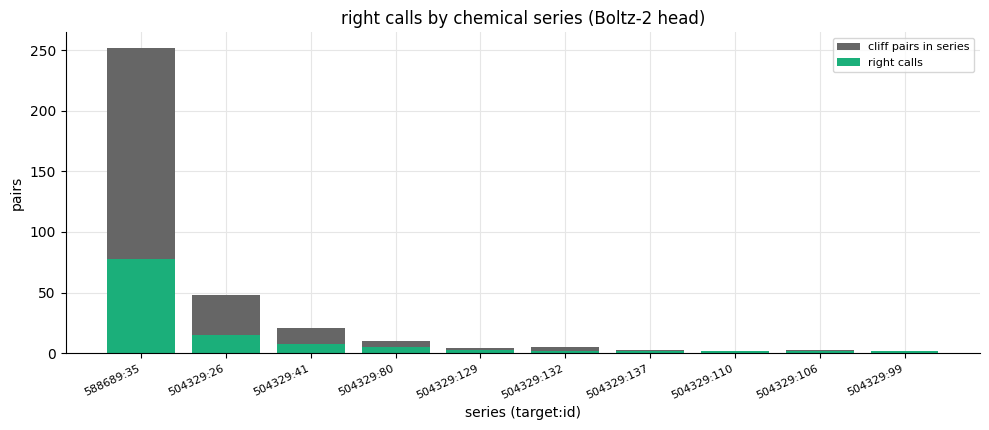

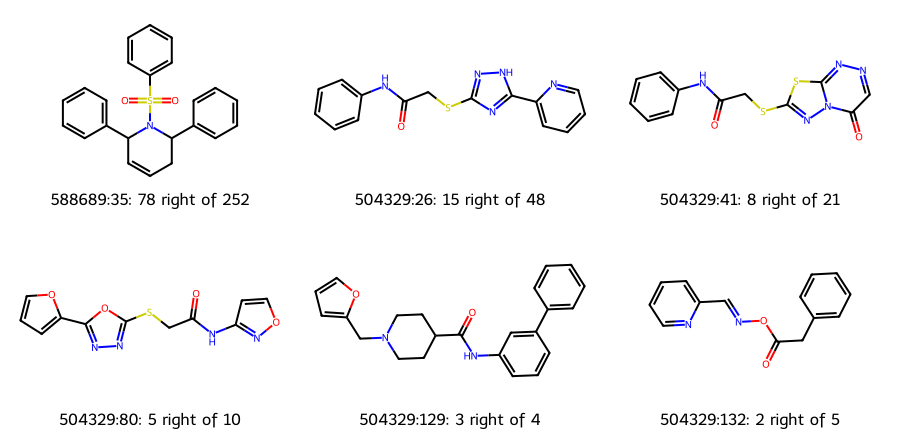

right calls: 168; distinct actives 85; distinct series 55; share in the dominant series of their target 55%


In [49]:
R = CLIFF[CLIFF.o_b2 == "right"]; sc = CLIFF.groupby("series").size(); rc = R.groupby("series").size().reindex(sc.index).fillna(0)
tb = pd.DataFrame({"cliffs": sc, "right": rc}).sort_values("right", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 4.4)); x = np.arange(len(tb)); ax.bar(x, tb.cliffs, color=NEU, label="cliff pairs in series"); ax.bar(x, tb.right, color=GRN, label="right calls")
ax.set_xticks(x); ax.set_xticklabels([f"{SH[s.split(':')[0]]}:{s.split(':')[1]}" for s in tb.index], rotation=25, ha="right", fontsize=8); ax.set_xlabel("series (target:id)"); ax.set_ylabel("pairs"); ax.legend(fontsize=8); ax.set_title("right calls by chemical series (Boltz-2 head)"); plt.tight_layout(); plt.show()
from rdkit.Chem.Scaffolds import MurckoScaffold
mols = []; leg = []
for s_ in tb.index[:6]:
    smi = CLIFF[CLIFF.series == s_].smiles_a.iloc[0]; mols.append(Chem.MolFromSmiles(MurckoScaffold.MurckoScaffoldSmiles(smiles=smi)) or Chem.MolFromSmiles(smi)); leg.append(f"{SH[s_.split(':')[0]]}:{s_.split(':')[1]}: {int(tb.loc[s_, 'right'])} right of {int(tb.loc[s_, 'cliffs'])}")
display(Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 220), legends=leg, returnPNG=False))
print(f"right calls: {len(R)}; distinct actives {R.id_a.nunique()}; distinct series {R.series.nunique()}; share in the dominant series of their target {100*R.big.mean():.0f}%")

# Part C · Is head-FT better than No-FT on near-identical pairs?

Ground truth is the **binary label only**: positives are cliff pairs (label flips between near-identical molecules = a true large delta), negatives are conserved pairs (both active = true absence of a large delta; orientation random). For each model the delta is the score of the active minus the score of its inactive partner. Each model's own notion of 'large' is **calibrated on the conserved pairs** (its noise floor: the 90th or 95th percentile of |delta| among conserved pairs), so a model that spreads its scores more widely is not rewarded for it, and the answer does not hinge on a score scale. **Sensitivity** = share of true cliffs whose delta clears that bar in the right direction. Also reported: pairwise accuracy on cliffs, AUROC of |delta| and of the signed delta (cliff vs conserved). Everything is on two scales (percentile rank and log-odds). Metrics are computed per target and macro-averaged; **intervals resample series within each target** (600 bootstrap draws), paired across the two models. A target enters only if it has at least 5 cliff and 5 conserved pairs in the partition. 'Head-FT' is the 5-seed mean score at N=300.

,n_targets,n_cliff,n_conserved,n_series
subset,,,,
all pairs,2,737,530,236
without the dominant series,2,437,385,234
dominant series only,2,300,145,2


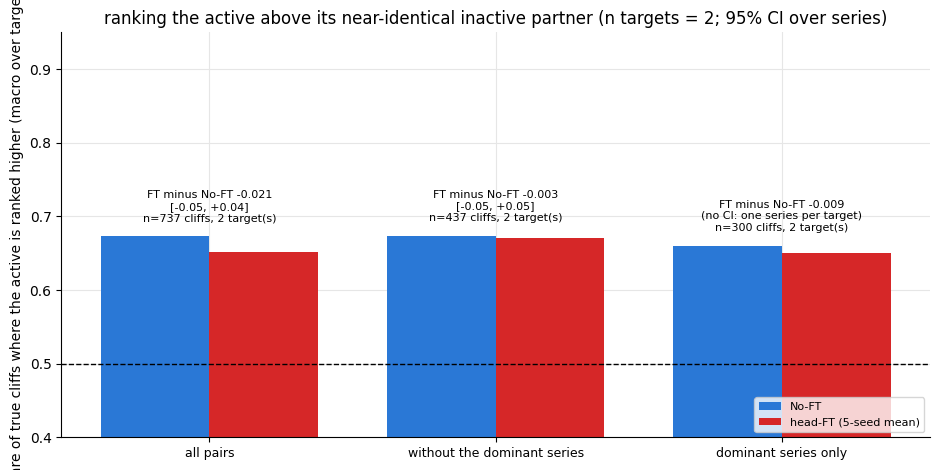

In [50]:
CAL, PT = bcl.ft_vs_noft(P, B=600)
if len(CAL) == 0: print("no target has enough pairs")
nn = CAL.drop_duplicates("subset")[["subset", "n_targets", "n_cliff", "n_conserved", "n_series"]].set_index("subset"); display(nn)
pw = CAL[(CAL.metric == "pairwise_acc") & (CAL.scale == "percentile")].set_index("subset"); pw = pw.reindex([s for s in ["all pairs", "without the dominant series", "dominant series only"] if s in pw.index])
fig, ax = plt.subplots(figsize=(9.5, 4.8)); x = np.arange(len(pw)); ax.bar(x - 0.19, pw.noft, 0.38, color=CO, label="No-FT"); ax.bar(x + 0.19, pw.ft, 0.38, color=CL, label="head-FT (5-seed mean)")
for i, (s_, r) in enumerate(pw.iterrows()):
    ci = f"[{r.lo:+.2f}, {r.hi:+.2f}]" if np.isfinite(r.lo) else "(no CI: one series per target)"
    ax.text(i, max(r.noft, r.ft) + 0.02, f"FT minus No-FT {r['diff']:+.3f}\n{ci}\nn={int(r.n_cliff)} cliffs, {int(r.n_targets)} target(s)", ha="center", fontsize=8)
ax.axhline(0.5, color=BLK, ls="--", lw=1); ax.set_xticks(x); ax.set_xticklabels(pw.index, fontsize=9); ax.set_ylim(0.4, 0.95); ax.set_ylabel("share of true cliffs where the active is ranked higher (macro over targets)"); ax.legend(fontsize=8, loc="lower right")
ax.set_title(f"ranking the active above its near-identical inactive partner (n targets = {NT}; 95% CI over series)"); plt.tight_layout(); plt.show(); KEY["CAL"] = CAL

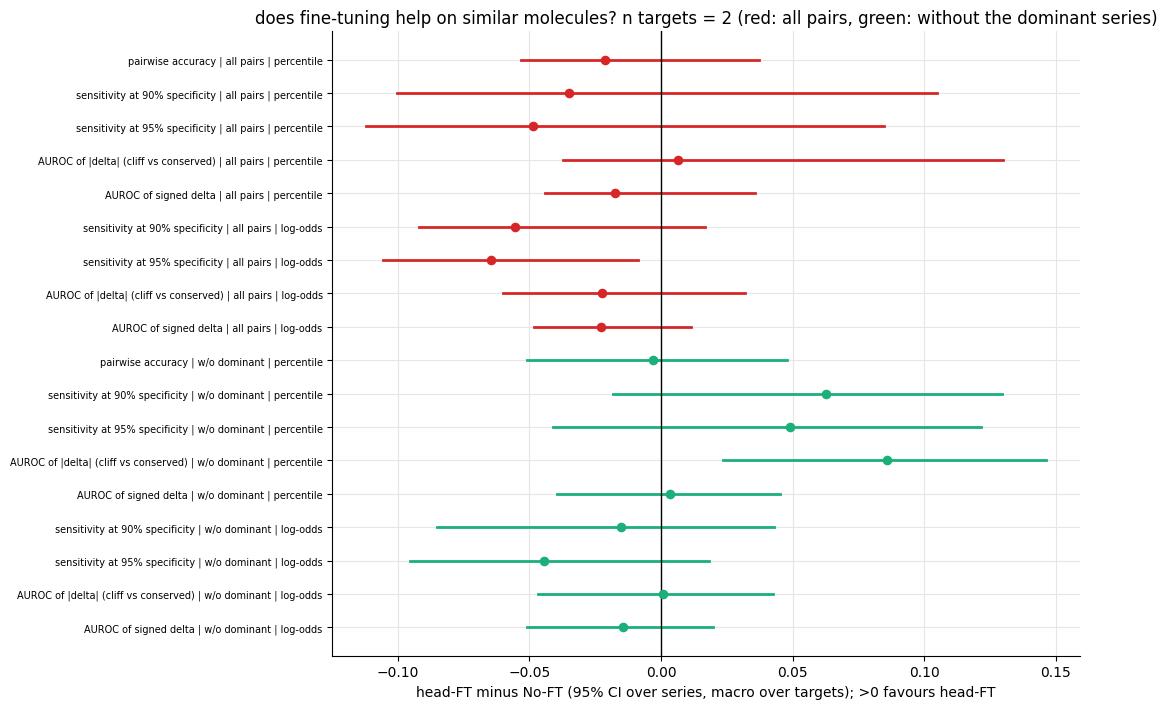

18 comparisons; 2 have an interval that excludes zero; at 5% about 0.9 would be expected by chance alone, and the Bonferroni level would be 0.0028 per comparison (these intervals are at the nominal 5% level):


,noft,ft,diff,lo,hi
label,,,,,
AUROC of |delta| (cliff vs conserved) | w/o dominant | percentile,0.642,0.728,0.086,0.024,0.146
sensitivity at 95% specificity | all pairs | log-odds,0.143,0.078,-0.065,-0.106,-0.009


In [51]:
F = CAL[CAL.subset.isin(["all pairs", "without the dominant series"]) & CAL.metric.isin(["pairwise_acc", "sens@90", "sens@95", "auc_abs", "auc_signed"]) & ~((CAL.metric == "pairwise_acc") & (CAL.scale == "log-odds"))].copy()
NMM = {"pairwise_acc": "pairwise accuracy", "sens@90": "sensitivity at 90% specificity", "sens@95": "sensitivity at 95% specificity", "auc_abs": "AUROC of |delta| (cliff vs conserved)", "auc_signed": "AUROC of signed delta"}
F["label"] = F.metric.map(NMM) + " | " + F.subset.str.replace("without the dominant series", "w/o dominant") + " | " + F.scale
F = F.iloc[::-1].reset_index(drop=True); fig, ax = plt.subplots(figsize=(11, 7.2))
for i, r in F.iterrows():
    c = CL if r.subset == "all pairs" else GRN; ax.plot([r.lo, r.hi], [i, i], color=c, lw=2); ax.scatter(r["diff"], i, color=c, s=35, zorder=3)
ax.axvline(0, color=BLK, lw=1); ax.set_yticks(range(len(F))); ax.set_yticklabels(F.label, fontsize=7); ax.set_xlabel("head-FT minus No-FT (95% CI over series, macro over targets); >0 favours head-FT")
ax.set_title(f"does fine-tuning help on similar molecules? n targets = {NT} (red: all pairs, green: without the dominant series)"); plt.tight_layout(); plt.show()
NCMP = len(F); sig = F[(F.lo > 0) | (F.hi < 0)]; KEY["NCMP"] = NCMP; KEY["nsig"] = len(sig)
print(f"{NCMP} comparisons; {len(sig)} have an interval that excludes zero; at 5% about {0.05*NCMP:.1f} would be expected by chance alone, and the Bonferroni level would be {0.05/NCMP:.4f} per comparison (these intervals are at the nominal 5% level):")
display(sig[["label", "noft", "ft", "diff", "lo", "hi"]].round(3).set_index("label"))

**Per target.** The same metrics for each target separately (all pairs, no CI: with a handful of targets the per-target point estimates matter more than one pooled number; the intervals above are the uncertainty statement).

In [52]:
pt = PT[PT.scale == "percentile"].copy(); pt["target"] = pt.target.map(SH)
cols_ = ["target"] + [f"{m}_{k}" for k in ["pairwise_acc", "sens@90", "auc_abs"] for m in ["noft", "ft"]]; display(pt[cols_].set_index("target").round(3))
ptl = PT[PT.scale == "log-odds"].copy(); ptl["target"] = ptl.target.map(SH); print("log-odds scale:"); display(ptl[cols_].set_index("target").round(3)); KEY["PT"] = PT

,noft_pairwise_acc,ft_pairwise_acc,noft_sens@90,ft_sens@90,noft_auc_abs,ft_auc_abs
target,,,,,,
504329,0.674,0.644,0.239,0.245,0.669,0.740
588689,0.672,0.660,0.212,0.135,0.678,0.621


log-odds scale:


,noft_pairwise_acc,ft_pairwise_acc,noft_sens@90,ft_sens@90,noft_auc_abs,ft_auc_abs
target,,,,,,
504329,0.674,0.644,0.221,0.151,0.615,0.595
588689,0.672,0.660,0.167,0.126,0.608,0.583


**Threshold sensitivity.** The 'large delta' bar is a specificity level on conserved pairs (90% / 95% above). Here it is varied from 80% to 99% so the conclusion does not hinge on it: sensitivity of each model, and head-FT minus No-FT with an interval over series.

sensitivity No-FT  \
scale      specificity on conserved pairs                      
percentile 80%                                         0.318   
           90%                                         0.225   
           95%                                         0.185   
           99%                                         0.094   
log-odds   80%                                         0.256   
           90%                                         0.194   
           95%                                         0.143   
           99%                                         0.082   

                                           sensitivity head-FT  \
scale      specificity on conserved pairs                        
percentile 80%                                           0.265   
           90%                                           0.190   
           95%                                           0.136   
           99%                                           0.039   
log-odds   80%                                           0.235   
           90%                                           0.138   
           95%                                           0.078   
           99%                                           0.038   

                                           head-FT minus No-FT     lo     hi  
scale      specificity on conserved pairs                                     
percentile 80%                                          -0.053 -0.110  0.110  
           90%                                          -0.035 -0.101  0.099  
           95%                                          -0.049 -0.110  0.082  
           99%                                          -0.055 -0.103  0.047  
log-odds   80%                                          -0.021 -0.061  0.046  
           90%                                          -0.056 -0.090  0.017  
           95%                                          -0.065 -0.104 -0.010  
           99%                                          -0.043 -0.080  0.015

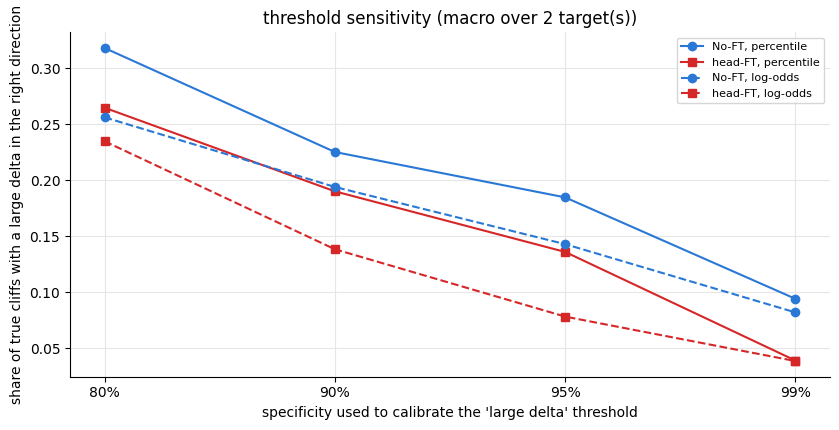

In [53]:
SPECS = [0.80, 0.90, 0.95, 0.99]
def sens_at(d, col, sp):
    c = d.loc[d.kind == "cliff", col].values; k = d.loc[d.kind == "conserved", col].values; tau = np.quantile(np.abs(k), sp); return np.mean(c > tau)
rows = []; B_ = 300
ok_t = [t for t in TL if (CLIFF.target == t).sum() >= 5 and (CTRL.target == t).sum() >= 5]
for sc in ("percentile", "log-odds"):
    for sp in SPECS:
        pt_ = {m: np.mean([sens_at(P[P.target == t], bcl._col(m, sc), sp) for t in ok_t]) if ok_t else np.nan for m in bcl.MODELS2}; bsd = []
        if ok_t:
            for t in ok_t:
                d = P[P.target == t].reset_index(drop=True); grp_ = list(d.groupby("series").indices.values()); rng = np.random.default_rng(0); r_ = []
                for _ in range(B_):
                    dd = d.iloc[np.concatenate([grp_[i] for i in rng.integers(0, len(grp_), len(grp_))])]
                    r_.append(np.nan if (dd.kind == "cliff").sum() < 5 or (dd.kind == "conserved").sum() < 5 else sens_at(dd, bcl._col("head-FT", sc), sp) - sens_at(dd, bcl._col("No-FT", sc), sp))
                bsd.append(r_)
            bsd = np.nanmean(np.array(bsd, float), axis=0); lo, hi = np.nanpercentile(bsd, [2.5, 97.5])
        else: lo = hi = np.nan
        rows.append((sc, f"{int(100*sp)}%", pt_["No-FT"], pt_["head-FT"], pt_["head-FT"] - pt_["No-FT"], lo, hi))
SENS = pd.DataFrame(rows, columns=["scale", "specificity on conserved pairs", "sensitivity No-FT", "sensitivity head-FT", "head-FT minus No-FT", "lo", "hi"]).set_index(["scale", "specificity on conserved pairs"]); display(SENS.round(3)); KEY["SENS"] = SENS
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for sc, ls in [("percentile", "-"), ("log-odds", "--")]:
    s = SENS.loc[sc]; ax.plot(range(len(s)), s["sensitivity No-FT"], color=CO, ls=ls, marker="o", label=f"No-FT, {sc}"); ax.plot(range(len(s)), s["sensitivity head-FT"], color=CL, ls=ls, marker="s", label=f"head-FT, {sc}")
ax.set_xticks(range(len(SPECS))); ax.set_xticklabels([f"{int(100*s)}%" for s in SPECS]); ax.set_xlabel("specificity used to calibrate the 'large delta' threshold"); ax.set_ylabel("share of true cliffs with a large delta in the right direction"); ax.legend(fontsize=8); ax.set_title(f"threshold sensitivity (macro over {len(ok_t)} target(s))"); plt.tight_layout(); plt.show()

### Agreement of the five fine-tuning seeds on pairs
Each seed is an independent fine-tune with the same 300 labels. For each pair, how many of the five seeds rank the active above the inactive? Unanimity means the seeds agree, not that they are right. Shares are macro-averaged over targets.

,cliffs,unanimous_right,unanimous_wrong,split,ensemble_right_when_split,controls_unanimous_either_way
target,,,,,,
588689,406,0.574,0.268,0.158,0.531,0.822
504329,331,0.514,0.275,0.211,0.614,0.796


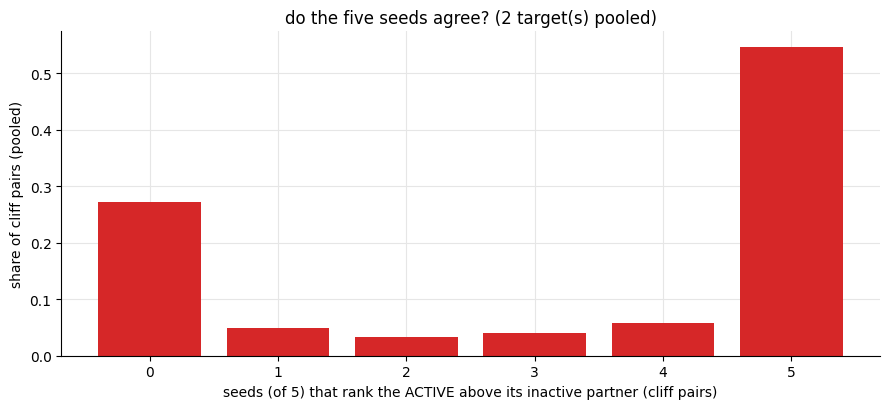

In [54]:
rows = []; VOTES = []
for t in TL:
    try:
        S_ = pd.read_csv(bc.AN / t / "cliffs/scores_seeds_eval.csv").set_index("id"); SEEDC = [f"ft_p{s}" for s in bc.SEEDS]; p = P[P.target == t].copy()
        pa = np.stack([S_[c].reindex(p.id_a).values for c in SEEDC], 1); pb = np.stack([S_[c].reindex(p.id_b).values for c in SEEDC], 1); p["votes"] = (pa > pb).sum(1); dl = bcl.lg(pa) - bcl.lg(pb); p["dl_mean"] = dl.mean(1)
        c_ = p[p.kind == "cliff"]; k_ = p[p.kind == "conserved"]; VOTES.append(c_.votes.values)
        rows.append(dict(target=SH[t], cliffs=len(c_), unanimous_right=(c_.votes == 5).mean(), unanimous_wrong=(c_.votes == 0).mean(), split=c_.votes.between(1, 4).mean(),
                         ensemble_right_when_split=((c_[c_.votes.between(1, 4)].dl_mean > 0).mean() if c_.votes.between(1, 4).any() else np.nan), controls_unanimous_either_way=((k_.votes == 5) | (k_.votes == 0)).mean()))
    except Exception as e: print(f"{SH[t]}: seed agreement failed: {type(e).__name__}: {e}")
SV = pd.DataFrame(rows).set_index("target"); display(SV.round(3)); KEY["SV"] = SV
fig, ax = plt.subplots(figsize=(9, 4.2)); vc = pd.Series(np.concatenate(VOTES)).value_counts(normalize=True).reindex(range(6)).fillna(0)
ax.bar(range(6), vc, color=CL); ax.set_xlabel("seeds (of 5) that rank the ACTIVE above its inactive partner (cliff pairs)"); ax.set_ylabel("share of cliff pairs (pooled)"); ax.set_title(f"do the five seeds agree? ({NT} target(s) pooled)"); plt.tight_layout(); plt.show()

# Part D · Cross-target summary
One row per target. Retrieval AP (No-FT and head-FT N=300) is shown **ours next to the paper's** as the replication context for this analysis; the paper reports no pair-level results, so the pair columns are ours only. Targets without a finished analysis show their pending reason and the paper's values only.

**n targets = 2 of 8 analysed** (588689, 504329)

,paper_AP_noft,paper_AP_ft300,active_rate,our_AP_noft,our_AP_ft300_mean,our_AP_ft300_sd,cliff_pairs,conserved_pairs,series,dominant_share_of_cliffs,acc_boltz2,acc_noft,acc_ft300,acc_baseline_larger,ft_minus_noft_pairwise,sens90_noft,sens90_ft,status
target,,,,,,,,,,,,,,,,,,
588689,0.096,0.237,0.008,0.097,0.207,0.015,406.0,275.0,94.0,0.621,0.648,0.672,0.660,0.644,-0.012,0.212,0.135,ready
504329,0.047,0.222,0.009,0.051,0.174,0.021,331.0,255.0,142.0,0.145,0.701,0.674,0.644,0.509,-0.030,0.239,0.245,ready
743445,0.022,0.048,0.003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: scoring incomplete (scored arms 0/16;...
485317,0.036,0.060,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: scoring incomplete (scored arms 0/16;...
2097,0.081,0.286,0.008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: eval split / head-FT inputs not built...
493091,0.059,0.095,0.015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: eval split / head-FT inputs not built...
2650,0.071,0.117,0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: eval split / head-FT inputs not built...
588549,0.006,0.007,0.003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: eval split / head-FT inputs not built...


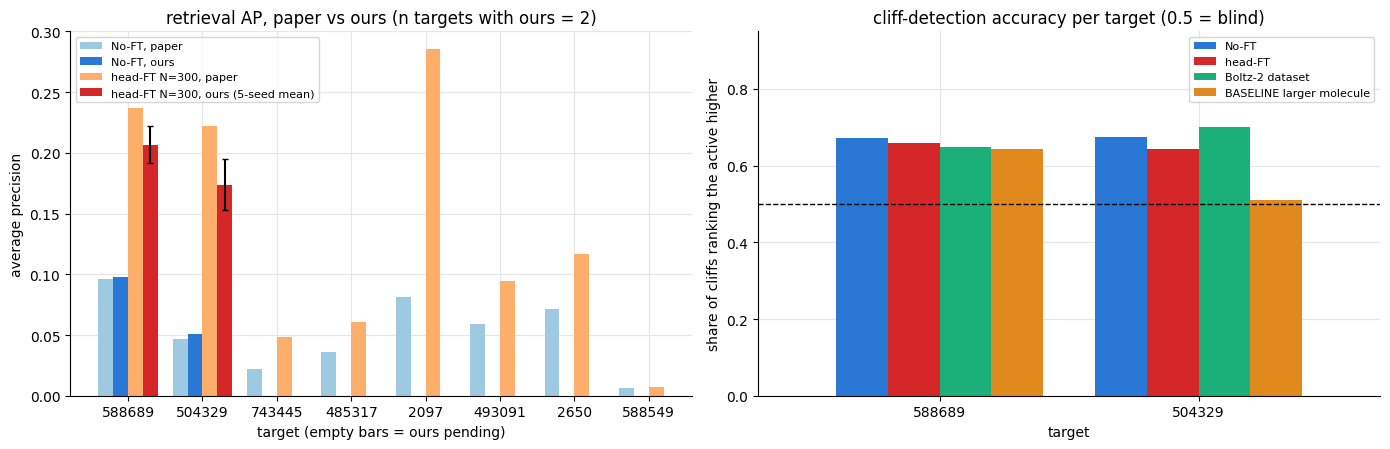

In [55]:
rows = []
for t in bc.TARGETS:
    r = dict(target=SH[t], paper_AP_noft=bc.PAPER_BASE.loc[t, "auprc"], paper_AP_ft300=bc.PAPER_FT.loc[(t, 300), "auprc"] if (t, 300) in bc.PAPER_FT.index else np.nan, active_rate=bc.RATE[t])
    if t in D:
        Sx = bc.scores(t)
        if Sx is not None:
            y = Sx.label.values
            r["our_AP_noft"] = bc.average_precision(y, Sx.noft_p.values); aps = [bc.average_precision(y, Sx[f"ft300_p{s}"].values) for s in bc.SEEDS]; r["our_AP_ft300_mean"] = np.mean(aps); r["our_AP_ft300_sd"] = np.std(aps, ddof=1)
        p = P[P.target == t]; C = p[p.kind == "cliff"]; K = p[p.kind == "conserved"]
        r.update(cliff_pairs=len(C), conserved_pairs=len(K), series=p.series.nunique(), dominant_share_of_cliffs=C.big.mean() if len(C) else np.nan)
        for nm, c in [("acc_boltz2", "d_score_boltz2"), ("acc_noft", "d_base_noft"), ("acc_ft300", "d_ft300"), ("acc_baseline_larger", "dp_heavy")]: r[nm] = bcl.acc_ci(C, c, B=500)["acc"] if len(C) else np.nan
        pr_ = PT[(PT.target == t) & (PT.scale == "percentile")]
        if len(pr_): r["ft_minus_noft_pairwise"] = float(pr_.ft_pairwise_acc.iloc[0] - pr_.noft_pairwise_acc.iloc[0]); r["sens90_noft"] = float(pr_["noft_sens@90"].iloc[0]); r["sens90_ft"] = float(pr_["ft_sens@90"].iloc[0])
        r["status"] = "ready"
    else: r["status"] = "pending: " + bcl.pending_reason(t)
    rows.append(r)
SUM = pd.DataFrame(rows).set_index("target"); display(Markdown(f"**n targets = {NT} of {len(bc.TARGETS)} analysed** ({', '.join(SH[t] for t in TL)})"))
display(SUM.round(3)); KEY["SUM"] = SUM
ready = SUM[SUM.status == "ready"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6)); x = np.arange(len(SUM)); w = 0.2
axes[0].bar(x - 1.5 * w, SUM.paper_AP_noft, w, color="#9ecae1", label="No-FT, paper"); axes[0].bar(x - 0.5 * w, SUM.our_AP_noft if "our_AP_noft" in SUM else 0, w, color=CO, label="No-FT, ours")
axes[0].bar(x + 0.5 * w, SUM.paper_AP_ft300, w, color="#fdae6b", label="head-FT N=300, paper"); axes[0].bar(x + 1.5 * w, SUM.our_AP_ft300_mean if "our_AP_ft300_mean" in SUM else 0, w, color=CL, label="head-FT N=300, ours (5-seed mean)")
if "our_AP_ft300_sd" in SUM: axes[0].errorbar(x + 1.5 * w, SUM.our_AP_ft300_mean, yerr=SUM.our_AP_ft300_sd, fmt="none", ecolor=BLK, capsize=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(SUM.index); axes[0].set_xlabel("target (empty bars = ours pending)"); axes[0].set_ylabel("average precision"); axes[0].legend(fontsize=8); axes[0].set_title(f"retrieval AP, paper vs ours (n targets with ours = {NT})")
if len(ready):
    xr = np.arange(len(ready)); axes[1].bar(xr - 0.3, ready.acc_noft, 0.2, color=CO, label="No-FT"); axes[1].bar(xr - 0.1, ready.acc_ft300, 0.2, color=CL, label="head-FT"); axes[1].bar(xr + 0.1, ready.acc_boltz2, 0.2, color=GRN, label="Boltz-2 dataset")
    axes[1].bar(xr + 0.3, ready.acc_baseline_larger, 0.2, color=ORG, label="BASELINE larger molecule"); axes[1].axhline(0.5, ls="--", color=BLK, lw=1); axes[1].set_xticks(xr); axes[1].set_xticklabels(ready.index)
axes[1].set_xlim(-0.7, max(len(ready), 2) - 0.3); axes[1].set_ylim(0, 0.95); axes[1].set_xlabel("target"); axes[1].set_ylabel("share of cliffs ranking the active higher"); axes[1].legend(fontsize=8); axes[1].set_title("cliff-detection accuracy per target (0.5 = blind)")
plt.tight_layout(); plt.show()

# Conclusions
Every number below is computed above from the data (or is a fixed paper value where labelled). Wording follows the numbers; nothing is stated about targets without data. Everything is an association in observational pairs; pair-level p-values treat pairs as independent and are optimistic; intervals resample series. Where several comparisons are made the Bonferroni caveat is stated.

In [56]:
A_ = KEY["ACC"]; ST_ = KEY["st"]; S_ = ST_[ST_.status == "ready"]; L = []
def pct(x): return f"{100*x:.0f}%"
L.append(f"## Scope\n**n targets analysed = {NT} of {len(bc.TARGETS)}** ({', '.join(SH[t] for t in TL)}); pending: {', '.join(SH[t] for t in bc.TARGETS if t not in D) or 'none'}. "
         f"Pooled: {int(S_.cliff_pairs.sum())} cliff pairs and {int(S_.conserved_pairs.sum())} conserved controls in {int(S_.series.sum())} series. "
         "The dominant series (largest by cliff pairs) makes, per target: " + ", ".join(f"{SH[t]} {pct(S_.loc[SH[t], 'dominant_series_share_of_cliffs'])}" for t in TL) + " of the cliff pairs, so results are given with and without it.")
nb_, nn_ = KEY["NEAR"]["all cliff pairs"], KEY["NEAR"]["without the dominant series"]
def nr(tab, m): r = tab.loc[m]; return f"{int(r['clearly right (>+0.3)'])} clearly right, {int(r['near tie'])} near tie, {int(r['clearly wrong (<-0.3)'])} clearly wrong of {int(r['near-identical pairs'])}"
L.append("## 1. Do the models separate near-identical siblings?\nAmong pairs with Tanimoto >= 0.7, in percentile terms: Boltz-2 (dataset) " + nr(nb_, "Boltz-2 (dataset score)") + "; head-FT " + nr(nb_, "Boltz-2 head-FT N=300 (5-seed)") +
         "; without the dominant series Boltz-2 " + nr(nn_, "Boltz-2 (dataset score)") + " and head-FT " + nr(nn_, "Boltz-2 head-FT N=300 (5-seed)") + ". "
         "Head-FT's small percentile gaps partly reflect the scale (fine-tuning places whole series near the top), so this is not evidence about its sensitivity; Part C calibrates the threshold on both-active pairs.")
def ar(n):
    r = A_.loc[n]; return f"{r.acc:.2f} [{r.lo:.2f}, {r.hi:.2f}]"
W_ = KEY["WD"]
L.append(f"## 2. Do any signals read the edit beyond size and lipophilicity?\nShare of cliffs where the signal ranks the active higher (macro over {NT} target(s), 95% CI over series): Boltz-2 {ar('Boltz-2 (dataset score)')}, No-FT {ar('Boltz-2 No-FT (our pipeline)')}, head-FT {ar('Boltz-2 head-FT N=300 (5-seed)')}; "
         f"baselines: larger molecule {ar('BASELINE: larger molecule (heavy atoms)')}, heavier {ar('BASELINE: heavier molecule (MW)')}, more lipophilic {ar('BASELINE: more lipophilic (logP)')}. "
         f"Without each dominant series: Boltz-2 {W_.loc['Boltz-2 (dataset)', 'without the dominant series']:.2f}, No-FT {W_.loc['Boltz-2 No-FT (ours)', 'without the dominant series']:.2f}, head-FT {W_.loc['head-FT N=300', 'without the dominant series']:.2f}, larger molecule {W_.loc['BASELINE larger molecule', 'without the dominant series']:.2f}. "
         f"With {KEY['NSIG']} signals compared, the Bonferroni-adjusted interval excludes 0.5 for {int(A_.distinguishable_from_blind_bonferroni.sum())} of them ({', '.join(A_.index[A_.distinguishable_from_blind_bonferroni])}). "
         f"Library-wide AUROC of the baseline properties (direction check): " + "; ".join(f"{SH[t]}: logP {KEY['PA'].loc[SH[t], 'logP']:.2f}, MW {KEY['PA'].loc[SH[t], 'molecular weight']:.2f}" for t in TL if SH[t] in KEY['PA'].index) + ". "
         "Overlapping intervals mean no ordering between a model and a baseline can be claimed.")
FTt = KEY["FT_"]; rb = KEY["rob_nodom"]
def orr(n): r = FTt.loc[n]; return f"OR {r['odds ratio']:.1f} (Fisher p {r['Fisher p']:.1g}; OR>1 in {r['targets with OR > 1']} targets)"
L.append("## 3. What differs in pairs that lose binding?\nAgainst both-active controls (pooled pairs): inactive less lipophilic (>= 0.5 logP) " + orr("inactive is less lipophilic (>= 0.5 logP)") + "; lighter " + orr("inactive is lighter (>= 20 Da)") +
         "; smaller " + orr("inactive is smaller (>= 1 heavy atom)") + "; single-atom swap " + orr("single-atom swap (<=1 atom differs on each side)") + f". {KEY['NFLAG']} flags were tested (Bonferroni p < {0.05/KEY['NFLAG']:.4f}). "
         + (f"Grouped-by-series CV (AUROC) of cliff vs conserved from structure: " + "; ".join(f"{r['pairs used']}, {r['model']}, {r['features']}: {r['AUROC (GroupKFold by series)']:.2f}" for _, r in KEY["CV"].iterrows()) + ". " if len(KEY["CV"]) else ""))
C_ = KEY["CONF_T"]; 
L.append(f"## 4. Confidence and pose\nMedian ligand-ipTM gap (active minus inactive) {C_.loc['ligand ipTM (= ipTM)', 'median (active - inactive)']:+.3f} (pairs pooled, p {C_.loc['ligand ipTM (= ipTM)', 'p (delta != 0)']:.1g}); complex PDE {C_.loc['complex PDE (lower = better)', 'median (active - inactive)']:+.3f}. "
         f"Spearman of the ipTM gap against the score delta: Boltz-2 {KEY['conf_rho']['score_boltz2']:+.2f}, head-FT {KEY['conf_rho']['ft300']:+.2f}. Median ligand ipTM of the inactive partner: fooled {KEY['iptm_partner'][0]:.2f}, ranked right {KEY['iptm_partner'][1]:.2f}, near-tie {KEY['iptm_partner'][2]:.2f}. "
         "Pairs sharing no contact residue (cliffs vs controls): " + "; ".join(f"{t_}: {r.pct_cliffs_no_shared_contact:.0f}% vs {r.pct_controls_no_shared_contact:.0f}%" for t_, r in KEY["POSE_T"].iterrows()) + ". "
         "Site switching (cliffs vs controls): " + "; ".join(f"{SH[t]}: {100*a:.0f}% vs {100*b:.0f}%" for t, (a, b) in KEY["switch"].items()) + ".")
Z_ = KEY["ZT"]; T6_ = KEY["T6"]
L.append("## 5. Is the loss complete, and what does it cost at the top of the ranking?\nDistinct inactive partners: " + "; ".join(f"{t_}: median Z {r.median_Z_partners:.2f} vs {r.median_Z_inactives:.2f} for ordinary inactives, {r.pct_partners_above_99th_of_inactives:.0f}% above the 99th percentile (1% expected)" for t_, r in Z_.iterrows()) + ". "
         "Cliff siblings among the top-1% false positives (enrichment over ordinary compounds): " + "; ".join(f"{r.target} {r.model} {r.pct_fp_siblings:.1f}% ({r.enrichment_vs_ordinary:.1f}x)" for _, r in T6_.iterrows() if r.model in ("No-FT", "head-FT N=300")) + ". This counts only siblings of held-out actives, so it is a lower bound.")
B1_ = KEY["B1"]; B3_ = KEY["B3"]; b2r = int((CLIFF.o_b2 == "right").sum()); b2w = int((CLIFF.o_b2 == "wrong").sum()); b2t = int((CLIFF.o_b2 == "tie").sum()); b1s = KEY["B1S"]
L.append(f"## 6. Where the large deltas are correct (Part B)\nOf {len(CLIFF)} cliff pairs the Boltz-2 affinity head (dataset score or No-FT, no contradiction) makes {b2r} large correct calls, {b2w} large wrong calls and {b2t} ties at the 0.3 percentile threshold. "
         f"The right calls involve {B3_['n_act']} distinct actives, {B3_['n_part']} inactive partners and {B3_['n_series']} series; {100*B3_['dom_share']:.0f}% are in a target's dominant series; the three most reused partners account for {B3_['top3']} calls. "
         f"Right rate by similarity bin {B3_['right_rate_bins']}; at Tanimoto >= 0.8, {B3_['right_hi']} right against {B3_['wrong_hi']} wrong. Threshold sensitivity (0.2 to 0.5): right/wrong calls " + ", ".join(f"{th}: {int(r['right calls'])}/{int(r['wrong calls'])}" for th, r in b1s.iterrows()) +
         f"; share of right calls in the dominant series " + ", ".join(f"{th}: {r['% of right calls in the dominant series']:.0f}%" for th, r in b1s.iterrows()) + ". "
         f"Right calls versus ties, median active-minus-inactive difference: heavy atoms {KEY['B4']['heavy atoms'][0]:+.0f} vs {KEY['B4']['heavy atoms'][1]:+.0f} (p {KEY['B4']['heavy atoms'][2]:.2g}), logP {KEY['B4']['logP'][0]:+.2f} vs {KEY['B4']['logP'][1]:+.2f} (p {KEY['B4']['logP'][2]:.2g}), MW {KEY['B4']['MW'][0]:+.0f} vs {KEY['B4']['MW'][1]:+.0f} (p {KEY['B4']['MW'][2]:.2g}). "
         f"Pairs called right by at least 3 of 5 modalities: {KEY['n_ge3']}; by all 5: {KEY['n_all5']}. Median contact dissimilarity by outcome: " + ", ".join(f"{g} {v:.2f}" for g, v in KEY["B8"]["med"].items()) + f" (right vs tie p {KEY['B8']['p']:.2g}). "
         f"Non-trivial pairs (active not larger, not greasier): " + "; ".join(f"{m}: {int(r.right)} right / {int(r.wrong)} wrong" for m, r in KEY["T6b"].iterrows() if m in ("Boltz-2 dataset", "Boltz-2 No-FT", "head-FT N=300", "Boltzina")) + ".")
C1_ = KEY["CAL"]
def cl(sub, sc, met):
    r = C1_[(C1_.subset == sub) & (C1_.scale == sc) & (C1_.metric == met)]
    if not len(r): return "n/a"
    r = r.iloc[0]; return f"No-FT {r.noft:.3f}, head-FT {r.ft:.3f}, difference {r['diff']:+.3f}" + (f" [{r.lo:+.3f}, {r.hi:+.3f}]" if np.isfinite(r.lo) else "")
L.append(f"## 7. Head-FT versus No-FT on similar pairs (Part C; n targets = {NT}; 95% CI over series)\nPairwise accuracy, all pairs: {cl('all pairs', 'percentile', 'pairwise_acc')}; without the dominant series: {cl('without the dominant series', 'percentile', 'pairwise_acc')}. "
         f"Sensitivity at 90% specificity (percentile scale), all pairs: {cl('all pairs', 'percentile', 'sens@90')}; (log-odds): {cl('all pairs', 'log-odds', 'sens@90')}. "
         f"Of {KEY['NCMP']} comparisons, {KEY['nsig']} have a nominal 95% interval excluding zero (about {0.05*KEY['NCMP']:.1f} expected by chance; Bonferroni level {0.05/KEY['NCMP']:.4f}). "
         f"Across calibration levels 80-99% the head-FT minus No-FT sensitivity ranges from {KEY['SENS']['head-FT minus No-FT'].min():+.3f} to {KEY['SENS']['head-FT minus No-FT'].max():+.3f}. "
         + (f"Seeds agree unanimously on {100*(KEY['SV'].unanimous_right+KEY['SV'].unanimous_wrong).mean():.0f}% of cliffs (mean over targets), {100*KEY['SV'].unanimous_right.mean():.0f}% unanimously right. " if len(KEY["SV"]) else "") +
         "Wide intervals mean an absence of evidence for a difference, not evidence of none.")
Sm_ = KEY["SUM"]; rd_ = Sm_[Sm_.status == "ready"]
L.append("## 8. Replication context (fixed paper values vs ours)\n" + "; ".join(f"{t_}: No-FT AP paper {r.paper_AP_noft:.3f} vs ours {r.our_AP_noft:.3f}, head-FT N=300 AP paper {r.paper_AP_ft300:.3f} vs ours {r.our_AP_ft300_mean:.3f} +/- {r.our_AP_ft300_sd:.3f} (5 seeds, x{r.our_AP_ft300_mean/r.our_AP_noft:.2f})" for t_, r in rd_.iterrows() if "our_AP_noft" in r and np.isfinite(r.our_AP_noft)) +
         ". The paper does not report pair-level analyses, so Parts A-C have no paper counterpart.")
L.append(f"## Caveats\n{NT} of {len(bc.TARGETS)} targets are analysed; cross-target statements use those targets as the unit and are weak with so few. The pair set is anchored on held-out actives, so it says nothing about inactive-inactive pairs. "
         "Labels come from a single-concentration primary screen with a graded readout, so some cliffs are assay noise. The 0.3-percentile 'large delta' threshold in Part B is arbitrary and scale-dependent (see its sensitivity table and Part C). "
         "Pair-level tests treat pairs as independent and are optimistic; structural flags and pose statistics are associations in observational pairs. Head-FT here is the default top-300 training set, five seeds.")
display(Markdown("\n\n".join(L)))

## Scope
**n targets analysed = 2 of 8** (588689, 504329); pending: 743445, 485317, 2097, 493091, 2650, 588549. Pooled: 737 cliff pairs and 530 conserved controls in 236 series. The dominant series (largest by cliff pairs) makes, per target: 588689 62%, 504329 14% of the cliff pairs, so results are given with and without it.

## 1. Do the models separate near-identical siblings?
Among pairs with Tanimoto >= 0.7, in percentile terms: Boltz-2 (dataset) 28 clearly right, 230 near tie, 4 clearly wrong of 262; head-FT 11 clearly right, 245 near tie, 6 clearly wrong of 262; without the dominant series Boltz-2 10 clearly right, 135 near tie, 1 clearly wrong of 146 and head-FT 9 clearly right, 131 near tie, 6 clearly wrong of 146. Head-FT's small percentile gaps partly reflect the scale (fine-tuning places whole series near the top), so this is not evidence about its sensitivity; Part C calibrates the threshold on both-active pairs.

## 2. Do any signals read the edit beyond size and lipophilicity?
Share of cliffs where the signal ranks the active higher (macro over 2 target(s), 95% CI over series): Boltz-2 0.67 [0.63, 0.75], No-FT 0.67 [0.63, 0.72], head-FT 0.65 [0.61, 0.72]; baselines: larger molecule 0.58 [0.54, 0.63], heavier 0.61 [0.54, 0.65], more lipophilic 0.58 [0.50, 0.63]. Without each dominant series: Boltz-2 0.69, No-FT 0.67, head-FT 0.67, larger molecule 0.59. With 16 signals compared, the Bonferroni-adjusted interval excludes 0.5 for 7 of them (BASELINE: larger molecule (heavy atoms), Boltzina recycle-1, Boltzina mask, Boltzina, Boltz-2 head-FT N=300 (5-seed), Boltz-2 No-FT (our pipeline), Boltz-2 (dataset score)). Library-wide AUROC of the baseline properties (direction check): 588689: logP 0.65, MW 0.59; 504329: logP 0.48, MW 0.40. Overlapping intervals mean no ordering between a model and a baseline can be claimed.

## 3. What differs in pairs that lose binding?
Against both-active controls (pooled pairs): inactive less lipophilic (>= 0.5 logP) OR 2.9 (Fisher p 1e-15; OR>1 in 2/2 targets); lighter OR 2.3 (Fisher p 5e-12; OR>1 in 2/2 targets); smaller OR 1.7 (Fisher p 9e-06; OR>1 in 2/2 targets); single-atom swap OR 0.4 (Fisher p 1e-12; OR>1 in 0/2 targets). 9 flags were tested (Bonferroni p < 0.0056). Grouped-by-series CV (AUROC) of cliff vs conserved from structure: all pairs, logistic, all descriptors: 0.67; all pairs, logistic, size + lipophilicity only: 0.67; all pairs, boosting, all descriptors: 0.66; all pairs, boosting, size + lipophilicity only: 0.66; without each target's dominant series, logistic, all descriptors: 0.71; without each target's dominant series, logistic, size + lipophilicity only: 0.72; without each target's dominant series, boosting, all descriptors: 0.70; without each target's dominant series, boosting, size + lipophilicity only: 0.70. 

## 4. Confidence and pose
Median ligand-ipTM gap (active minus inactive) +0.004 (pairs pooled, p 0.1); complex PDE -0.013. Spearman of the ipTM gap against the score delta: Boltz-2 +0.01, head-FT -0.07. Median ligand ipTM of the inactive partner: fooled 0.91, ranked right 0.85, near-tie 0.86. Pairs sharing no contact residue (cliffs vs controls): 588689: 29% vs 25%; 504329: 22% vs 12%. Site switching (cliffs vs controls): 588689: 10% vs 13%; 504329: 23% vs 13%.

## 5. Is the loss complete, and what does it cost at the top of the ranking?
Distinct inactive partners: 588689: median Z 0.45 vs -0.05 for ordinary inactives, 19% above the 99th percentile (1% expected); 504329: median Z 0.25 vs -0.02 for ordinary inactives, 4% above the 99th percentile (1% expected). Cliff siblings among the top-1% false positives (enrichment over ordinary compounds): 588689 No-FT 1.9% (6.0x); 588689 head-FT N=300 7.8% (25.2x); 504329 No-FT 2.9% (5.7x); 504329 head-FT N=300 5.8% (11.6x). This counts only siblings of held-out actives, so it is a lower bound.

## 6. Where the large deltas are correct (Part B)
Of 737 cliff pairs the Boltz-2 affinity head (dataset score or No-FT, no contradiction) makes 168 large correct calls, 32 large wrong calls and 537 ties at the 0.3 percentile threshold. The right calls involve 85 distinct actives, 101 inactive partners and 55 series; 55% are in a target's dominant series; the three most reused partners account for 26 calls. Right rate by similarity bin {'0.60-0.70': 0.25, '0.70-0.80': 0.16, '0.80+': 0.24}; at Tanimoto >= 0.8, 18 right against 2 wrong. Threshold sensitivity (0.2 to 0.5): right/wrong calls 0.2: 247/80, 0.3: 168/32, 0.4: 97/9, 0.5: 55/5; share of right calls in the dominant series 0.2: 53%, 0.3: 55%, 0.4: 47%, 0.5: 47%. Right calls versus ties, median active-minus-inactive difference: heavy atoms +0 vs +0 (p 0.29), logP +0.47 vs +0.19 (p 0.011), MW +23 vs +12 (p 1.2e-05). Pairs called right by at least 3 of 5 modalities: 53; by all 5: 1. Median contact dissimilarity by outcome: right 0.33, tie 0.23, wrong 0.23 (right vs tie p 0.00046). Non-trivial pairs (active not larger, not greasier): Boltz-2 dataset: 19 right / 13 wrong; Boltz-2 No-FT: 28 right / 11 wrong; head-FT N=300: 27 right / 8 wrong; Boltzina: 19 right / 12 wrong.

## 7. Head-FT versus No-FT on similar pairs (Part C; n targets = 2; 95% CI over series)
Pairwise accuracy, all pairs: No-FT 0.673, head-FT 0.652, difference -0.021 [-0.053, +0.037]; without the dominant series: No-FT 0.674, head-FT 0.670, difference -0.003 [-0.051, +0.048]. Sensitivity at 90% specificity (percentile scale), all pairs: No-FT 0.225, head-FT 0.190, difference -0.035 [-0.100, +0.105]; (log-odds): No-FT 0.194, head-FT 0.138, difference -0.056 [-0.092, +0.017]. Of 18 comparisons, 2 have a nominal 95% interval excluding zero (about 0.9 expected by chance; Bonferroni level 0.0028). Across calibration levels 80-99% the head-FT minus No-FT sensitivity ranges from -0.065 to -0.021. Seeds agree unanimously on 82% of cliffs (mean over targets), 54% unanimously right. Wide intervals mean an absence of evidence for a difference, not evidence of none.

## 8. Replication context (fixed paper values vs ours)
588689: No-FT AP paper 0.096 vs ours 0.097, head-FT N=300 AP paper 0.237 vs ours 0.207 +/- 0.015 (5 seeds, x2.12); 504329: No-FT AP paper 0.047 vs ours 0.051, head-FT N=300 AP paper 0.222 vs ours 0.174 +/- 0.021 (5 seeds, x3.42). The paper does not report pair-level analyses, so Parts A-C have no paper counterpart.

## Caveats
2 of 8 targets are analysed; cross-target statements use those targets as the unit and are weak with so few. The pair set is anchored on held-out actives, so it says nothing about inactive-inactive pairs. Labels come from a single-concentration primary screen with a graded readout, so some cliffs are assay noise. The 0.3-percentile 'large delta' threshold in Part B is arbitrary and scale-dependent (see its sensitivity table and Part C). Pair-level tests treat pairs as independent and are optimistic; structural flags and pose statistics are associations in observational pairs. Head-FT here is the default top-300 training set, five seeds.